In [1]:
# ==========================================
# 🚀 COMPLETE SETUP CELL
# Har kernel restart ke baad SIRF YEH EK CELL chalayein
# Sab kuch dobara tayyar ho jayega
# ==========================================

# ==================== IMPORTS ====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pickle
import os
import warnings
from datetime import datetime
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings('ignore')

# ==================== STYLE ====================
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# ==================== PATHS ====================
BASE_PATH = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
# Fallback path (agar __file__ na mile)
if not os.path.exists(BASE_PATH):
    BASE_PATH = r'D:\DA projects\Covid-19-portfolio'

DATA_PATH = os.path.join(BASE_PATH, 'data', 'processed')
MODELS_PATH = os.path.join(BASE_PATH, 'models')
FIGURES_PATH = os.path.join(BASE_PATH, 'outputs', 'figures')

# Agar notebook se chal rahe hain (notebooks folder mein)
if not os.path.exists(DATA_PATH):
    DATA_PATH = os.path.join(BASE_PATH, '..', 'data', 'processed')
    MODELS_PATH = os.path.join(BASE_PATH, '..', 'models')
    FIGURES_PATH = os.path.join(BASE_PATH, '..', 'outputs', 'figures')

# Absolute safe paths (aap ki file system ke liye)
DATA_PATH = r'D:\DA projects\Covid-19-portfolio\data\processed'
MODELS_PATH = r'D:\DA projects\Covid-19-portfolio\models'
FIGURES_PATH = r'D:\DA projects\Covid-19-portfolio\outputs\figures'

# Folders ensure
os.makedirs(FIGURES_PATH, exist_ok=True)
os.makedirs(MODELS_PATH, exist_ok=True)

print("Paths:")
print(f"  Data:    {DATA_PATH}")
print(f"  Models:  {MODELS_PATH}")
print(f"  Figures: {FIGURES_PATH}")

# ==================== LOAD DATA ====================
df = pd.read_csv(os.path.join(DATA_PATH, 'PK_COVID_19_cleaned.csv'))
df['Date'] = pd.to_datetime(df['Date'])

# ==================== DATA CLEANING ====================
df['Province'] = df['Province'].str.strip()
df['City'] = df['City'].str.strip()
df['Travel_history'] = df['Travel_history'].fillna('Unknown').str.strip()

# ==================== FEATURE ENGINEERING ====================
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b-%Y')
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.day_name()
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
df['Quarter'] = df['Date'].dt.quarter
df['Active'] = df['Cases'] - df['Deaths'] - df['Recovered']
df['CFR'] = np.where(df['Cases'] > 0, df['Deaths'] / df['Cases'] * 100, 0)
df['Recovery_Rate'] = np.where(df['Cases'] > 0, df['Recovered'] / df['Cases'] * 100, 0)
df['Is_Local'] = df['Travel_history'].str.contains('Local', na=False).astype(int)
df['Is_Tableeghi'] = df['Travel_history'].str.contains('Tableeghi', na=False).astype(int)

# ==================== AGGREGATED DATA ====================
# Daily summary
daily = df.groupby('Date').agg({'Cases': 'sum', 'Deaths': 'sum', 'Recovered': 'sum'}).reset_index()
daily['Active'] = daily['Cases'] - daily['Deaths'] - daily['Recovered']
daily['Cumulative_Cases'] = daily['Cases'].cumsum()
daily['Cumulative_Deaths'] = daily['Deaths'].cumsum()
daily['Cumulative_Recovered'] = daily['Recovered'].cumsum()
daily['Cumulative_Active'] = daily['Cumulative_Cases'] - daily['Cumulative_Deaths'] - daily['Cumulative_Recovered']
daily['CFR'] = (daily['Cumulative_Deaths'] / daily['Cumulative_Cases'] * 100).round(2)
daily['Recovery_Rate'] = (daily['Cumulative_Recovered'] / daily['Cumulative_Cases'] * 100).round(2)

# Province summary
province_summary = df.groupby('Province').agg({'Cases': 'sum', 'Deaths': 'sum', 'Recovered': 'sum'}).reset_index()
province_summary['Active'] = province_summary['Cases'] - province_summary['Deaths'] - province_summary['Recovered']
province_summary['CFR'] = (province_summary['Deaths'] / province_summary['Cases'] * 100).round(2)
province_summary['Recovery_Rate'] = (province_summary['Recovered'] / province_summary['Cases'] * 100).round(2)
province_summary = province_summary.sort_values('Cases', ascending=False).reset_index(drop=True)

# City summary
city_summary = df.groupby(['City', 'Province']).agg({'Cases': 'sum', 'Deaths': 'sum', 'Recovered': 'sum'}).reset_index()
city_summary = city_summary.sort_values('Cases', ascending=False).reset_index(drop=True)

# Travel history summary
travel_summary = df.groupby('Travel_history').agg({'Cases': 'sum', 'Deaths': 'sum', 'Recovered': 'sum', 'Date': 'count'}).reset_index()
travel_summary = travel_summary.rename(columns={'Date': 'Records'})
travel_summary['Avg_Cases_per_Record'] = (travel_summary['Cases'] / travel_summary['Records']).round(2)
travel_summary = travel_summary.sort_values('Cases', ascending=False).reset_index(drop=True)

# Province × Month pivot
pivot_prov_time = df.pivot_table(values='Cases', index='Month_Name', columns='Province', aggfunc='sum', fill_value=0)
month_order = ['Feb-2020', 'Mar-2020', 'Apr-2020', 'May-2020', 'Jun-2020']
pivot_prov_time = pivot_prov_time.reindex([m for m in month_order if m in pivot_prov_time.index])

# ==================== ENCODING & FEATURES ====================
le = LabelEncoder()
df['Province_Encoded'] = le.fit_transform(df['Province'])

features = ['Deaths', 'Recovered', 'Is_Local', 'Is_Tableeghi', 'Month', 'DayOfWeek', 'Province_Encoded']
# Note: DayOfWeek ab string hai, is liye numeric banayein
df['DayOfWeek_Num'] = pd.to_datetime(df['Date']).dt.dayofweek
features = ['Deaths', 'Recovered', 'Is_Local', 'Is_Tableeghi', 'Month', 'DayOfWeek_Num', 'Province_Encoded']

X = df[features]
y = df['Cases']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==================== MODELS ====================
lr = LinearRegression()
lr.fit(X_train, y_train)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)

# ==================== SUMMARY ====================
print("\n" + "=" * 60)
print("✅ SETUP COMPLETE — SAB KUCH READY HAI!")
print("=" * 60)
print(f"📊 Data:              {df.shape}")
print(f"📅 Date range:        {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"🗺️  Provinces:         {df['Province'].nunique()}")
print(f"🏙️  Cities:            {df['City'].nunique()}")
print(f"🤖 Models trained:    LR, RF, GB")
print(f"📈 Daily summary:     {daily.shape}")
print(f"📈 Province summary:  {province_summary.shape}")
print(f"📈 City summary:      {city_summary.shape}")
print(f"📈 Travel summary:    {travel_summary.shape}")
print("=" * 60)
print("\n✅ Ab baqi cells dobara chala sakte hain!")


Paths:
  Data:    D:\DA projects\Covid-19-portfolio\data\processed
  Models:  D:\DA projects\Covid-19-portfolio\models
  Figures: D:\DA projects\Covid-19-portfolio\outputs\figures

✅ SETUP COMPLETE — SAB KUCH READY HAI!
📊 Data:              (2798, 21)
📅 Date range:        2020-02-26 to 2020-06-03
🗺️  Provinces:         8
🏙️  Cities:            125
🤖 Models trained:    LR, RF, GB
📈 Daily summary:     (91, 11)
📈 Province summary:  (8, 7)
📈 City summary:      (131, 5)
📈 Travel summary:    (15, 6)

✅ Ab baqi cells dobara chala sakte hain!


In [2]:
# ============================================
# CELL 1: Import all libraries
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


In [3]:
# ============================================
# CELL 2: Load the main dataset
# ============================================
df = pd.read_csv('PK COVID-19-3jun.csv')

print("✅ Data loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

FileNotFoundError: [Errno 2] No such file or directory: 'PK COVID-19-3jun.csv'

In [ ]:
# ============================================
# CELL 4: First look at data
# ============================================
df.head()          # First 5 rows
# CELL 5: Last 5 rows
df.tail()
# CELL 6: Random sample
df.sample(10)
# CELL 7: Column names
print("Columns:", df.columns.tolist())
# CELL 8: Data types & info
df.info()
# CELL 9: Statistical summary
df.describe()
# CELL 10: Statistical summary including text columns
df.describe(include='all')
# CELL 11: Shape of data
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")


Columns: ['Date', 'Cases', 'Deaths', 'Recovered', 'Travel_history', 'Province', 'City']
<class 'pandas.DataFrame'>
RangeIndex: 2798 entries, 0 to 2797
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Date            2798 non-null   str  
 1   Cases           2798 non-null   int64
 2   Deaths          2798 non-null   int64
 3   Recovered       2798 non-null   int64
 4   Travel_history  2762 non-null   str  
 5   Province        2798 non-null   str  
 6   City            2798 non-null   str  
dtypes: int64(3), str(4)
memory usage: 294.7 KB
Rows: 2798
Columns: 7


In [ ]:
# ============================================
# CELL 12: Check missing values
# ============================================
print("Missing Values per Column:")
print(df.isnull().sum())
print("\nPercentage Missing:")
print((df.isnull().sum() / len(df)) * 100)

Missing Values per Column:
Date               0
Cases              0
Deaths             0
Recovered          0
Travel_history    36
Province           0
City               0
dtype: int64

Percentage Missing:
Date              0.000000
Cases             0.000000
Deaths            0.000000
Recovered         0.000000
Travel_history    1.286633
Province          0.000000
City              0.000000
dtype: float64


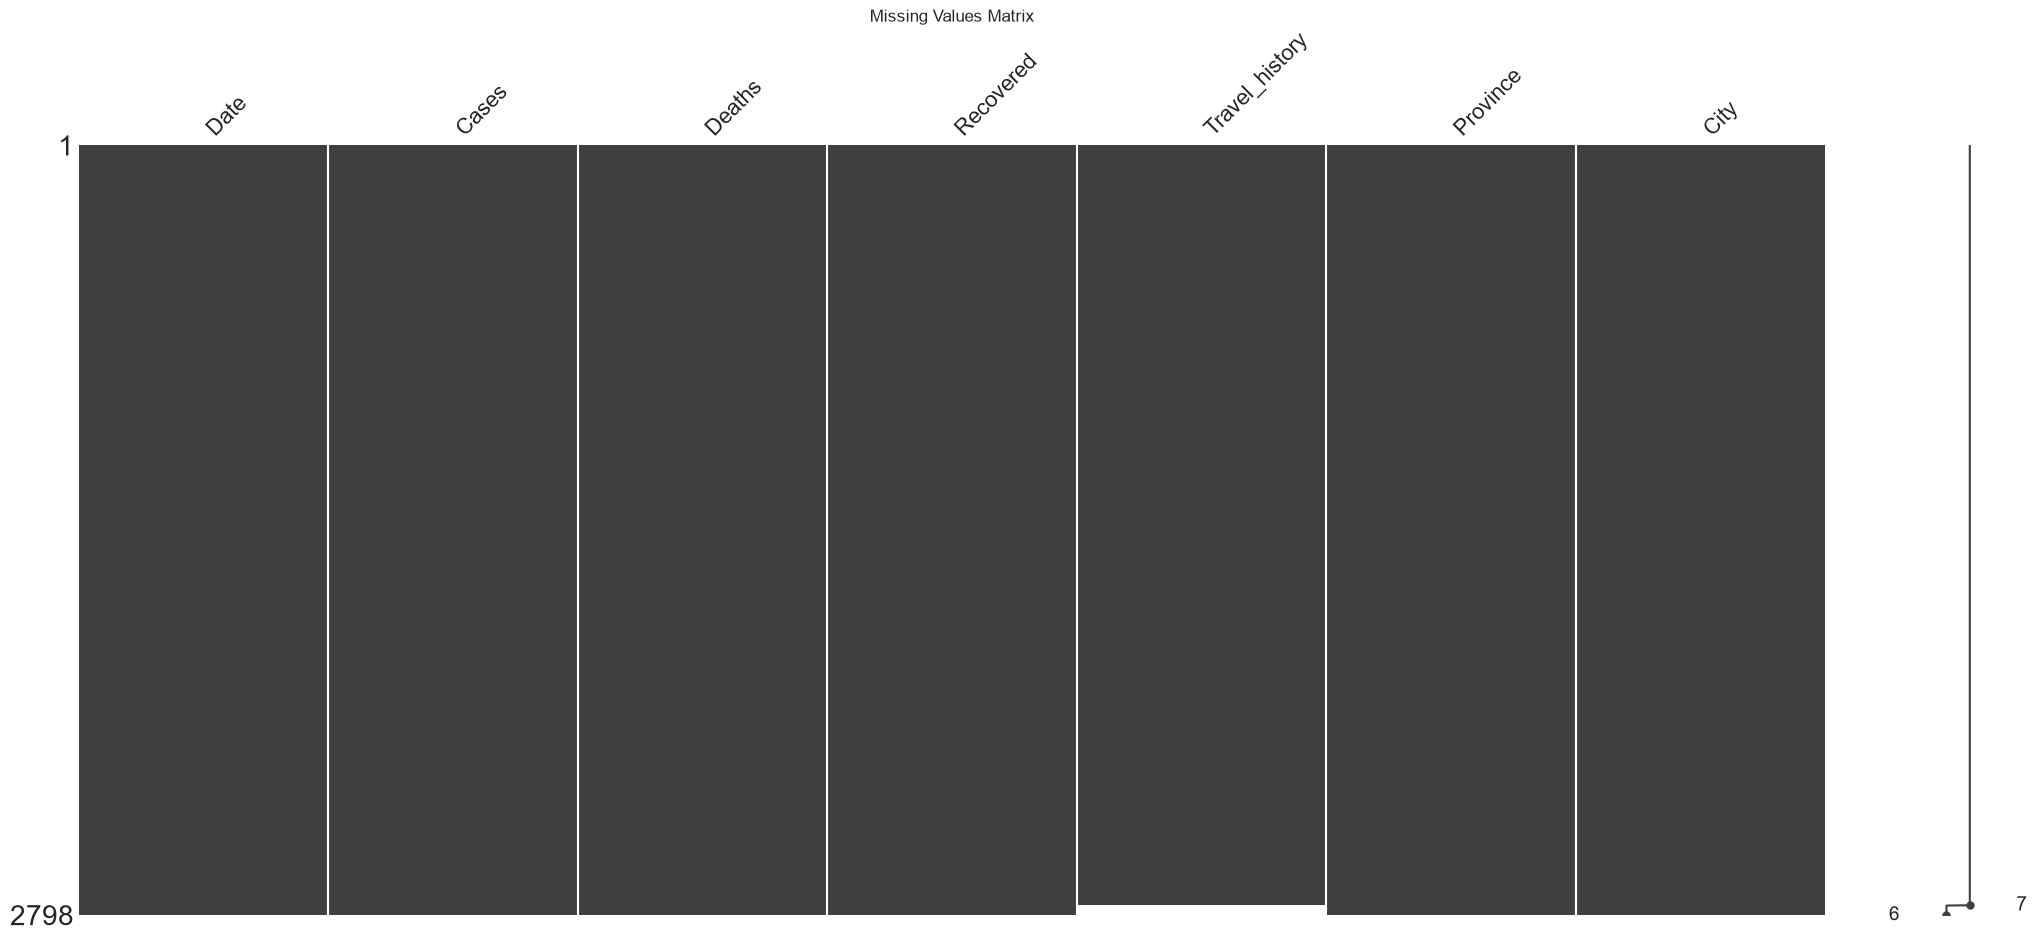

In [ ]:
# CELL 13: Visualize missing values
import missingno as msno
msno.matrix(df)
plt.title("Missing Values Matrix")
plt.show()

In [ ]:
# CELL 14: Check duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")
# CELL 15: Check unique values per column
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")
    # CELL 16: Value counts for categorical columns
print("Provinces:")
print(df['Province'].value_counts())
print("\nTravel History:")
print(df['Travel_history'].value_counts().head(10))


Duplicate rows: 2
Date: 91 unique values
Cases: 218 unique values
Deaths: 29 unique values
Recovered: 123 unique values
Travel_history: 15 unique values
Province: 10 unique values
City: 132 unique values
Provinces:
Province
Khyber Pakhtunkhwa                    1489
Sindh                                  529
Punjab                                 341
Gilgit-Baltistan                       190
Baluchistan                             83
Azad Jummu Kashmir                      54
Islamabad Capital Territory             51
Federal Administration Tribal Area      36
islamabad Capital Territory             23
khyber Pakhtunkhwa                       2
Name: count, dtype: int64

Travel History:
Travel_history
Local - Social Contact     2499
Unknown                     123
Iran/Taftan                  88
Tableeghi Jamaat             23
International Passenger       5
Jail                          5
Afghanistan                   5
UK                            3
China                         2


In [ ]:
# ============================================
# CELL 17: Convert Date to datetime
# ============================================
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
# CELL 18: Remove completely empty rows
df = df.dropna(how='all')
print(f"Shape after removing empty rows: {df.shape}")
# CELL 19: Fix column names (strip spaces)
df.columns = df.columns.str.strip()
print("Columns cleaned:", df.columns.tolist())
# CELL 20: Clean Province names
df['Province'] = df['Province'].str.strip()
df['Province'] = df['Province'].str.title()  # Standardize capitalization
print(df['Province'].value_counts())
# CELL 21: Clean City names
df['City'] = df['City'].str.strip()
df['City'] = df['City'].str.title()
# CELL 22: Fill missing values (strategic)
df['Cases'] = df['Cases'].fillna(0)
df['Deaths'] = df['Deaths'].fillna(0)
df['Recovered'] = df['Recovered'].fillna(0)
df['Travel_history'] = df['Travel_history'].fillna('Unknown')
df['Province'] = df['Province'].fillna('Unknown')
df['City'] = df['City'].fillna('Unknown')
print("Missing values after cleaning:")
print(df.isnull().sum())
# CELL 23: Remove the "Total" row (it's a summary row)
df = df[df['Date'].notna()]
print(f"Shape after cleaning: {df.shape}")
# CELL 24: Save cleaned data
df.to_csv('PK_COVID_19_cleaned.csv', index=False)
print("✅ Cleaned data saved!")


Date range: 2020-02-26 00:00:00 to 2020-06-03 00:00:00
Shape after removing empty rows: (2798, 7)
Columns cleaned: ['Date', 'Cases', 'Deaths', 'Recovered', 'Travel_history', 'Province', 'City']
Province
Khyber Pakhtunkhwa                    1491
Sindh                                  529
Punjab                                 341
Gilgit-Baltistan                       190
Baluchistan                             83
Islamabad Capital Territory             74
Azad Jummu Kashmir                      54
Federal Administration Tribal Area      36
Name: count, dtype: int64
Missing values after cleaning:
Date              0
Cases             0
Deaths            0
Recovered         0
Travel_history    0
Province          0
City              0
dtype: int64
Shape after cleaning: (2798, 7)
✅ Cleaned data saved!


In [ ]:
# ============================================
# CELL 25: Total cases, deaths, recovered
# ============================================
total_cases = df['Cases'].sum()
total_deaths = df['Deaths'].sum()
total_recovered = df['Recovered'].sum()

print("=" * 40)
print("📊 OVERALL STATISTICS")
print("=" * 40)
print(f"Total Cases:     {total_cases:,}")
print(f"Total Deaths:    {total_deaths:,}")
print(f"Total Recovered: {total_recovered:,}")
print(f"Active Cases:    {total_cases - total_deaths - total_recovered:,}")
print(f"Death Rate:      {(total_deaths/total_cases)*100:.2f}%")
print(f"Recovery Rate:   {(total_recovered/total_cases)*100:.2f}%")

📊 OVERALL STATISTICS
Total Cases:     83,986
Total Deaths:    1,728
Total Recovered: 24,754
Active Cases:    57,504
Death Rate:      2.06%
Recovery Rate:   29.47%


In [ ]:
# ============================================
# CELL 26: Daily totals
# ============================================
daily = df.groupby('Date').agg({
    'Cases': 'sum',
    'Deaths': 'sum',
    'Recovered': 'sum'
}).reset_index()

daily['Active'] = daily['Cases'] - daily['Deaths'] - daily['Recovered']
print(daily.head(10))
# CELL 27: Cumulative totals
# ============================================
daily['Cumulative_Cases'] = daily['Cases'].cumsum()
daily['Cumulative_Deaths'] = daily['Deaths'].cumsum()
daily['Cumulative_Recovered'] = daily['Recovered'].cumsum()
daily['Cumulative_Active'] = daily['Cumulative_Cases'] - daily['Cumulative_Deaths'] - daily['Cumulative_Recovered']

print(daily.tail(10))
# CELL 28: Save daily data
daily.to_csv('daily_summary.csv', index=False)
print("✅ Daily summary saved!")

        Date  Cases  Deaths  Recovered  Active
0 2020-02-26      3       0          0       3
1 2020-02-29      2       0          0       2
2 2020-03-02      1       0          0       1
3 2020-03-06      0       0          1      -1
4 2020-03-07      1       0          0       1
5 2020-03-09      9       0          0       9
6 2020-03-10      3       0          0       3
7 2020-03-11      1       0          1       0
8 2020-03-12      1       0          0       1
9 2020-03-13      9       0          1       8
         Date  Cases  Deaths  Recovered  Active  Cumulative_Cases  Cumulative_Deaths  Cumulative_Recovered  Cumulative_Active
81 2020-05-25   1356      30        830     496             56755               1151                 12859              42745
82 2020-05-26   1440      27        824     589             58195               1178                 13683              43334
83 2020-05-27   2173      36       1065    1072             60368               1214                 1474

In [ ]:
# ============================================
# CELL 29: Province-wise totals
# ============================================
province_stats = df.groupby('Province').agg({
    'Cases': 'sum',
    'Deaths': 'sum',
    'Recovered': 'sum'
}).sort_values('Cases', ascending=False)

province_stats['Active'] = province_stats['Cases'] - province_stats['Deaths'] - province_stats['Recovered']
province_stats['Death_Rate_%'] = (province_stats['Deaths'] / province_stats['Cases'] * 100).round(2)
province_stats['Recovery_Rate_%'] = (province_stats['Recovered'] / province_stats['Cases'] * 100).round(2)

print(province_stats)
# CELL 30: Top 10 provinces by cases
province_stats.head(10)

                                    Cases  Deaths  Recovered  Active  Death_Rate_%  Recovery_Rate_%
Province                                                                                           
Sindh                               32858     546      15805   16507          1.66            48.10
Punjab                              31096     593       4081   26422          1.91            13.12
Khyber Pakhtunkhwa                  10259     473       1939    7847          4.61            18.90
Baluchistan                          5125      49       1981    3095          0.96            38.65
Islamabad Capital Territory          3523      36        460    3027          1.02            13.06
Gilgit-Baltistan                      787      24        363     400          3.05            46.12
Azad Jummu Kashmir                    285       6        110     169          2.11            38.60
Federal Administration Tribal Area     53       1         15      37          1.89            28.30


,Cases,Deaths,Recovered,Active,Death_Rate_%,Recovery_Rate_%
Province,,,,,,
Sindh,32858,546,15805,16507,1.66,48.10
Punjab,31096,593,4081,26422,1.91,13.12
Khyber Pakhtunkhwa,10259,473,1939,7847,4.61,18.90
Baluchistan,5125,49,1981,3095,0.96,38.65
Islamabad Capital Territory,3523,36,460,3027,1.02,13.06
Gilgit-Baltistan,787,24,363,400,3.05,46.12
Azad Jummu Kashmir,285,6,110,169,2.11,38.60
Federal Administration Tribal Area,53,1,15,37,1.89,28.30


In [ ]:
# ============================================
# CELL 31: City-wise totals
# ============================================
city_stats = df.groupby('City').agg({
    'Cases': 'sum',
    'Deaths': 'sum',
    'Recovered': 'sum'
}).sort_values('Cases', ascending=False)

city_stats['Active'] = city_stats['Cases'] - city_stats['Deaths'] - city_stats['Recovered']
print(city_stats.head(20))
# CELL 32: Top 10 cities
top_cities = city_stats.head(10)
print("Top 10 Cities by Cases:")
print(top_cities)

              Cases  Deaths  Recovered  Active
City                                          
Karachi       29346     498      13248   15600
Lahore        28015     582       3853   23580
Quetta         5109      49       1981    3079
Peshawar       4923     265        407    4251
Islamabad      3523      36        460    3027
Swat            958      45        266     647
Multan          712       2          1     709
Sukkur          681       5        488     188
Hyderabad       610      11        459     140
Raiwind         546       1          1     544
Malakand        486      16         99     371
Mardan          473      24        146     303
Gilgit          402       8        122     272
Larkana         398       3        282     113
Ghotki          376       1        146     229
Dir Lower       350       8        101     241
Khairpur        294       3        360     -69
Abbottabad      279      14         44     221
Nowshera        278      14         88     176
Muzaffarabad 

In [ ]:
# ============================================
# CELL 33: Travel history impact
# ============================================
travel_stats = df.groupby('Travel_history').agg({
    'Cases': 'sum',
    'Deaths': 'sum',
    'Recovered': 'sum'
}).sort_values('Cases', ascending=False)

print(travel_stats)
# CELL 34: Top travel sources
travel_stats.head(15)

                         Cases  Deaths  Recovered
Travel_history                                   
Local - Social Contact   58919    1257      19156
Unknown                  22659     454       4873
Tableeghi Jamaat          1115       5        142
Iran/Taftan               1053      11        501
Jail                       107       0          0
Afghanistan                 70       0          0
International Passenger     38       0         56
Syria                        7       0          0
KSA                          6       1          0
UK                           5       0          0
China                        2       0          0
India                        2       0         25
Dubai                        1       0          1
Local - Covid Relative       1       0          0
USA                          1       0          0


,Cases,Deaths,Recovered
Travel_history,,,
Local - Social Contact,58919,1257,19156
Unknown,22659,454,4873
Tableeghi Jamaat,1115,5,142
Iran/Taftan,1053,11,501
Jail,107,0,0
Afghanistan,70,0,0
International Passenger,38,0,56
Syria,7,0,0
KSA,6,1,0


In [ ]:
# ============================================
# CELL 35: Monthly analysis
# ============================================
df['Month'] = df['Date'].dt.month_name()
df['Month_Num'] = df['Date'].dt.month

monthly = df.groupby(['Month_Num', 'Month']).agg({
    'Cases': 'sum',
    'Deaths': 'sum',
    'Recovered': 'sum'
}).reset_index()

print(monthly)
# CELL 36: Weekly analysis
df['Week'] = df['Date'].dt.isocalendar().week
weekly = df.groupby('Week').agg({
    'Cases': 'sum',
    'Deaths': 'sum',
    'Recovered': 'sum'
}).reset_index()

print(weekly.head(20))
# CELL 37: Day of week analysis
df['DayOfWeek'] = df['Date'].dt.day_name()
dow = df.groupby('DayOfWeek')['Cases'].sum().sort_values(ascending=False)
print(dow)

   Month_Num     Month  Cases  Deaths  Recovered
0          2  February      5       0          0
1          3     March   1965      27        122
2          4     April  14389     302       2551
3          5       May  54836    1170      17918
4          6      June  12791     229       4163
    Week  Cases  Deaths  Recovered
0      9      5       0          0
1     10      2       0          1
2     11     57       1          2
3     12    708       4          5
4     13    830      14         40
5     14   1309      29        182
6     15   2273      45        797
7     16   3185      75        647
8     17   4908      99        728
9     18   6617     139        434
10    19  10588     202        352
11    20  11057     246       2979
12    21  13860     267       5862
13    22  15796     378       8562
14    23  12791     229       4163
DayOfWeek
Wednesday    15005
Tuesday      13367
Saturday     11969
Monday       11415
Sunday       11295
Thursday     10745
Friday       10190
Nam

In [ ]:
# ============================================
# CELL 38: Pivot - Province vs Month
# ============================================
pivot1 = df.pivot_table(
    values='Cases',
    index='Province',
    columns='Month_Num',
    aggfunc='sum',
    fill_value=0
)
print(pivot1)
# CELL 39: Pivot - City vs Travel History (Top 10 cities)
# ============================================
top_10_cities = city_stats.head(10).index.tolist()
df_top = df[df['City'].isin(top_10_cities)]

pivot2 = df_top.pivot_table(
    values='Cases',
    index='City',
    columns='Travel_history',
    aggfunc='sum',
    fill_value=0
)
print(pivot2)

Month_Num                           2    3     4      5     6
Province                                                     
Azad Jummu Kashmir                  0    6    60    189    30
Baluchistan                         0  149   883   3262   831
Federal Administration Tribal Area  0    5    48      0     0
Gilgit-Baltistan                    0  187   152    332   116
Islamabad Capital Territory         2   52   264   2250   955
Khyber Pakhtunkhwa                  0  249  1969   6711  1330
Punjab                              0  674  5658  19900  4864
Sindh                               3  643  5355  22192  4665
Travel_history  Afghanistan  China  India  International Passenger  Iran/Taftan  Jail  KSA  Local - Social Contact  Syria  Tableeghi Jamaat  UK  USA  Unknown
City                                                                                                                                                         
Hyderabad                 0      0      0                       

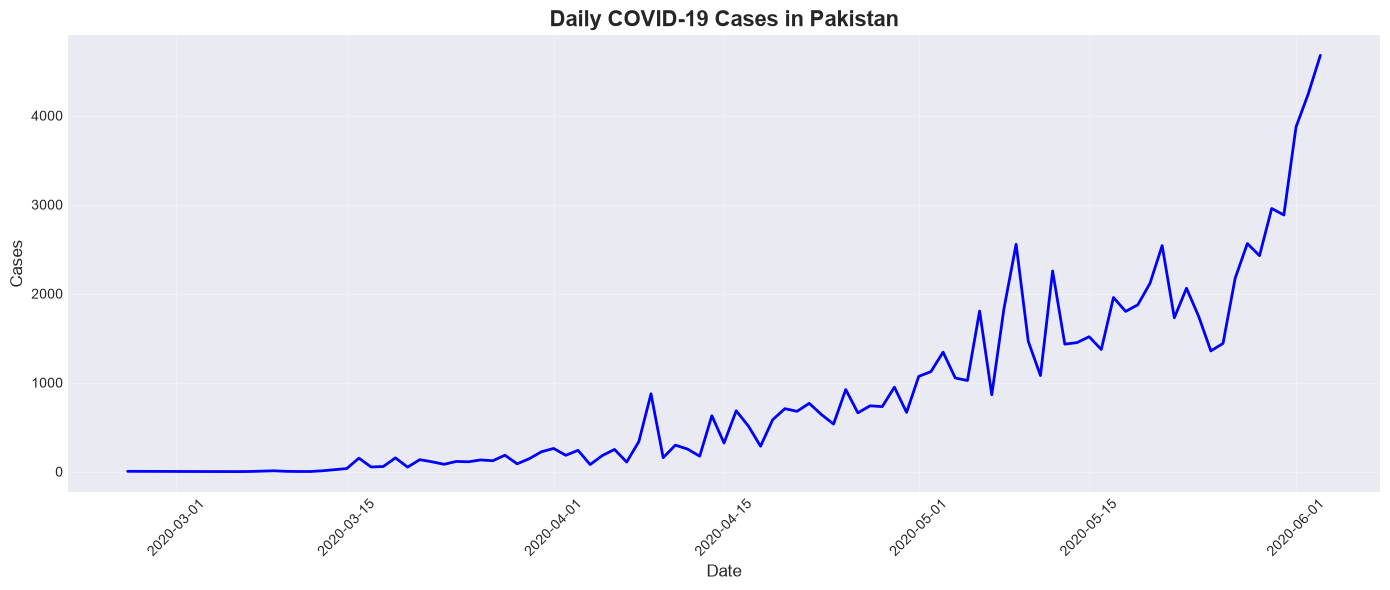

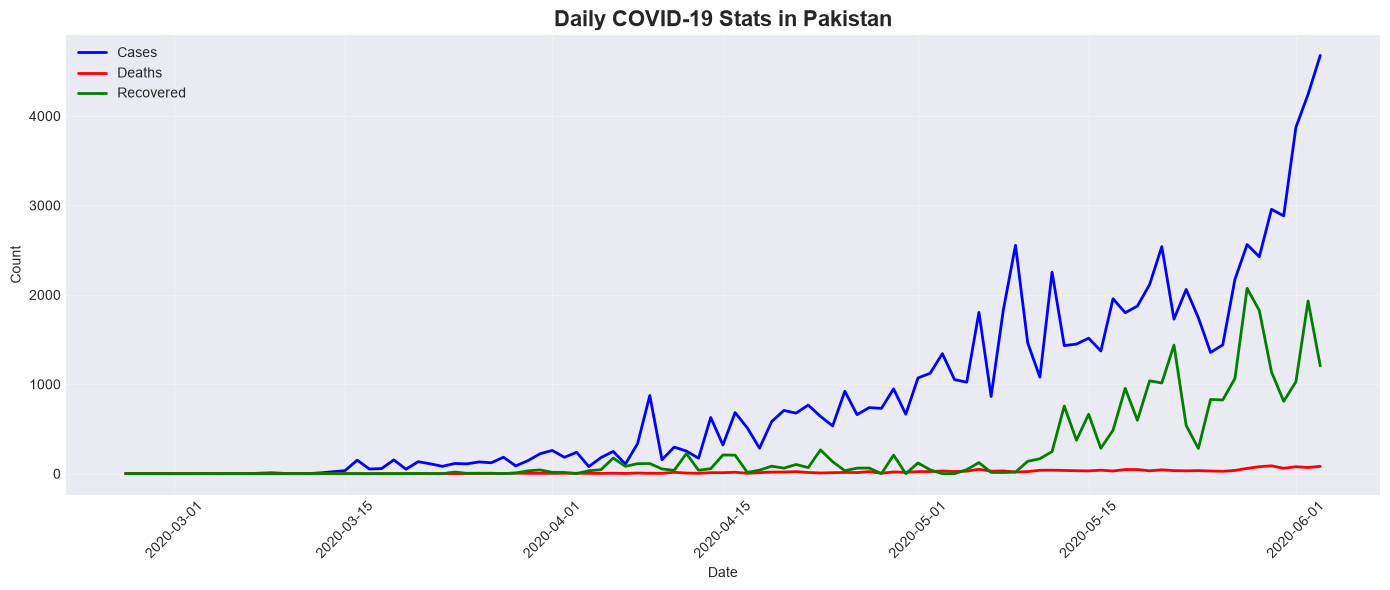

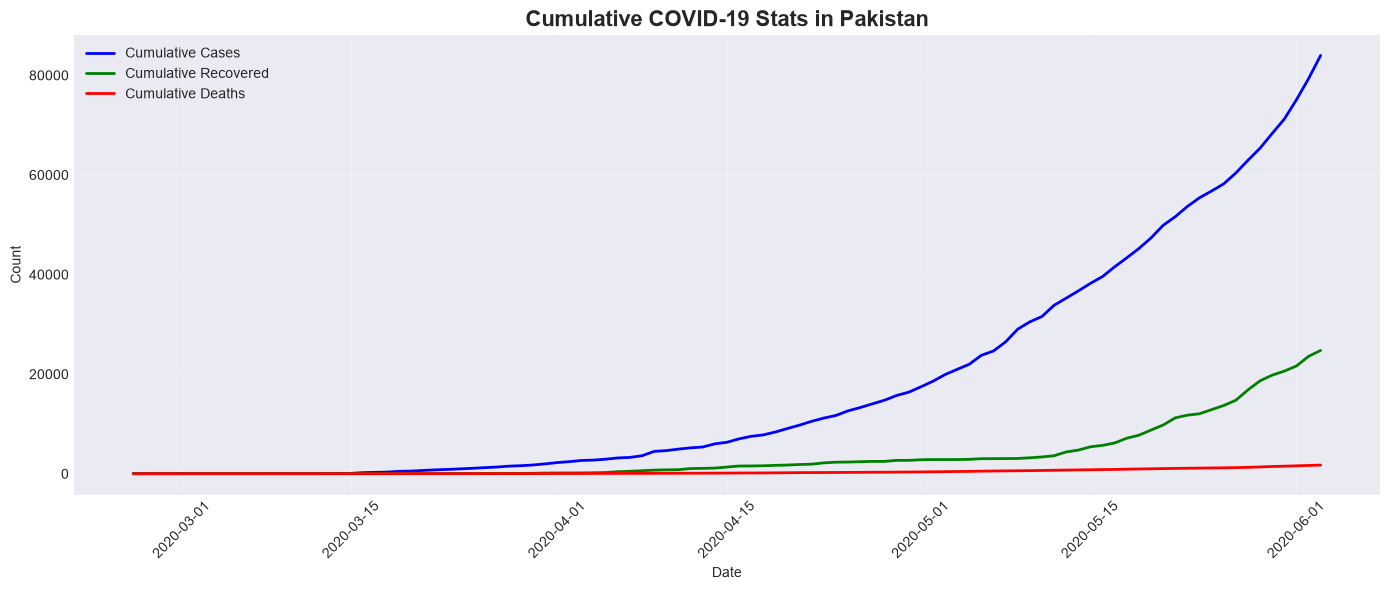

In [ ]:
# ============================================
# CELL 40: Line plot - Daily Cases
# ============================================
plt.figure(figsize=(14, 6))
plt.plot(daily['Date'], daily['Cases'], color='blue', linewidth=2)
plt.title('Daily COVID-19 Cases in Pakistan', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cases', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# CELL 41: Multiple lines - Cases, Deaths, Recovered
# ============================================
plt.figure(figsize=(14, 6))
plt.plot(daily['Date'], daily['Cases'], label='Cases', color='blue', linewidth=2)
plt.plot(daily['Date'], daily['Deaths'], label='Deaths', color='red', linewidth=2)
plt.plot(daily['Date'], daily['Recovered'], label='Recovered', color='green', linewidth=2)
plt.title('Daily COVID-19 Stats in Pakistan', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Count')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# CELL 42: Cumulative plot
# ============================================
plt.figure(figsize=(14, 6))
plt.plot(daily['Date'], daily['Cumulative_Cases'], label='Cumulative Cases', color='blue', linewidth=2)
plt.plot(daily['Date'], daily['Cumulative_Recovered'], label='Cumulative Recovered', color='green', linewidth=2)
plt.plot(daily['Date'], daily['Cumulative_Deaths'], label='Cumulative Deaths', color='red', linewidth=2)
plt.title('Cumulative COVID-19 Stats in Pakistan', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Count')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

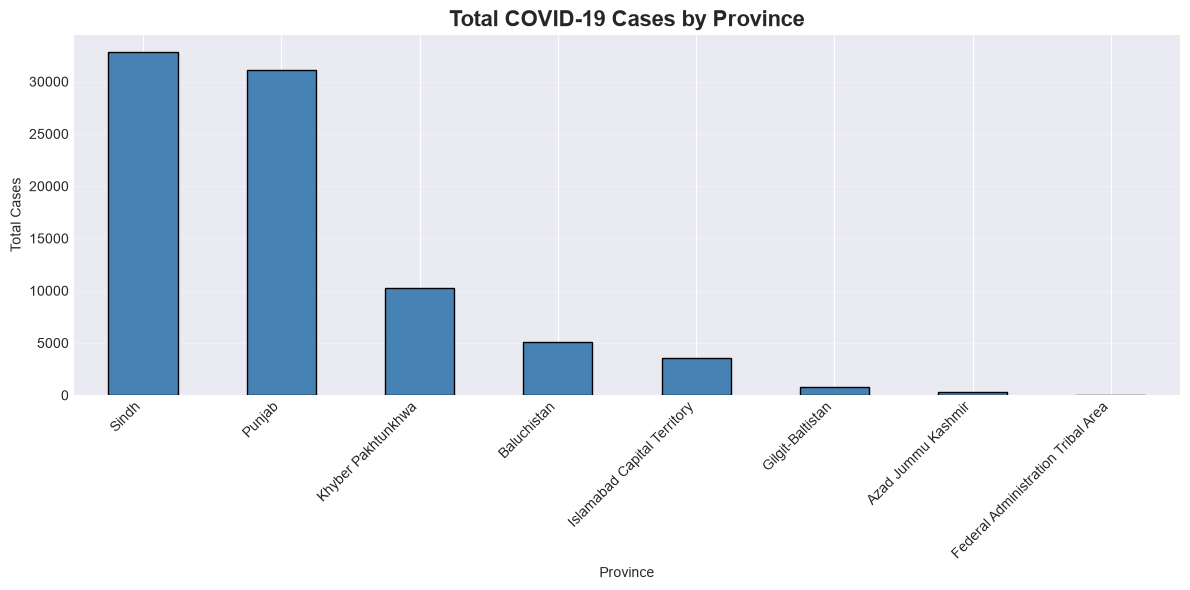

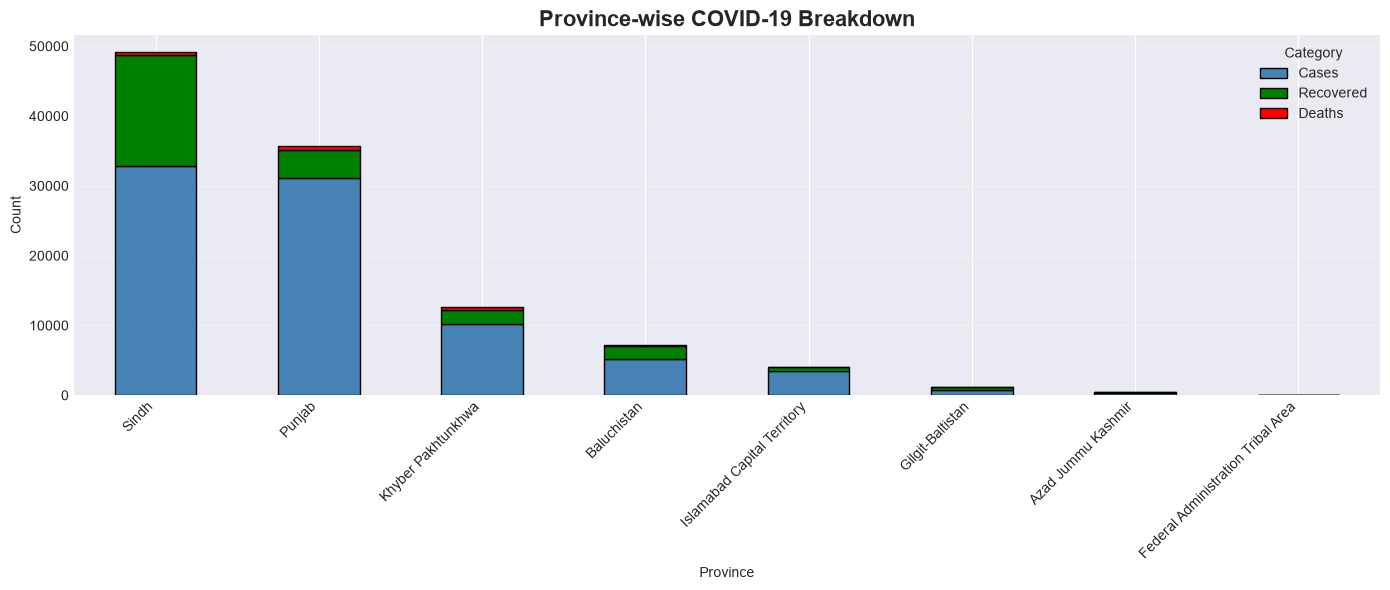

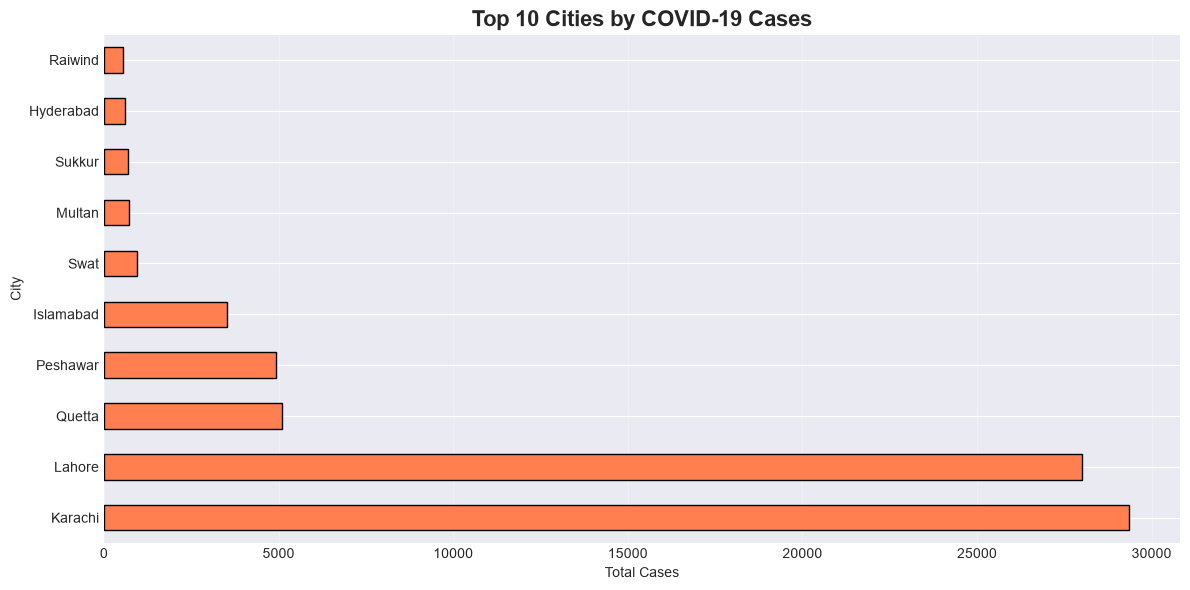

In [ ]:
# ============================================
# CELL 43: Bar chart - Province-wise cases
# ============================================
plt.figure(figsize=(12, 6))
province_stats['Cases'].plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Total COVID-19 Cases by Province', fontsize=16, fontweight='bold')
plt.xlabel('Province')
plt.ylabel('Total Cases')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
# CELL 44: Stacked bar - Cases, Deaths, Recovered by Province
# ============================================
fig, ax = plt.subplots(figsize=(14, 6))
province_stats[['Cases', 'Recovered', 'Deaths']].plot(
    kind='bar', stacked=True, ax=ax,
    color=['steelblue', 'green', 'red'], edgecolor='black'
)
plt.title('Province-wise COVID-19 Breakdown', fontsize=16, fontweight='bold')
plt.xlabel('Province')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Category')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
# CELL 45: Top 10 cities bar chart
# ============================================
plt.figure(figsize=(12, 6))
top_cities['Cases'].plot(kind='barh', color='coral', edgecolor='black')
plt.title('Top 10 Cities by COVID-19 Cases', fontsize=16, fontweight='bold')
plt.xlabel('Total Cases')
plt.ylabel('City')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

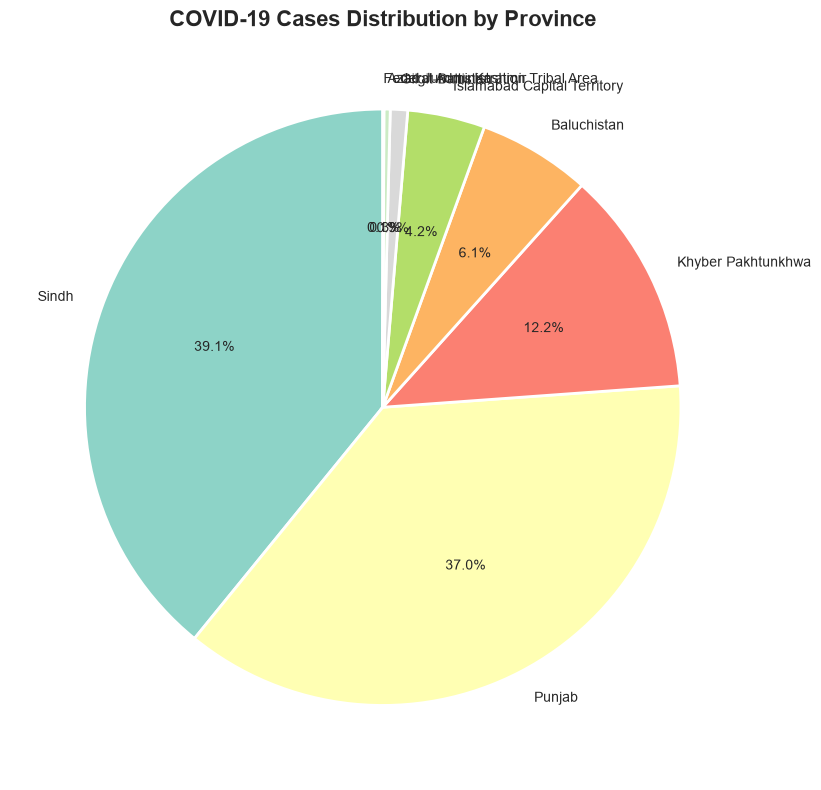

In [ ]:
# ============================================
# CELL 46: Pie chart - Province distribution
# ============================================
plt.figure(figsize=(10, 8))
province_stats['Cases'].plot(
    kind='pie', autopct='%1.1f%%',
    startangle=90, cmap='Set3',
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
plt.title('COVID-19 Cases Distribution by Province', fontsize=16, fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.show()

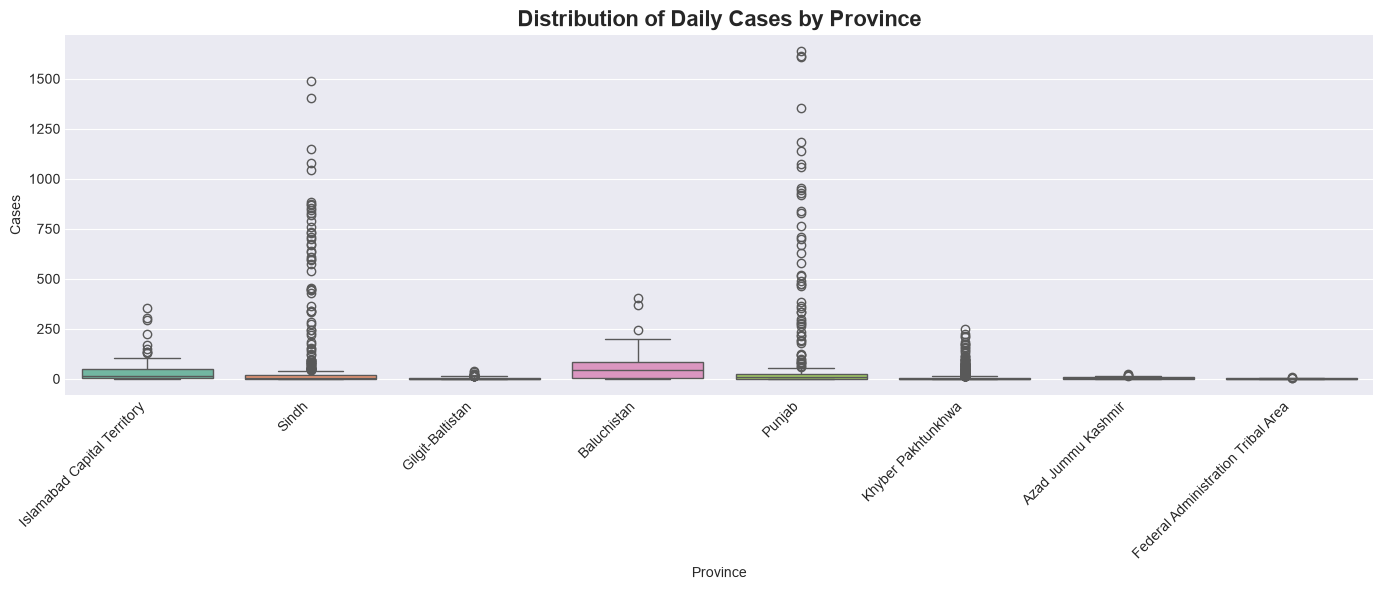

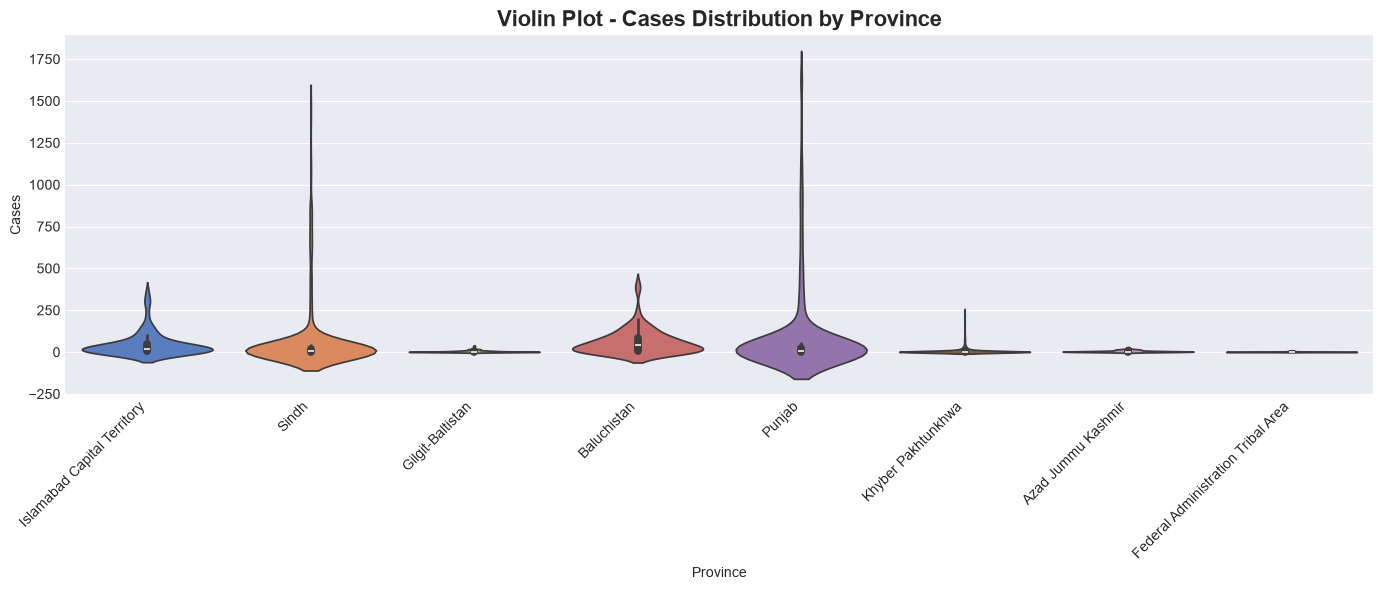

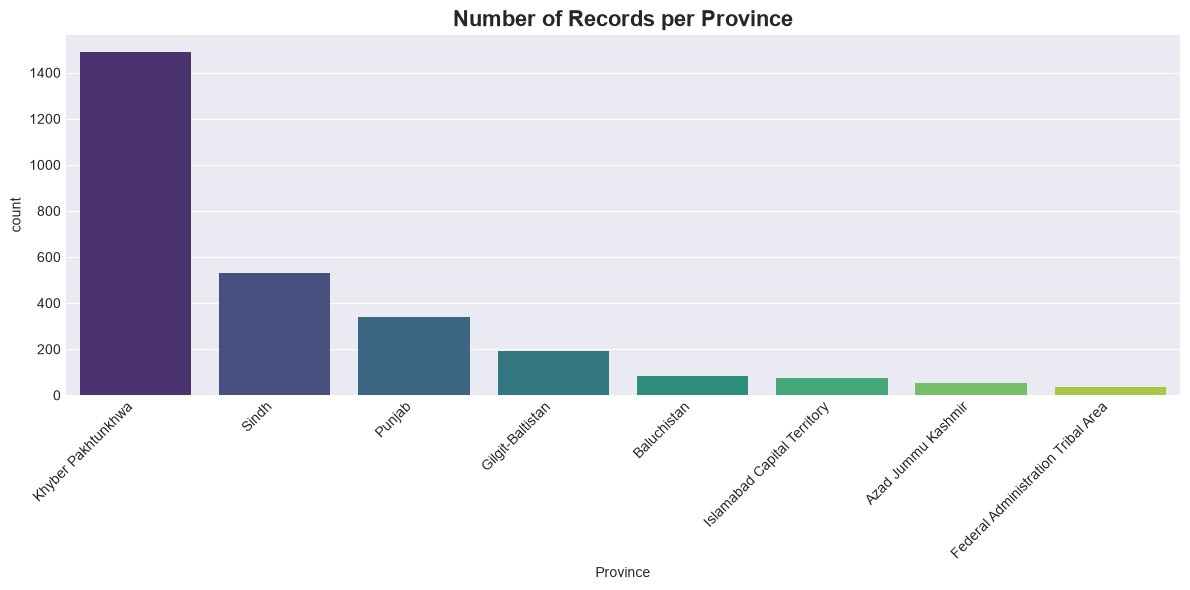

In [ ]:
# ============================================
# CELL 47: Seaborn - Box plot (Cases by Province)
# ============================================
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='Province', y='Cases', palette='Set2')
plt.title('Distribution of Daily Cases by Province', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
# CELL 48: Seaborn - Violin plot
# ============================================
plt.figure(figsize=(14, 6))
sns.violinplot(data=df, x='Province', y='Cases', palette='muted')
plt.title('Violin Plot - Cases Distribution by Province', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
# CELL 49: Seaborn - Count plot
# ============================================
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Province', order=df['Province'].value_counts().index, palette='viridis')
plt.title('Number of Records per Province', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


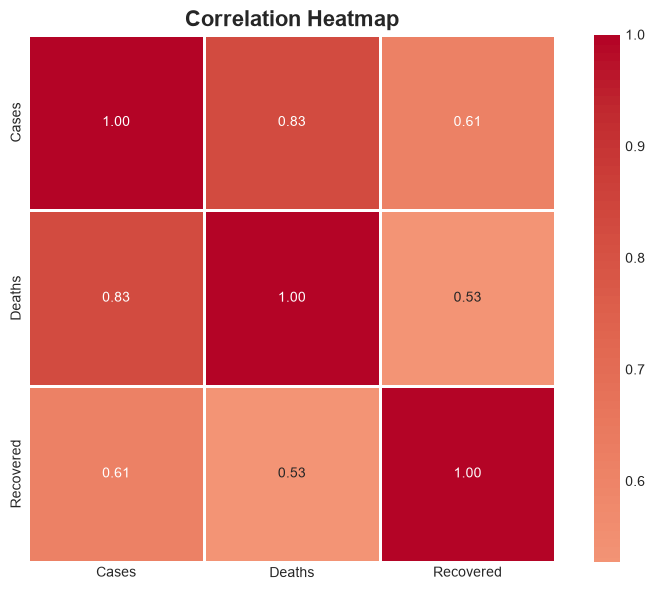

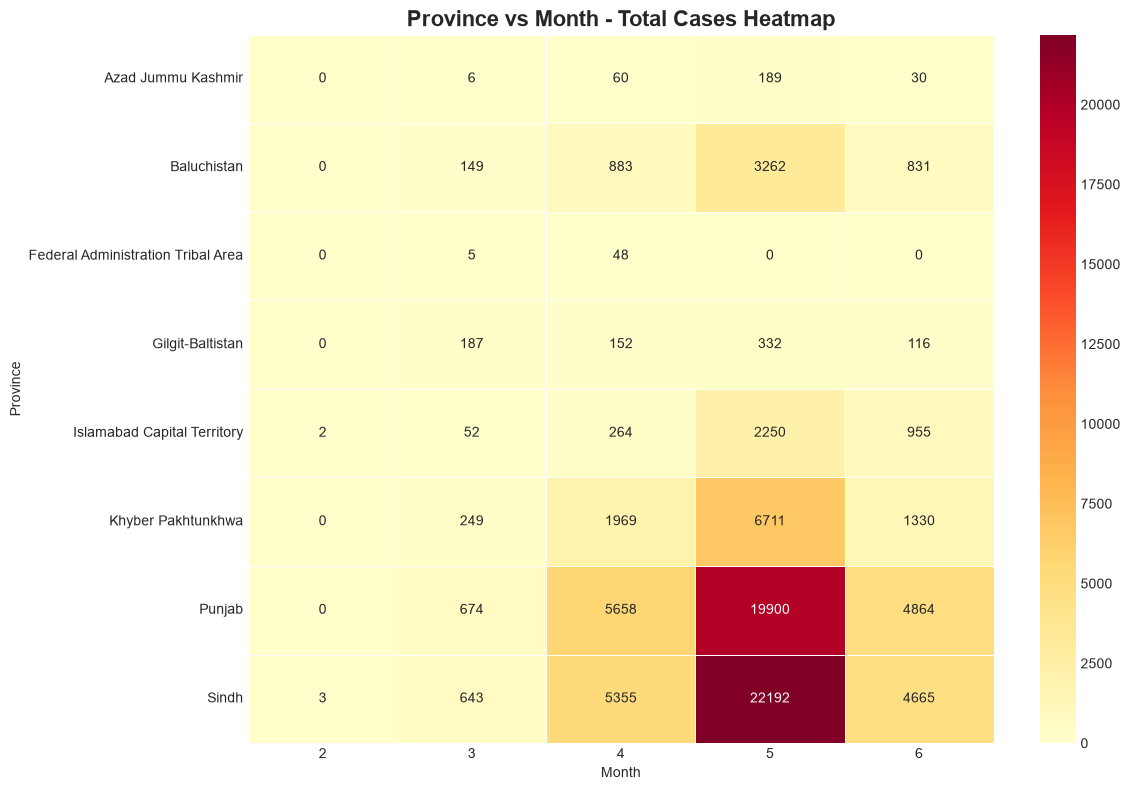

In [ ]:
# ============================================
# CELL 50: Correlation heatmap
# ============================================
plt.figure(figsize=(8, 6))
numeric_df = df[['Cases', 'Deaths', 'Recovered']]
correlation = numeric_df.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=1, square=True)
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
# CELL 51: Province vs Month heatmap
# ============================================
plt.figure(figsize=(12, 8))
sns.heatmap(pivot1, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Province vs Month - Total Cases Heatmap', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Province')
plt.tight_layout()
plt.show()


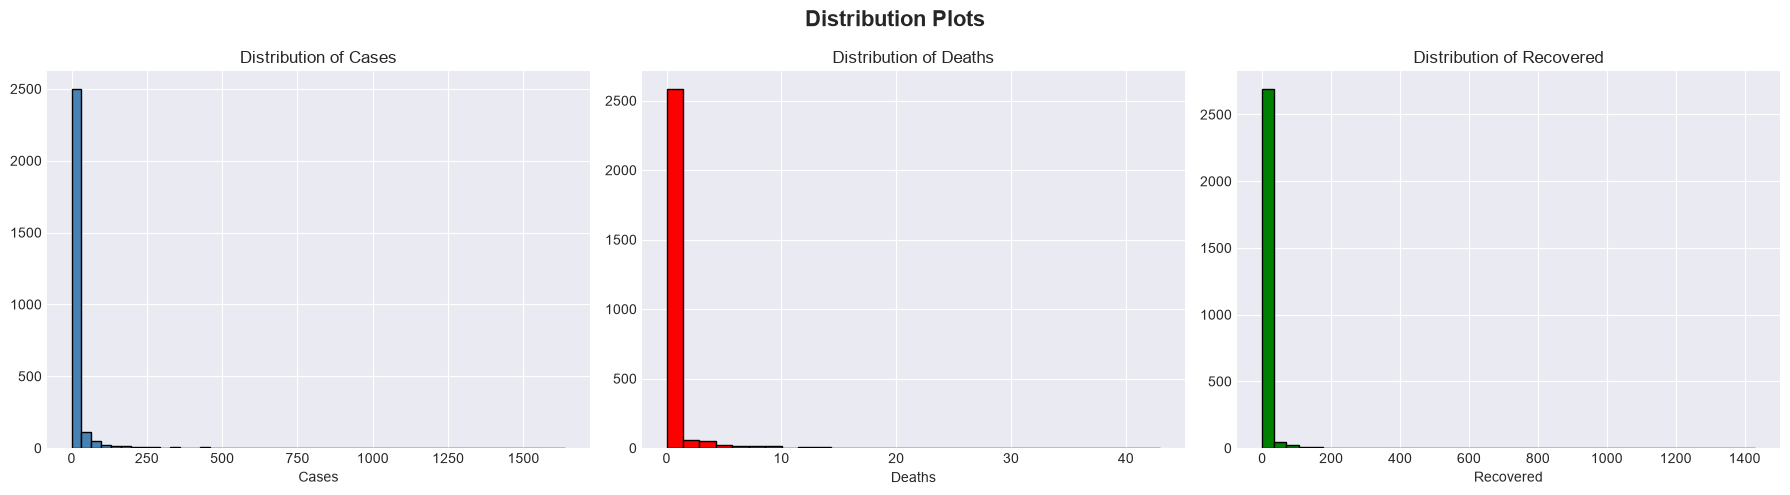

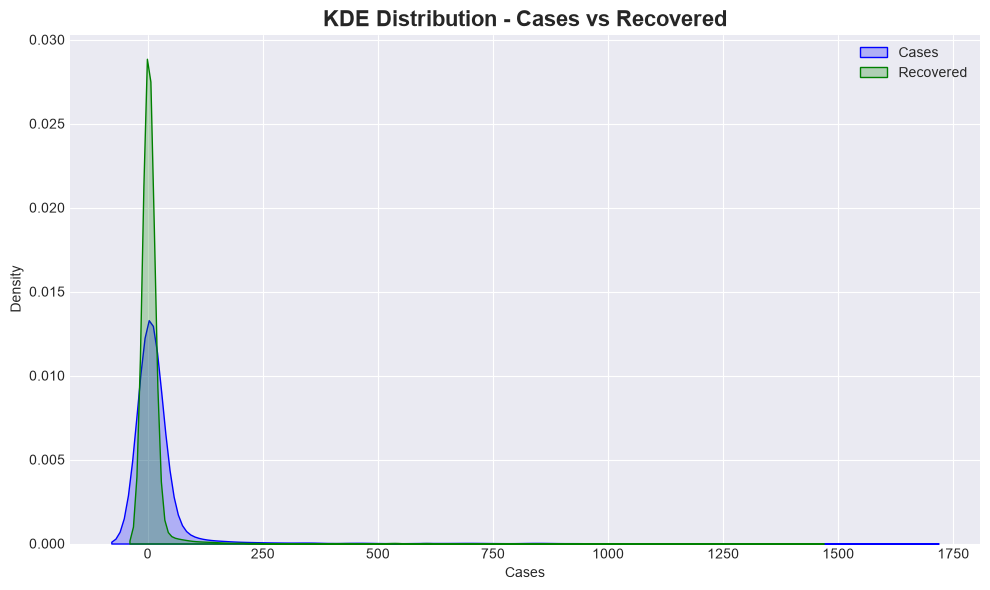

In [ ]:
# ============================================
# CELL 52: Histogram - Cases distribution
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['Cases'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Cases')
axes[0].set_xlabel('Cases')

axes[1].hist(df['Deaths'], bins=30, color='red', edgecolor='black')
axes[1].set_title('Distribution of Deaths')
axes[1].set_xlabel('Deaths')

axes[2].hist(df['Recovered'], bins=40, color='green', edgecolor='black')
axes[2].set_title('Distribution of Recovered')
axes[2].set_xlabel('Recovered')

plt.suptitle('Distribution Plots', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
# CELL 53: KDE Plot
# ============================================
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='Cases', fill=True, color='blue', label='Cases')
sns.kdeplot(data=df, x='Recovered', fill=True, color='green', label='Recovered')
plt.title('KDE Distribution - Cases vs Recovered', fontsize=16, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()


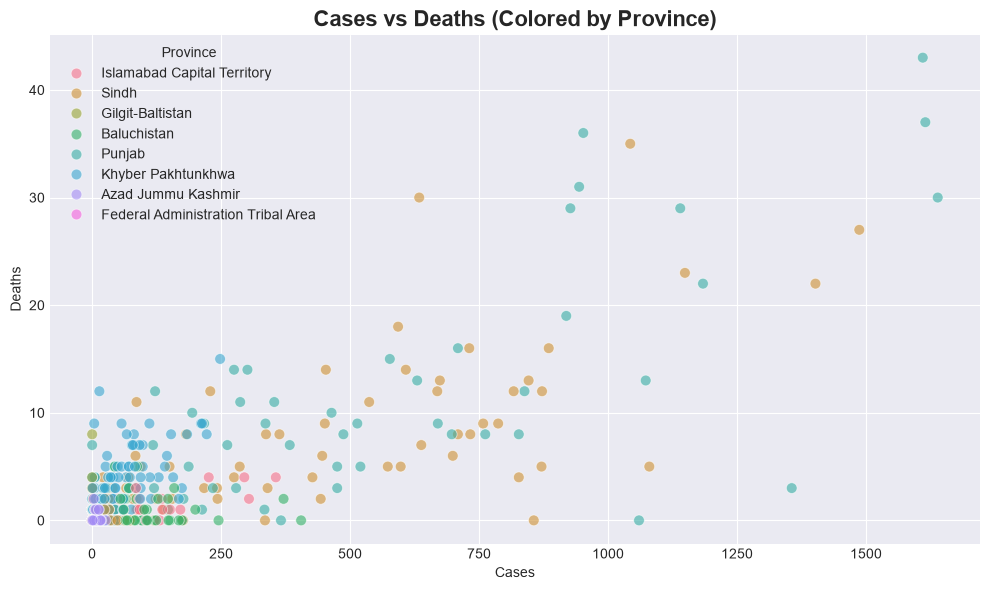

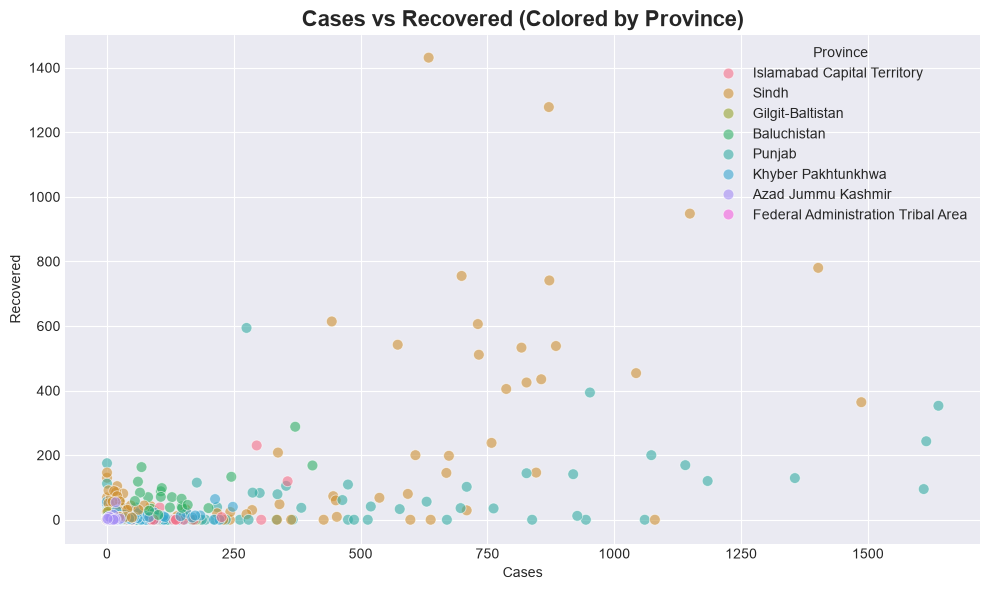

In [ ]:
# ============================================
# CELL 54: Scatter - Cases vs Deaths
# ============================================
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Cases', y='Deaths', hue='Province', alpha=0.6, s=60)
plt.title('Cases vs Deaths (Colored by Province)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()# CELL 55: Scatter - Cases vs Recovered
# ============================================
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Cases', y='Recovered', hue='Province', alpha=0.6, s=60)
plt.title('Cases vs Recovered (Colored by Province)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


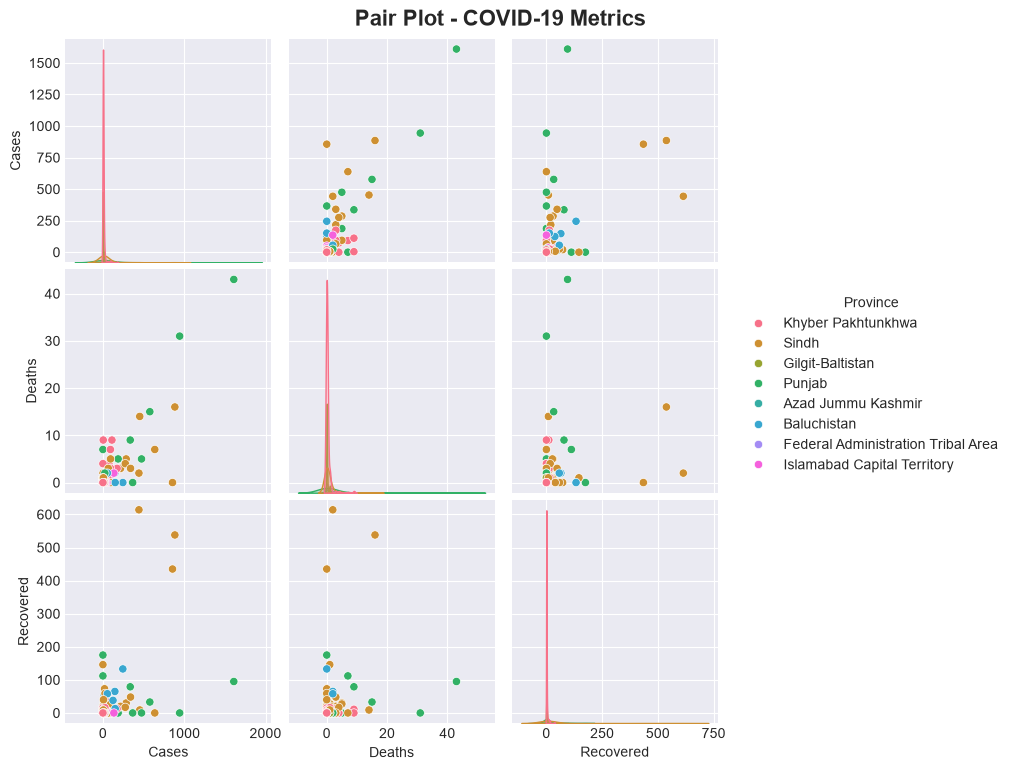

In [ ]:
# ============================================
# CELL 56: Pair plot (sample to speed up)
# ============================================
sample_df = df[['Cases', 'Deaths', 'Recovered', 'Province']].sample(500)
sns.pairplot(sample_df, hue='Province', palette='husl', diag_kind='kde')
plt.suptitle('Pair Plot - COVID-19 Metrics', y=1.02, fontsize=16, fontweight='bold')
plt.show()

In [ ]:
# ============================================
# CELL 57: Plotly - Interactive line chart
# ============================================
import plotly.express as px
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(x=daily['Date'], y=daily['Cases'], name='Cases', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=daily['Date'], y=daily['Recovered'], name='Recovered', line=dict(color='green')))
fig.add_trace(go.Scatter(x=daily['Date'], y=daily['Deaths'], name='Deaths', line=dict(color='red')))

fig.update_layout(
    title='Interactive COVID-19 Trend in Pakistan',
    xaxis_title='Date',
    yaxis_title='Count',
    hovermode='x unified',
    template='plotly_white'
)
fig.show()
# CELL 58: Plotly - Interactive bar chart
# ============================================
fig = px.bar(
    province_stats.reset_index(),
    x='Province', y='Cases',
    color='Cases', color_continuous_scale='Reds',
    title='Interactive Province-wise Cases'
)
fig.show()
# CELL 59: Plotly - Animated chart (Cases over time by Province)
# ============================================
province_daily = df.groupby(['Date', 'Province'])['Cases'].sum().reset_index()

fig = px.bar(
    province_daily,
    x='Province', y='Cases',
    color='Province',
    animation_frame='Date',
    title='Animated Province-wise Cases Over Time',
    range_y=[0, province_daily['Cases'].max() * 1.1]
)
fig.show()
# CELL 60: Plotly - Sunburst chart
# ============================================
fig = px.sunburst(
    df, path=['Province', 'City'],
    values='Cases',
    title='Hierarchical View: Province → City Cases'
)
fig.show()

🇵🇰 PAKISTAN COVID-19 COMPLETE ANALYSIS

📁 Working Directory: d:\DA projects
📄 CSV Files Available:
   ✅ clean_final_data.csv
   ✅ daily_summary.csv
   ✅ goodreads_books_cleaned.csv
   ✅ goodreads_books_dataset.csv
   ✅ Pakistan Intellectual Capital - Computer Science - Ver 1.csv
   ✅ Pakistan Intellectual Capital - Computer Science - Ver 2.csv
   ✅ PK COVID-19-3jun.csv
   ✅ PK_COVID_19_cleaned.csv

✅ Data Loaded: 2798 rows × 7 columns

📊 BASIC EXPLORATION

🔹 First 5 rows:
        Date  Cases  Deaths  Recovered Travel_history                     Province       City
0  2/26/2020      1       0          0          China  Islamabad Capital Territory  Islamabad
1  2/26/2020      2       0          0    Iran/Taftan                        Sindh    Karachi
2  2/29/2020      1       0          0          China  Islamabad Capital Territory  Islamabad
3  2/29/2020      1       0          0    Iran/Taftan                        Sindh    Karachi
4   3/2/2020      1       0          0    Iran/Taftan

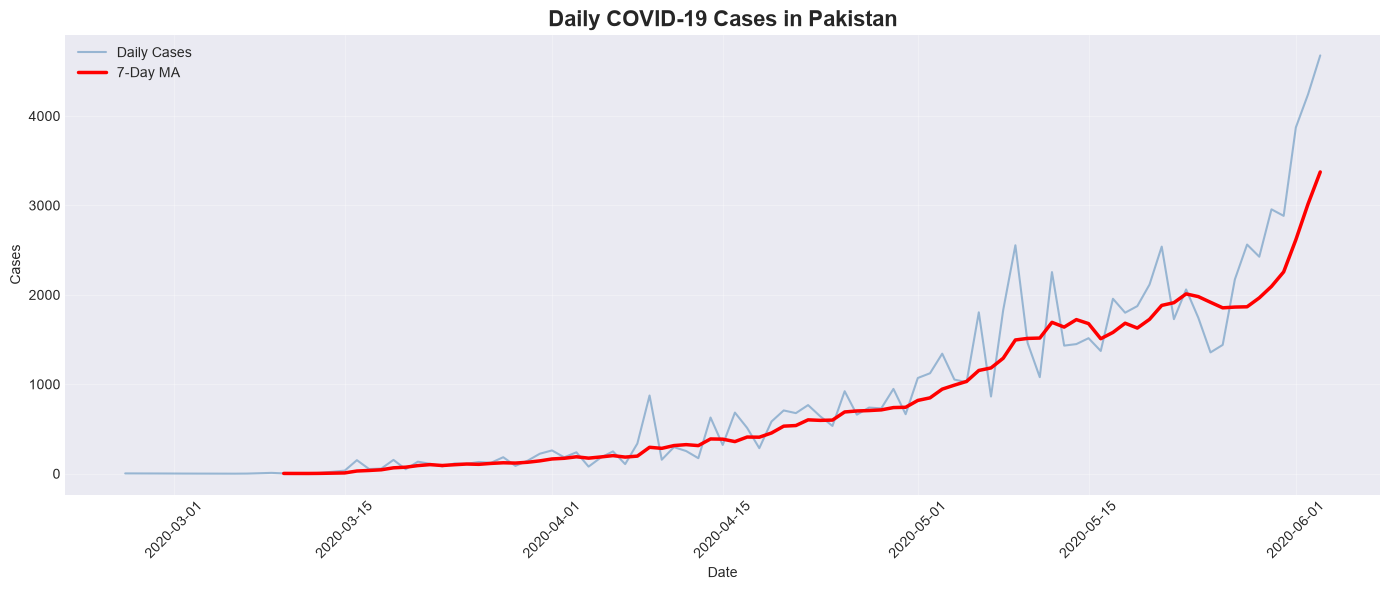

✅ Plot 1: Daily Trend


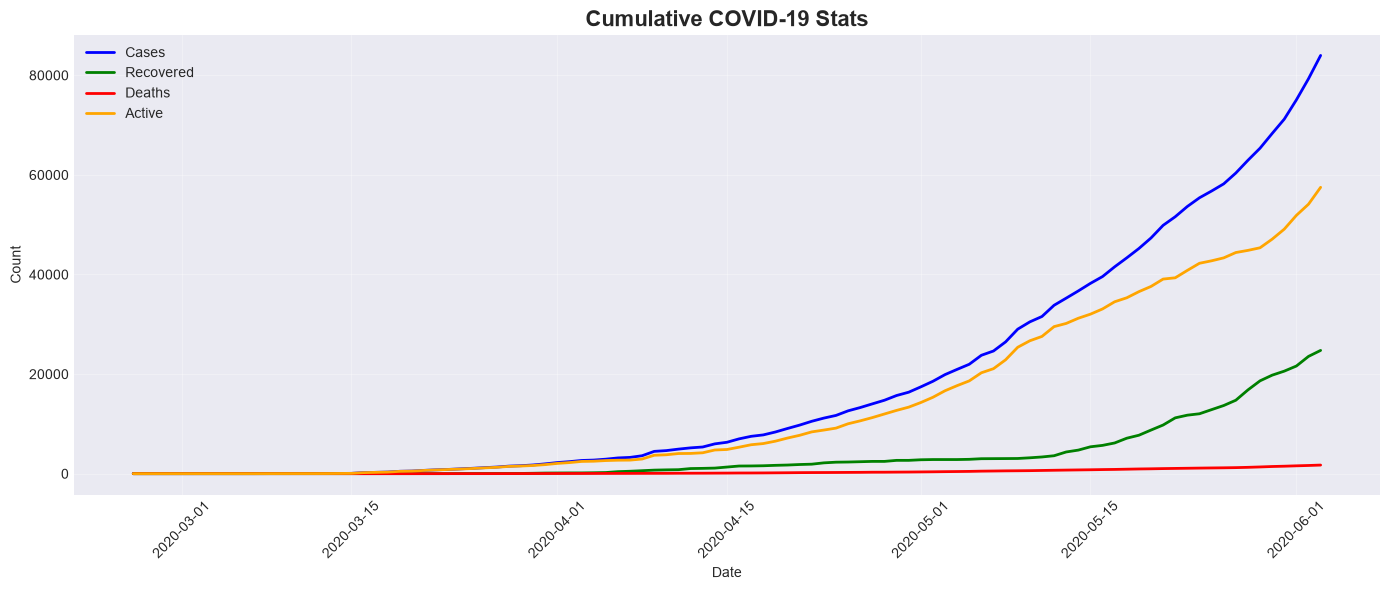

✅ Plot 2: Cumulative


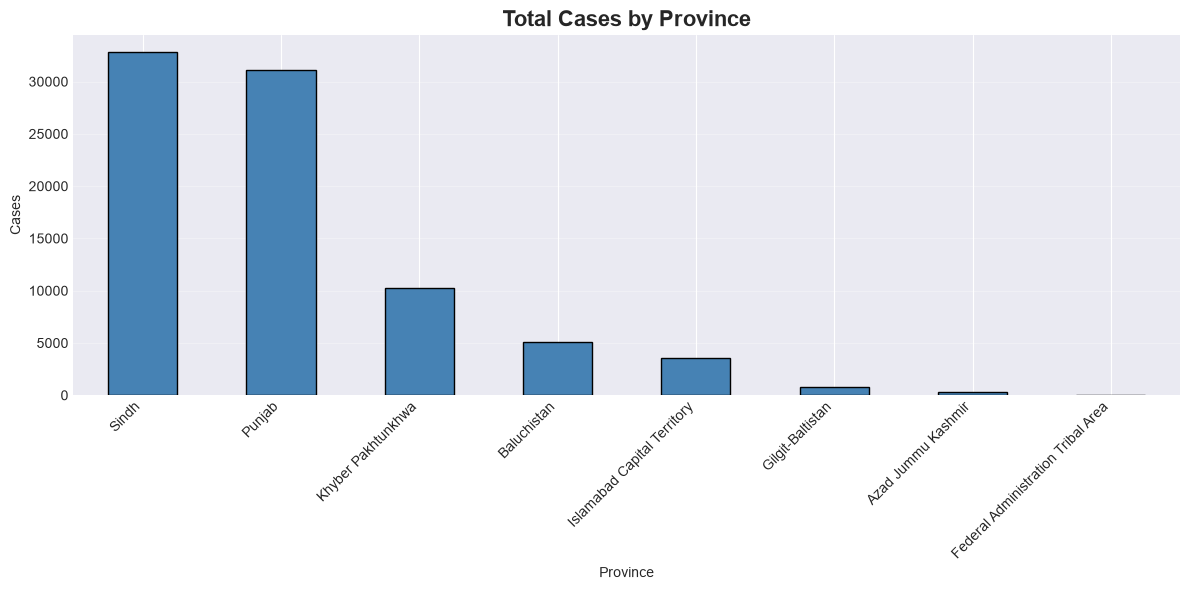

✅ Plot 3: Province Bar


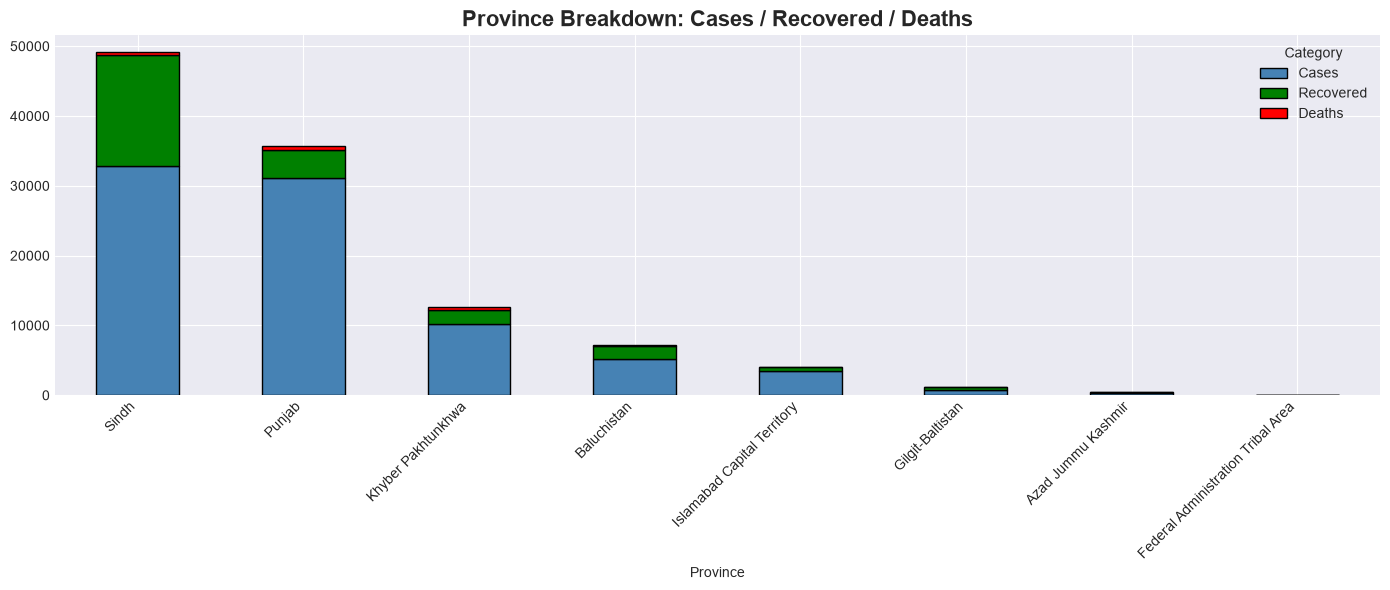

✅ Plot 4: Stacked Bar


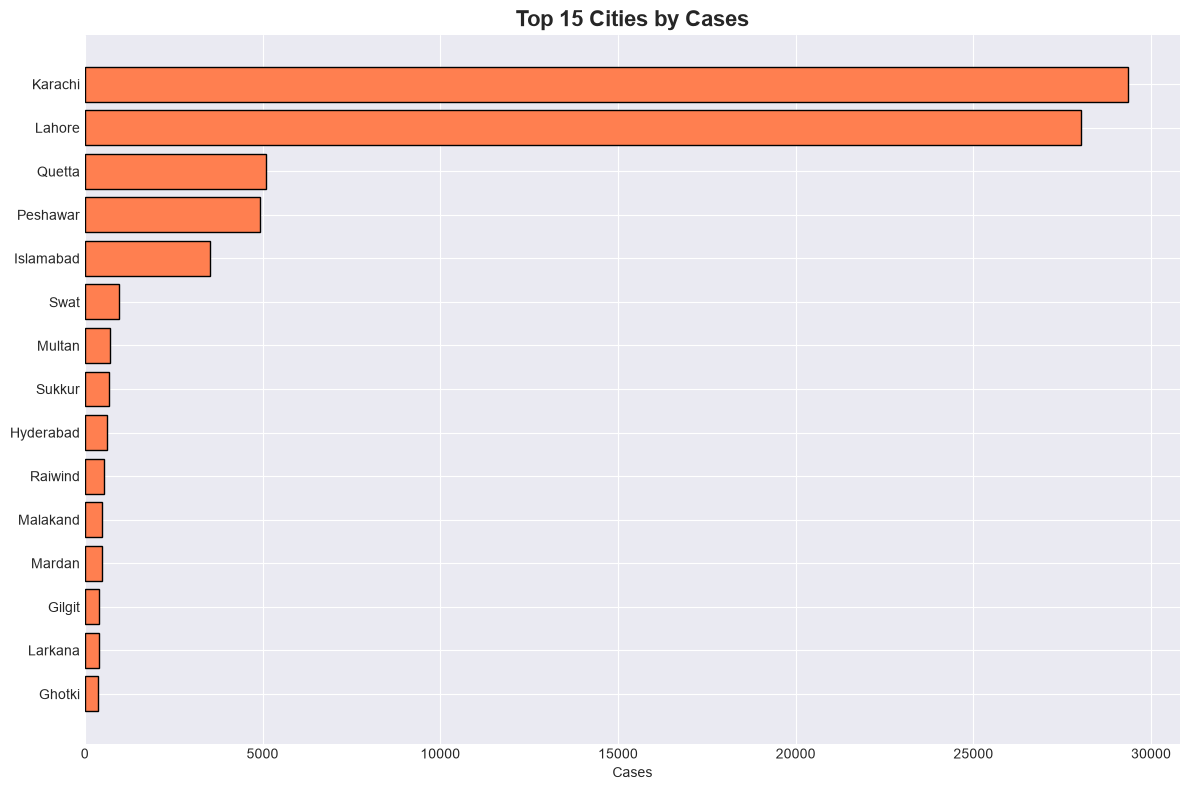

✅ Plot 5: Top 15 Cities


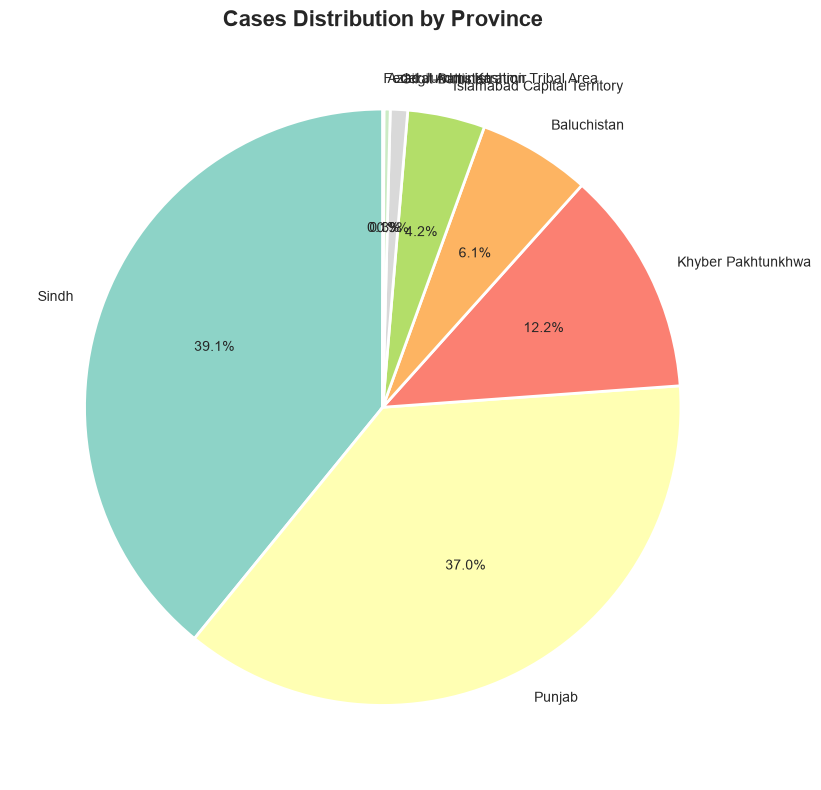

✅ Plot 6: Pie Chart


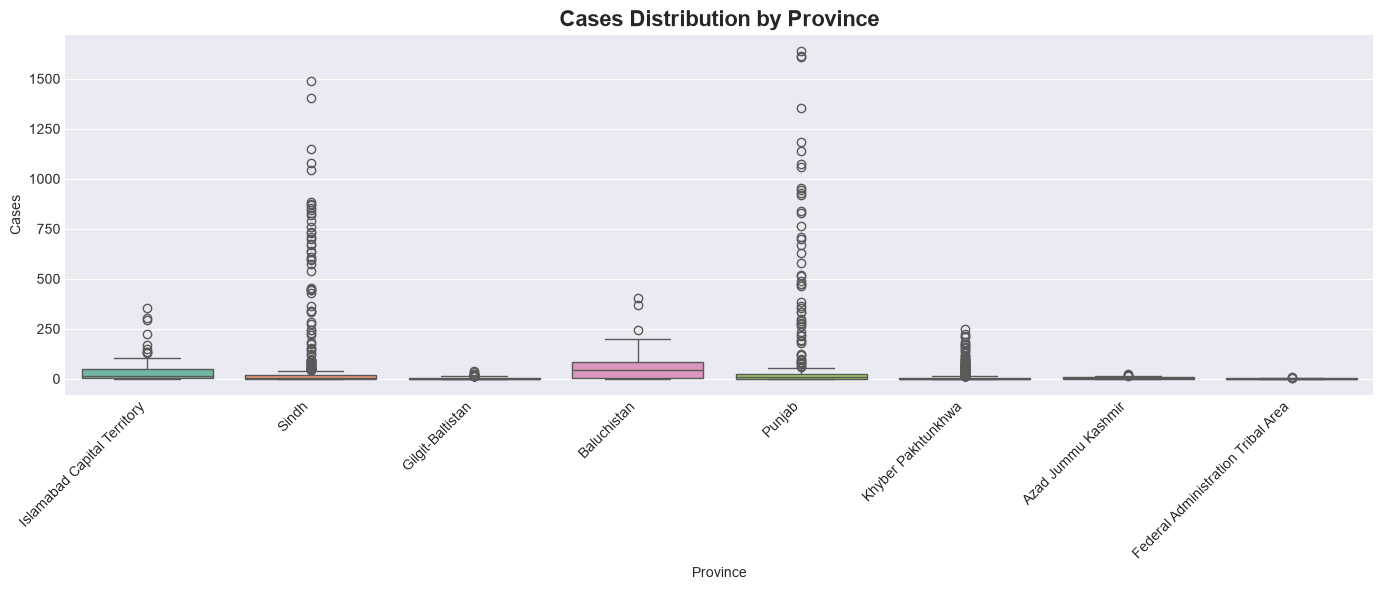

✅ Plot 7: Box Plot


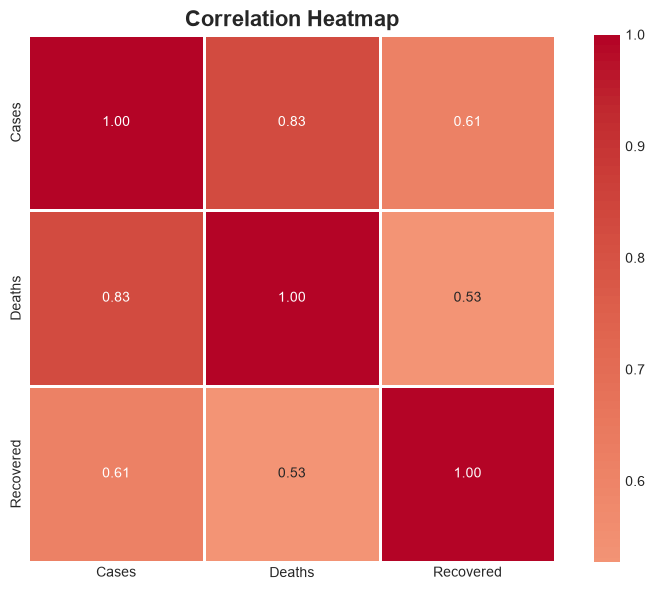

✅ Plot 8: Heatmap


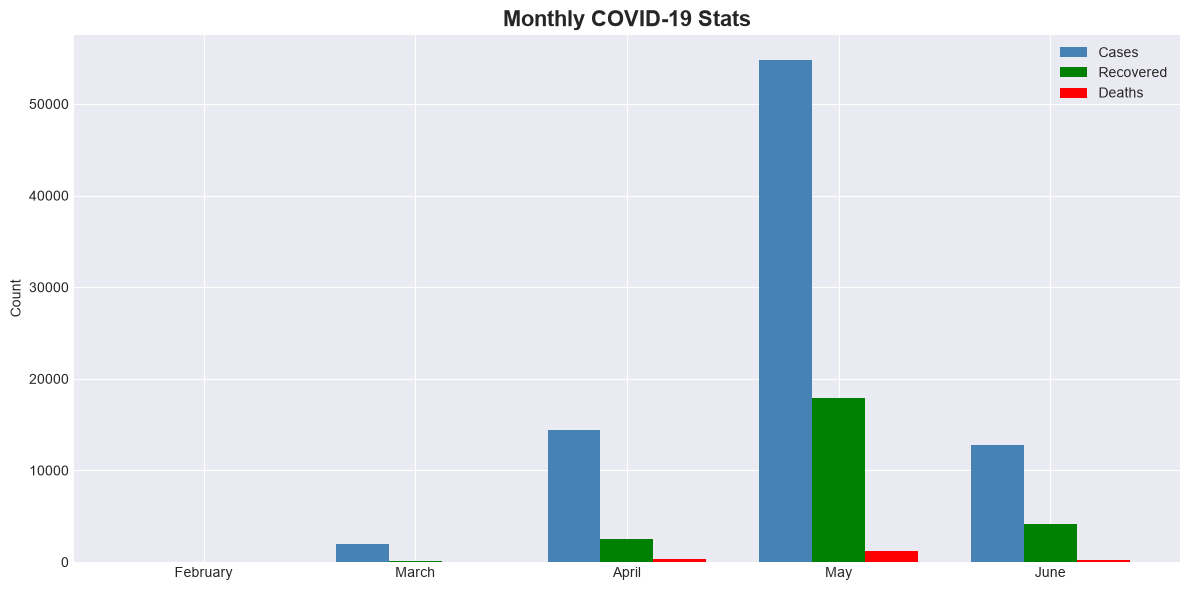

✅ Plot 9: Monthly


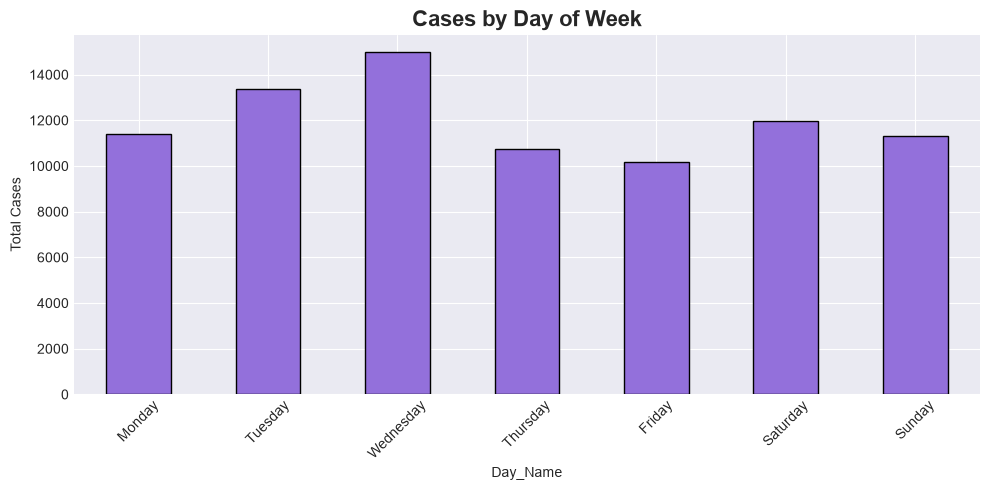

✅ Plot 10: Day of Week


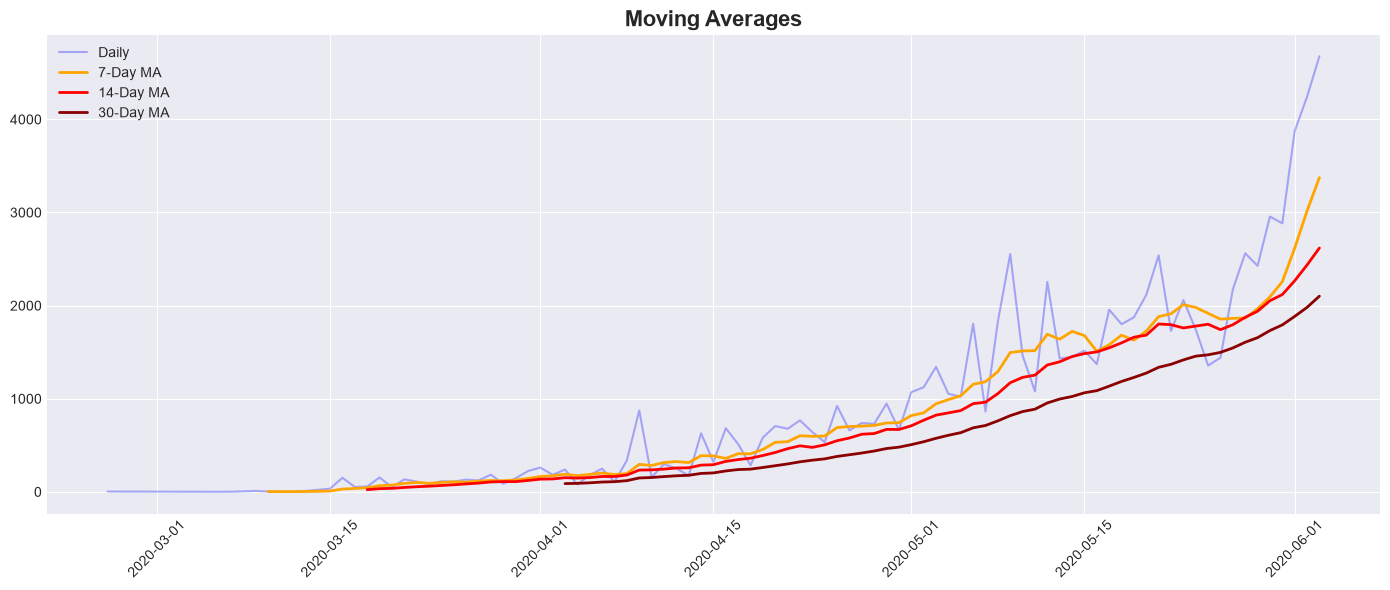

✅ Plot 11: Moving Averages


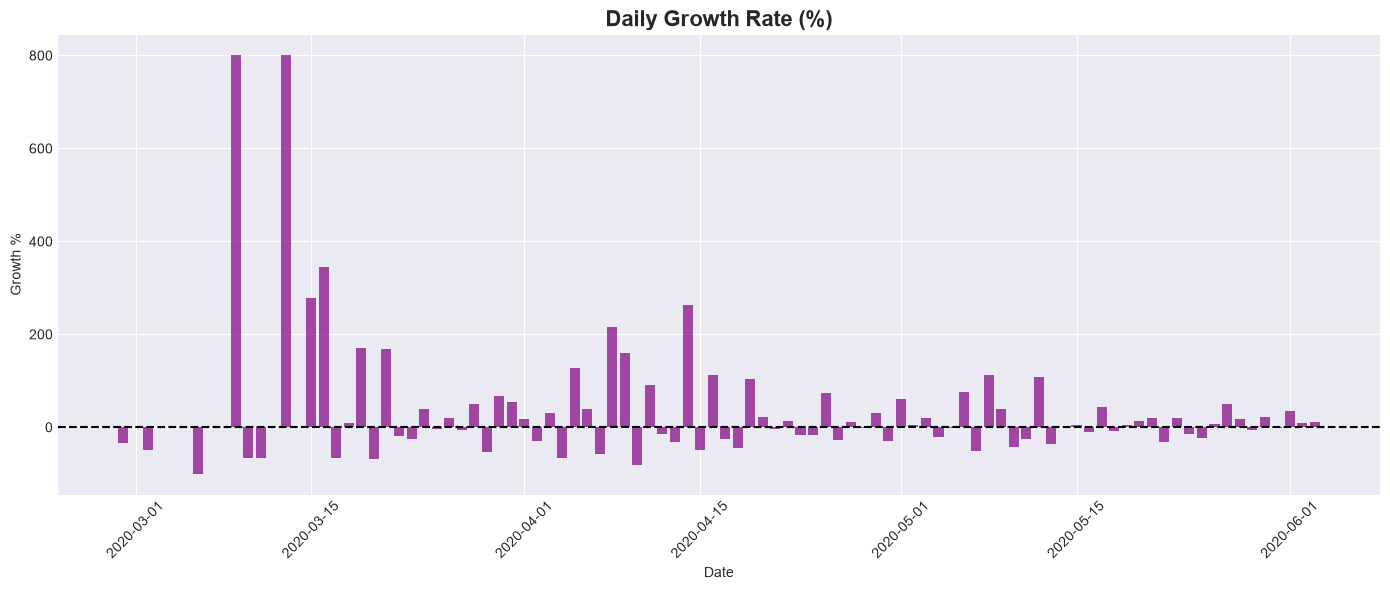

✅ Plot 12: Growth Rate

🔬 STATISTICAL TESTS

🔹 T-Test (Before vs After April):
   T-statistic: -2.9218
   P-value: 0.0035
   Result: ✅ Significant difference

🔹 Normality Test:
   P-value: 0.0000
   Result: ❌ Not normal

🎯 K-MEANS CLUSTERING (CITIES)


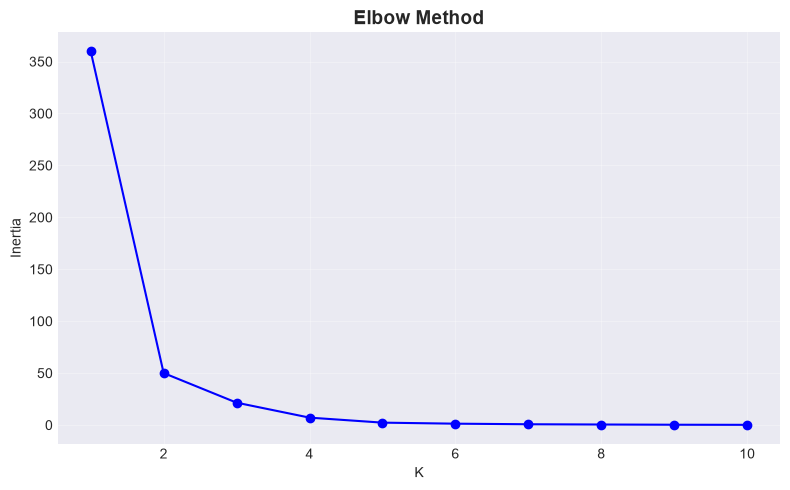

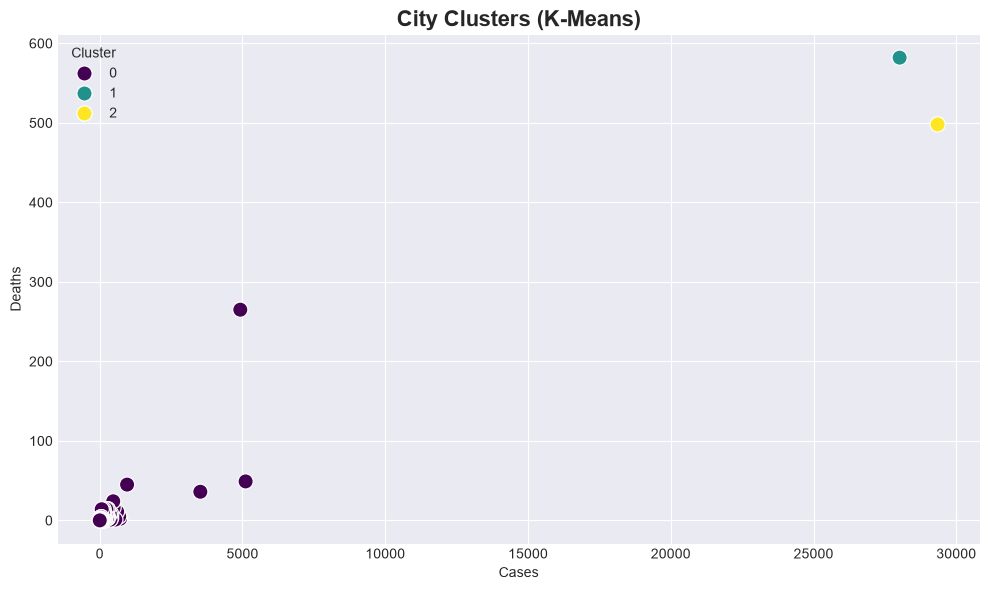

✅ Clustering done — plot_14_clusters.png saved

🔮 30-DAY FORECAST


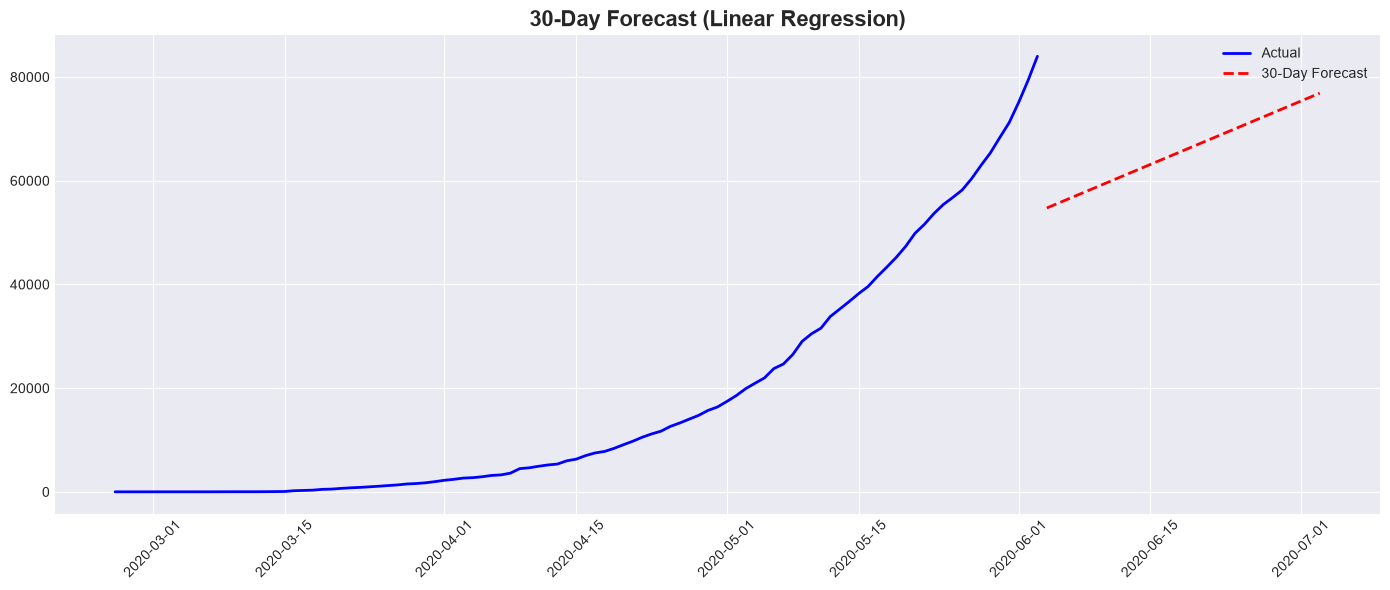

📊 Model R² Score: 0.7979
📅 Predicted cases on 2020-07-03: 76,879

📋 FILES GENERATED
   ✅ out_daily_summary.csv               (8.8 KB)
   ✅ out_province_stats.csv              (0.4 KB)
   ✅ out_city_stats.csv                  (2.3 KB)
   ✅ out_travel_stats.csv                (0.3 KB)
   ✅ out_city_clusters.csv               (2.4 KB)
   ✅ plot_01_daily_trend.png             (78.0 KB)
   ✅ plot_02_cumulative.png              (73.2 KB)
   ✅ plot_03_province.png                (45.2 KB)
   ✅ plot_04_stack.png                   (52.9 KB)
   ✅ plot_05_top_cities.png              (38.0 KB)
   ✅ plot_06_pie.png                     (62.7 KB)
   ✅ plot_07_boxplot.png                 (65.8 KB)
   ✅ plot_08_heatmap.png                 (26.6 KB)
   ✅ plot_09_monthly.png                 (25.6 KB)
   ✅ plot_10_dow.png                     (30.1 KB)
   ✅ plot_11_ma.png                      (94.0 KB)
   ✅ plot_12_growth.png                  (35.5 KB)
   ✅ plot_13_elbow.png                   (24.6 KB)
   

In [ ]:
# ============================================================
# PAKISTAN COVID-19 COMPLETE DATA ANALYSIS
# Ek hi cell mein poora analysis
# ============================================================

# ============================================================
# PART 1: IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*60)
print("🇵🇰 PAKISTAN COVID-19 COMPLETE ANALYSIS")
print("="*60)

# ============================================================
# PART 2: LOAD DATA
# ============================================================
# Apna folder path yahan change karo agar different hai
PROJECT_DIR = r'd:\DA projects'
if os.path.exists(PROJECT_DIR):
    os.chdir(PROJECT_DIR)

print(f"\n📁 Working Directory: {os.getcwd()}")
print(f"📄 CSV Files Available:")
for f in os.listdir('.'):
    if f.endswith('.csv'):
        print(f"   ✅ {f}")

# Load main data file
df = pd.read_csv('PK COVID-19-3jun.csv')
print(f"\n✅ Data Loaded: {df.shape[0]} rows × {df.shape[1]} columns")

# ============================================================
# PART 3: BASIC EXPLORATION
# ============================================================
print("\n" + "="*60)
print("📊 BASIC EXPLORATION")
print("="*60)
print("\n🔹 First 5 rows:")
print(df.head())
print("\n🔹 Data Info:")
df.info()
print("\n🔹 Missing Values:")
print(df.isnull().sum())
print(f"\n🔹 Duplicates: {df.duplicated().sum()}")

# ============================================================
# PART 4: DATA CLEANING
# ============================================================
print("\n" + "="*60)
print("🧹 DATA CLEANING")
print("="*60)

df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date'])
df['Province'] = df['Province'].astype(str).str.strip().str.title()
df['City'] = df['City'].astype(str).str.strip().str.title()
df['Cases'] = df['Cases'].fillna(0)
df['Deaths'] = df['Deaths'].fillna(0)
df['Recovered'] = df['Recovered'].fillna(0)
df['Travel_history'] = df['Travel_history'].fillna('Unknown')

# Date parts
df['Year'] = df['Date'].dt.year
df['Month_Num'] = df['Date'].dt.month
df['Month'] = df['Date'].dt.month_name()
df['Day_Name'] = df['Date'].dt.day_name()
df['Week'] = df['Date'].dt.isocalendar().week

print(f"✅ Cleaned Data: {df.shape}")
print(f"📅 Date Range: {df['Date'].min().date()} to {df['Date'].max().date()}")

# ============================================================
# PART 5: OVERALL STATISTICS
# ============================================================
print("\n" + "="*60)
print("📈 OVERALL STATISTICS")
print("="*60)

total_cases = df['Cases'].sum()
total_deaths = df['Deaths'].sum()
total_recovered = df['Recovered'].sum()
active = total_cases - total_deaths - total_recovered

print(f"Total Cases:     {total_cases:>12,.0f}")
print(f"Total Deaths:    {total_deaths:>12,.0f}")
print(f"Total Recovered: {total_recovered:>12,.0f}")
print(f"Active Cases:    {active:>12,.0f}")
print(f"Death Rate:      {(total_deaths/total_cases)*100:>11.2f}%")
print(f"Recovery Rate:   {(total_recovered/total_cases)*100:>11.2f}%")

# ============================================================
# PART 6: DAILY AGGREGATION
# ============================================================
daily = df.groupby('Date').agg({
    'Cases': 'sum', 'Deaths': 'sum', 'Recovered': 'sum'
}).reset_index()

daily['Cumulative_Cases'] = daily['Cases'].cumsum()
daily['Cumulative_Deaths'] = daily['Deaths'].cumsum()
daily['Cumulative_Recovered'] = daily['Recovered'].cumsum()
daily['Active'] = daily['Cumulative_Cases'] - daily['Cumulative_Deaths'] - daily['Cumulative_Recovered']
daily['MA_7'] = daily['Cases'].rolling(7).mean()
daily['MA_14'] = daily['Cases'].rolling(14).mean()
daily['MA_30'] = daily['Cases'].rolling(30).mean()
daily['Growth_%'] = daily['Cases'].pct_change() * 100

daily.to_csv('out_daily_summary.csv', index=False)
print("\n✅ Saved: out_daily_summary.csv")

# ============================================================
# PART 7: PROVINCE STATS
# ============================================================
province_stats = df.groupby('Province').agg({
    'Cases': 'sum', 'Deaths': 'sum', 'Recovered': 'sum'
}).sort_values('Cases', ascending=False)

province_stats['Active'] = province_stats['Cases'] - province_stats['Deaths'] - province_stats['Recovered']
province_stats['Death_Rate_%'] = (province_stats['Deaths'] / province_stats['Cases'] * 100).round(2)
province_stats['Recovery_%'] = (province_stats['Recovered'] / province_stats['Cases'] * 100).round(2)

print("\n" + "="*60)
print("🗺️ PROVINCE-WISE STATS")
print("="*60)
print(province_stats)
province_stats.to_csv('out_province_stats.csv')

# ============================================================
# PART 8: CITY STATS
# ============================================================
city_stats = df.groupby('City').agg({
    'Cases': 'sum', 'Deaths': 'sum', 'Recovered': 'sum'
}).sort_values('Cases', ascending=False)

print("\n" + "="*60)
print("🏙️ TOP 15 CITIES")
print("="*60)
print(city_stats.head(15))
city_stats.to_csv('out_city_stats.csv')

# ============================================================
# PART 9: TRAVEL HISTORY STATS
# ============================================================
travel_stats = df.groupby('Travel_history').agg({
    'Cases': 'sum', 'Deaths': 'sum', 'Recovered': 'sum'
}).sort_values('Cases', ascending=False)

print("\n" + "="*60)
print("✈️ TRAVEL HISTORY STATS (Top 10)")
print("="*60)
print(travel_stats.head(10))
travel_stats.to_csv('out_travel_stats.csv')

# ============================================================
# PART 10: VISUALIZATIONS
# ============================================================
print("\n" + "="*60)
print("📊 GENERATING CHARTS...")
print("="*60)

# ---- Plot 1: Daily Trend ----
plt.figure(figsize=(14, 6))
plt.plot(daily['Date'], daily['Cases'], color='steelblue', linewidth=1.5, label='Daily Cases', alpha=0.5)
plt.plot(daily['Date'], daily['MA_7'], color='red', linewidth=2.5, label='7-Day MA')
plt.title('Daily COVID-19 Cases in Pakistan', fontsize=16, fontweight='bold')
plt.xlabel('Date'); plt.ylabel('Cases')
plt.legend(); plt.xticks(rotation=45); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('plot_01_daily_trend.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Plot 1: Daily Trend")

# ---- Plot 2: Cumulative ----
plt.figure(figsize=(14, 6))
plt.plot(daily['Date'], daily['Cumulative_Cases'], label='Cases', color='blue', linewidth=2)
plt.plot(daily['Date'], daily['Cumulative_Recovered'], label='Recovered', color='green', linewidth=2)
plt.plot(daily['Date'], daily['Cumulative_Deaths'], label='Deaths', color='red', linewidth=2)
plt.plot(daily['Date'], daily['Active'], label='Active', color='orange', linewidth=2)
plt.title('Cumulative COVID-19 Stats', fontsize=16, fontweight='bold')
plt.xlabel('Date'); plt.ylabel('Count')
plt.legend(); plt.xticks(rotation=45); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('plot_02_cumulative.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Plot 2: Cumulative")

# ---- Plot 3: Province Bar ----
plt.figure(figsize=(12, 6))
province_stats['Cases'].plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Total Cases by Province', fontsize=16, fontweight='bold')
plt.xlabel('Province'); plt.ylabel('Cases')
plt.xticks(rotation=45, ha='right'); plt.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig('plot_03_province.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Plot 3: Province Bar")

# ---- Plot 4: Stacked Bar ----
fig, ax = plt.subplots(figsize=(14, 6))
province_stats[['Cases', 'Recovered', 'Deaths']].plot(
    kind='bar', stacked=True, ax=ax,
    color=['steelblue', 'green', 'red'], edgecolor='black'
)
plt.title('Province Breakdown: Cases / Recovered / Deaths', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right'); plt.legend(title='Category')
plt.tight_layout(); plt.savefig('plot_04_stack.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Plot 4: Stacked Bar")

# ---- Plot 5: Top 15 Cities ----
plt.figure(figsize=(12, 8))
top15 = city_stats.head(15)
plt.barh(top15.index[::-1], top15['Cases'][::-1], color='coral', edgecolor='black')
plt.title('Top 15 Cities by Cases', fontsize=16, fontweight='bold')
plt.xlabel('Cases')
plt.tight_layout(); plt.savefig('plot_05_top_cities.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Plot 5: Top 15 Cities")

# ---- Plot 6: Pie Chart ----
plt.figure(figsize=(10, 8))
province_stats['Cases'].plot(
    kind='pie', autopct='%1.1f%%', startangle=90,
    cmap='Set3', wedgeprops={'edgecolor':'white','linewidth':2}
)
plt.title('Cases Distribution by Province', fontsize=16, fontweight='bold')
plt.ylabel('')
plt.tight_layout(); plt.savefig('plot_06_pie.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Plot 6: Pie Chart")

# ---- Plot 7: Box Plot ----
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='Province', y='Cases', palette='Set2')
plt.title('Cases Distribution by Province', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.savefig('plot_07_boxplot.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Plot 7: Box Plot")

# ---- Plot 8: Correlation Heatmap ----
plt.figure(figsize=(8, 6))
corr = df[['Cases', 'Deaths', 'Recovered']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=1, square=True)
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.savefig('plot_08_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Plot 8: Heatmap")

# ---- Plot 9: Monthly ----
monthly = df.groupby(['Month_Num', 'Month']).agg({
    'Cases': 'sum', 'Deaths': 'sum', 'Recovered': 'sum'
}).reset_index().sort_values('Month_Num')

plt.figure(figsize=(12, 6))
x = np.arange(len(monthly)); width = 0.25
plt.bar(x - width, monthly['Cases'], width, label='Cases', color='steelblue')
plt.bar(x, monthly['Recovered'], width, label='Recovered', color='green')
plt.bar(x + width, monthly['Deaths'], width, label='Deaths', color='red')
plt.xticks(x, monthly['Month'])
plt.title('Monthly COVID-19 Stats', fontsize=16, fontweight='bold')
plt.ylabel('Count'); plt.legend()
plt.tight_layout(); plt.savefig('plot_09_monthly.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Plot 9: Monthly")

# ---- Plot 10: Day of Week ----
dow = df.groupby('Day_Name')['Cases'].sum().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)
plt.figure(figsize=(10, 5))
dow.plot(kind='bar', color='mediumpurple', edgecolor='black')
plt.title('Cases by Day of Week', fontsize=16, fontweight='bold')
plt.ylabel('Total Cases'); plt.xticks(rotation=45)
plt.tight_layout(); plt.savefig('plot_10_dow.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Plot 10: Day of Week")

# ---- Plot 11: Moving Averages ----
plt.figure(figsize=(14, 6))
plt.plot(daily['Date'], daily['Cases'], alpha=0.3, color='blue', label='Daily')
plt.plot(daily['Date'], daily['MA_7'], color='orange', linewidth=2, label='7-Day MA')
plt.plot(daily['Date'], daily['MA_14'], color='red', linewidth=2, label='14-Day MA')
plt.plot(daily['Date'], daily['MA_30'], color='darkred', linewidth=2, label='30-Day MA')
plt.title('Moving Averages', fontsize=16, fontweight='bold')
plt.legend(); plt.xticks(rotation=45)
plt.tight_layout(); plt.savefig('plot_11_ma.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Plot 11: Moving Averages")

# ---- Plot 12: Growth Rate ----
plt.figure(figsize=(14, 6))
plt.bar(daily['Date'], daily['Growth_%'], color='purple', alpha=0.7)
plt.axhline(0, color='black', linestyle='--')
plt.title('Daily Growth Rate (%)', fontsize=16, fontweight='bold')
plt.xlabel('Date'); plt.ylabel('Growth %'); plt.xticks(rotation=45)
plt.tight_layout(); plt.savefig('plot_12_growth.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Plot 12: Growth Rate")

# ============================================================
# PART 11: STATISTICAL TESTS
# ============================================================
print("\n" + "="*60)
print("🔬 STATISTICAL TESTS")
print("="*60)

before = df[df['Date'] < '2020-04-01']['Cases']
after = df[df['Date'] >= '2020-04-01']['Cases']
t, p = stats.ttest_ind(before, after)
print(f"\n🔹 T-Test (Before vs After April):")
print(f"   T-statistic: {t:.4f}")
print(f"   P-value: {p:.4f}")
print(f"   Result: {'✅ Significant difference' if p < 0.05 else '❌ No difference'}")

stat, p_norm = stats.normaltest(df['Cases'].dropna())
print(f"\n🔹 Normality Test:")
print(f"   P-value: {p_norm:.4f}")
print(f"   Result: {'❌ Not normal' if p_norm < 0.05 else '✅ Normal'}")

# ============================================================
# PART 12: K-MEANS CLUSTERING
# ============================================================
print("\n" + "="*60)
print("🎯 K-MEANS CLUSTERING (CITIES)")
print("="*60)

city_features = city_stats[city_stats['Cases'] > 0].copy()
scaler = StandardScaler()
scaled = scaler.fit_transform(city_features[['Cases', 'Deaths', 'Recovered']])

# Elbow method
inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o', color='blue')
plt.title('Elbow Method', fontsize=14, fontweight='bold')
plt.xlabel('K'); plt.ylabel('Inertia')
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('plot_13_elbow.png', dpi=120, bbox_inches='tight')
plt.show()

# Apply K=3
km = KMeans(n_clusters=3, random_state=42, n_init=10)
city_features['Cluster'] = km.fit_predict(scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=city_features, x='Cases', y='Deaths',
                hue='Cluster', palette='viridis', s=120)
plt.title('City Clusters (K-Means)', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.savefig('plot_14_clusters.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Clustering done — plot_14_clusters.png saved")

city_features.to_csv('out_city_clusters.csv')

# ============================================================
# PART 13: FORECAST (30 Days)
# ============================================================
print("\n" + "="*60)
print("🔮 30-DAY FORECAST")
print("="*60)

daily['Days'] = (daily['Date'] - daily['Date'].min()).dt.days
X = daily[['Days']].values
y = daily['Cumulative_Cases'].values

model = LinearRegression().fit(X, y)
r2 = model.score(X, y)

future_days = np.arange(X.max()+1, X.max()+31).reshape(-1, 1)
pred = model.predict(future_days)
future_dates = pd.date_range(daily['Date'].max() + pd.Timedelta(days=1), periods=30)

plt.figure(figsize=(14, 6))
plt.plot(daily['Date'], daily['Cumulative_Cases'], label='Actual', color='blue', linewidth=2)
plt.plot(future_dates, pred, label='30-Day Forecast', color='red', linestyle='--', linewidth=2)
plt.title('30-Day Forecast (Linear Regression)', fontsize=16, fontweight='bold')
plt.legend(); plt.xticks(rotation=45)
plt.tight_layout(); plt.savefig('plot_15_forecast.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"📊 Model R² Score: {r2:.4f}")
print(f"📅 Predicted cases on {future_dates[-1].date()}: {pred[-1]:,.0f}")

# ============================================================
# PART 14: SUMMARY REPORT
# ============================================================
print("\n" + "="*60)
print("📋 FILES GENERATED")
print("="*60)

generated = [
    'out_daily_summary.csv', 'out_province_stats.csv', 'out_city_stats.csv',
    'out_travel_stats.csv', 'out_city_clusters.csv',
    'plot_01_daily_trend.png', 'plot_02_cumulative.png', 'plot_03_province.png',
    'plot_04_stack.png', 'plot_05_top_cities.png', 'plot_06_pie.png',
    'plot_07_boxplot.png', 'plot_08_heatmap.png', 'plot_09_monthly.png',
    'plot_10_dow.png', 'plot_11_ma.png', 'plot_12_growth.png',
    'plot_13_elbow.png', 'plot_14_clusters.png', 'plot_15_forecast.png',
]

for f in generated:
    if os.path.exists(f):
        size = os.path.getsize(f) / 1024
        print(f"   ✅ {f:<35} ({size:.1f} KB)")

print("\n" + "="*60)
print("🎉 ANALYSIS COMPLETE!")
print("="*60)
print(f"📊 Total Records Analyzed: {len(df):,}")
print(f"📅 Date Range: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"🗺️  Provinces: {df['Province'].nunique()}")
print(f"🏙️  Cities: {df['City'].nunique()}")
print(f"📈 Total Cases: {total_cases:,.0f}")
print("="*60)

In [ ]:
# ============================================================
# KEY INSIGHTS (Portfolio ke liye ZAROORI)
# ============================================================
print("\n" + "="*60)
print("💡 KEY INSIGHTS")
print("="*60)

# Insight 1: Worst day
worst_day = daily.loc[daily['Cases'].idxmax()]
print(f"🔴 Peak Day: {worst_day['Date'].date()} with {worst_day['Cases']:,.0f} cases")

# Insight 2: Best province (recovery)
best_rec = province_stats.loc[province_stats['Recovery_%'].idxmax()]
print(f"🟢 Best Recovery: {best_rec.name} ({best_rec['Recovery_%']:.1f}%)")

# Insight 3: Highest death rate
worst_death = province_stats.loc[province_stats['Death_Rate_%'].idxmax()]
print(f"🔴 Highest Death Rate: {worst_death.name} ({worst_death['Death_Rate_%']:.1f}%)")

# Insight 4: Dominant city
top_city = city_stats.index[0]
top_city_pct = city_stats.iloc[0]['Cases'] / city_stats['Cases'].sum() * 100
print(f"🏙️ Dominant City: {top_city} ({top_city_pct:.1f}% of all cases)")

# Insight 5: Travel impact
local_pct = travel_stats.loc['Local - Social Contact', 'Cases'] / travel_stats['Cases'].sum() * 100
print(f"✈️ Local Spread: {local_pct:.1f}% (social contact)")

# Insight 6: Growth trend
first_week = daily['Cases'].head(7).mean()
last_week = daily['Cases'].tail(7).mean()
growth = (last_week - first_week) / first_week * 100
print(f"📈 Growth Trend: {growth:.0f}% change (first week vs last week)")

# Insight 7: Peak phase
peak_month = monthly.loc[monthly['Cases'].idxmax()]
print(f"📅 Worst Month: {peak_month['Month']} ({peak_month['Cases']:,.0f} cases)")


💡 KEY INSIGHTS
🔴 Peak Day: 2020-06-03 with 4,677 cases
🟢 Best Recovery: Sindh (48.1%)
🔴 Highest Death Rate: Khyber Pakhtunkhwa (4.6%)
🏙️ Dominant City: Karachi (34.9% of all cases)
✈️ Local Spread: 70.2% (social contact)
📈 Growth Trend: 124205% change (first week vs last week)
📅 Worst Month: May (54,836 cases)


In [ ]:
# ============================================================
# INTERACTIVE DASHBOARD (Plotly)
# ============================================================
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

# ---- Dashboard 1: KPIs + Trend ----
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Daily Cases Trend', 'Cumulative Cases',
                    'Province-wise Distribution', 'Top 10 Cities'),
    specs=[[{'type':'scatter'}, {'type':'scatter'}],
           [{'type':'bar'}, {'type':'bar'}]]
)

fig.add_trace(go.Scatter(x=daily['Date'], y=daily['Cases'],
                         mode='lines', name='Daily',
                         line=dict(color='steelblue', width=2)), row=1, col=1)
fig.add_trace(go.Scatter(x=daily['Date'], y=daily['Cumulative_Cases'],
                         mode='lines', name='Cumulative',
                         line=dict(color='red', width=2)), row=1, col=2)
fig.add_trace(go.Bar(x=province_stats.index, y=province_stats['Cases'],
                     name='Province', marker_color='coral'), row=2, col=1)

top10 = city_stats.head(10)
fig.add_trace(go.Bar(x=top10['Cases'], y=top10.index,
                     orientation='h', name='Top Cities',
                     marker_color='green'), row=2, col=2)

fig.update_layout(height=700, showlegend=False,
                  title_text="🇵🇰 Pakistan COVID-19 Dashboard",
                  title_font_size=22)
fig.write_html('dashboard.html')
fig.show()
print("✅ Interactive dashboard saved: dashboard.html")


✅ Interactive dashboard saved: dashboard.html



📋 DATA QUALITY REPORT
        Column  Non-Null  Null  Null %  Unique          Dtype
          Date      2798     0     0.0      91 datetime64[us]
         Cases      2798     0     0.0     218          int64
        Deaths      2798     0     0.0      29          int64
     Recovered      2798     0     0.0     123          int64
Travel_history      2798     0     0.0      15            str
      Province      2798     0     0.0       8            str
          City      2798     0     0.0     125            str
          Year      2798     0     0.0       1          int32
     Month_Num      2798     0     0.0       5          int32
         Month      2798     0     0.0       5            str
      Day_Name      2798     0     0.0       7            str
          Week      2798     0     0.0      15         UInt32

🏆 PROVINCE PERFORMANCE RANKING
1. Sindh                                    Score: 73.2
2. Gilgit-Baltistan                         Score: 71.5
3. Baluchistan             

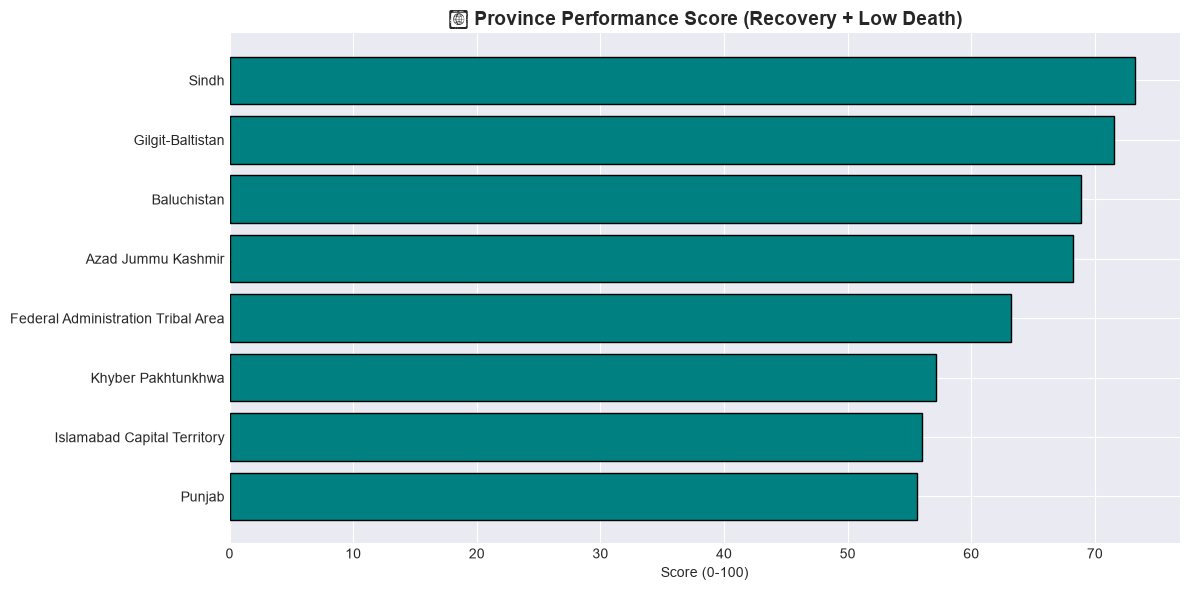

In [ ]:
# ============================================================
# DATA QUALITY REPORT
# ============================================================
print("\n" + "="*60)
print("📋 DATA QUALITY REPORT")
print("="*60)

report = pd.DataFrame({
    'Column': df.columns,
    'Non-Null': df.notna().sum().values,
    'Null': df.isna().sum().values,
    'Null %': (df.isna().sum().values / len(df) * 100).round(2),
    'Unique': df.nunique().values,
    'Dtype': df.dtypes.astype(str).values
})
print(report.to_string(index=False))
report.to_csv('data_quality_report.csv', index=False)
# ============================================================
# PROVINCE COMPARISON - Who handled COVID best?
# ============================================================
province_stats['Score'] = (
    province_stats['Recovery_%'] * 0.5 +           # Higher = better
    (100 - province_stats['Death_Rate_%']) * 0.5   # Lower death = better
)

province_stats_ranked = province_stats.sort_values('Score', ascending=False)
print("\n🏆 PROVINCE PERFORMANCE RANKING")
print("="*60)
for i, (name, row) in enumerate(province_stats_ranked.iterrows(), 1):
    print(f"{i}. {name:<40} Score: {row['Score']:.1f}")

# Visualize
plt.figure(figsize=(12, 6))
plt.barh(province_stats_ranked.index[::-1], 
         province_stats_ranked['Score'][::-1], 
         color='teal', edgecolor='black')
plt.title('🏆 Province Performance Score (Recovery + Low Death)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Score (0-100)')
plt.tight_layout()
plt.savefig('plot_16_province_performance.png', dpi=120, bbox_inches='tight')
plt.show()

🇵🇰 PAKISTAN COVID-19 COMPLETE PORTFOLIO ANALYSIS

✅ Data Loaded: 2798 rows × 7 columns
📄 File: PK COVID-19-3jun.csv

🧹 DATA CLEANING
✅ Before: (2798, 7), Missing: 36, Duplicates: 2
✅ After:  (2798, 12), Missing: 0, Duplicates: 2

📋 DATA QUALITY REPORT
        Column  Non-Null  Null  Null_%  Unique          Dtype
          Date      2798     0     0.0      91 datetime64[us]
         Cases      2798     0     0.0     218          int64
        Deaths      2798     0     0.0      29          int64
     Recovered      2798     0     0.0     123          int64
Travel_history      2798     0     0.0      15            str
      Province      2798     0     0.0       8            str
          City      2798     0     0.0     125            str
          Year      2798     0     0.0       1          int32
     Month_Num      2798     0     0.0       5          int32
         Month      2798     0     0.0       5            str
      Day_Name      2798     0     0.0       7            str
    

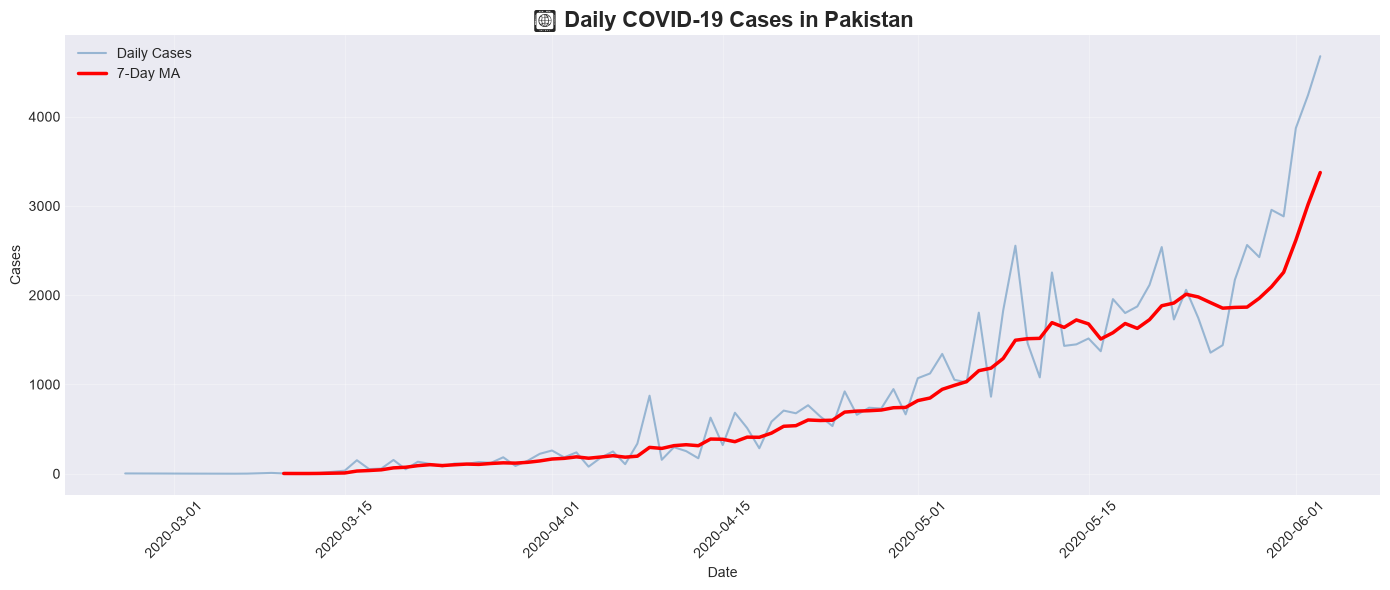

✅ 01/16: Daily Trend


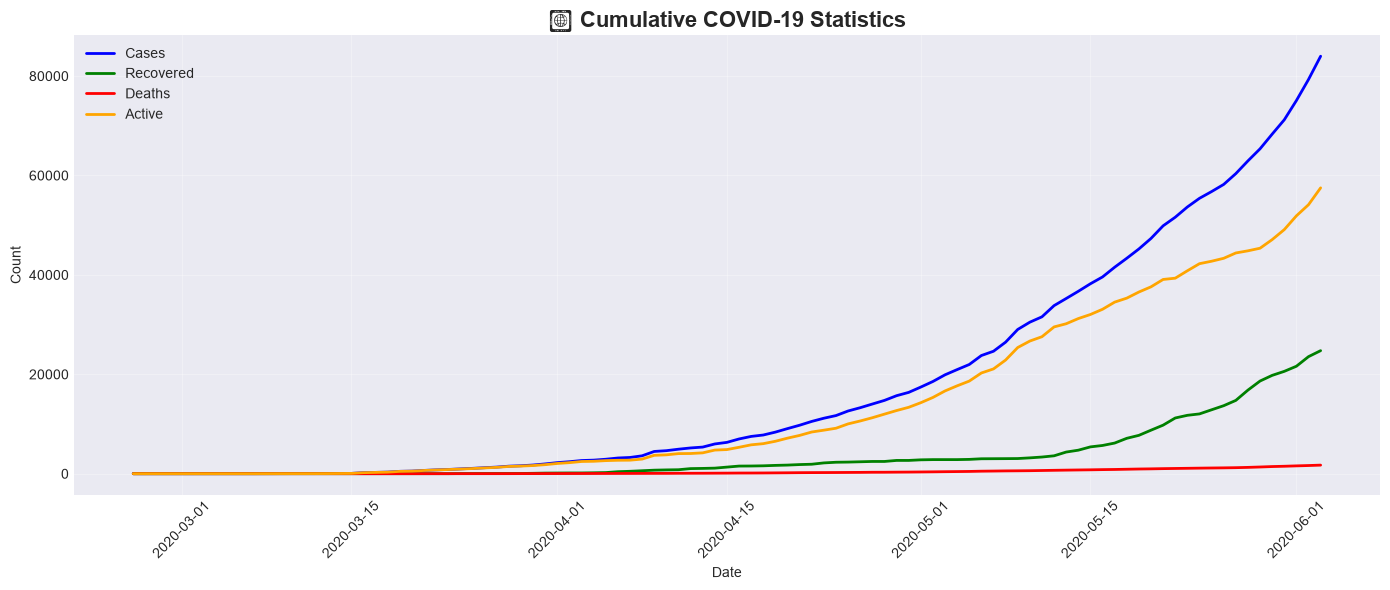

✅ 02/16: Cumulative


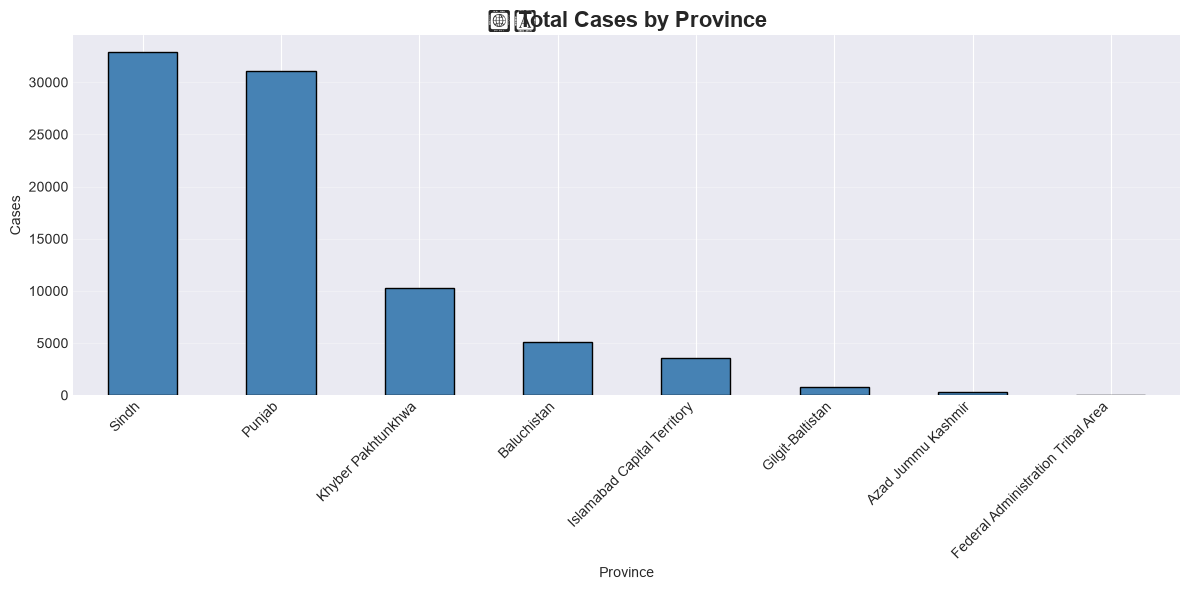

✅ 03/16: Province Bar


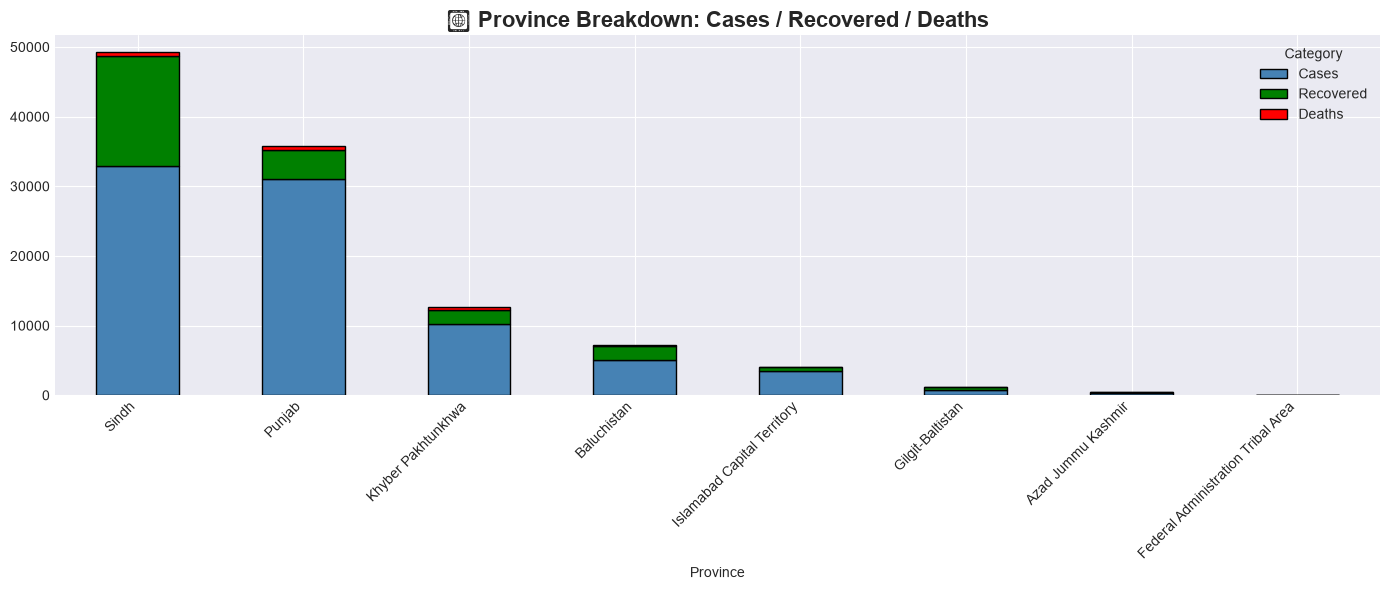

✅ 04/16: Stacked Bar


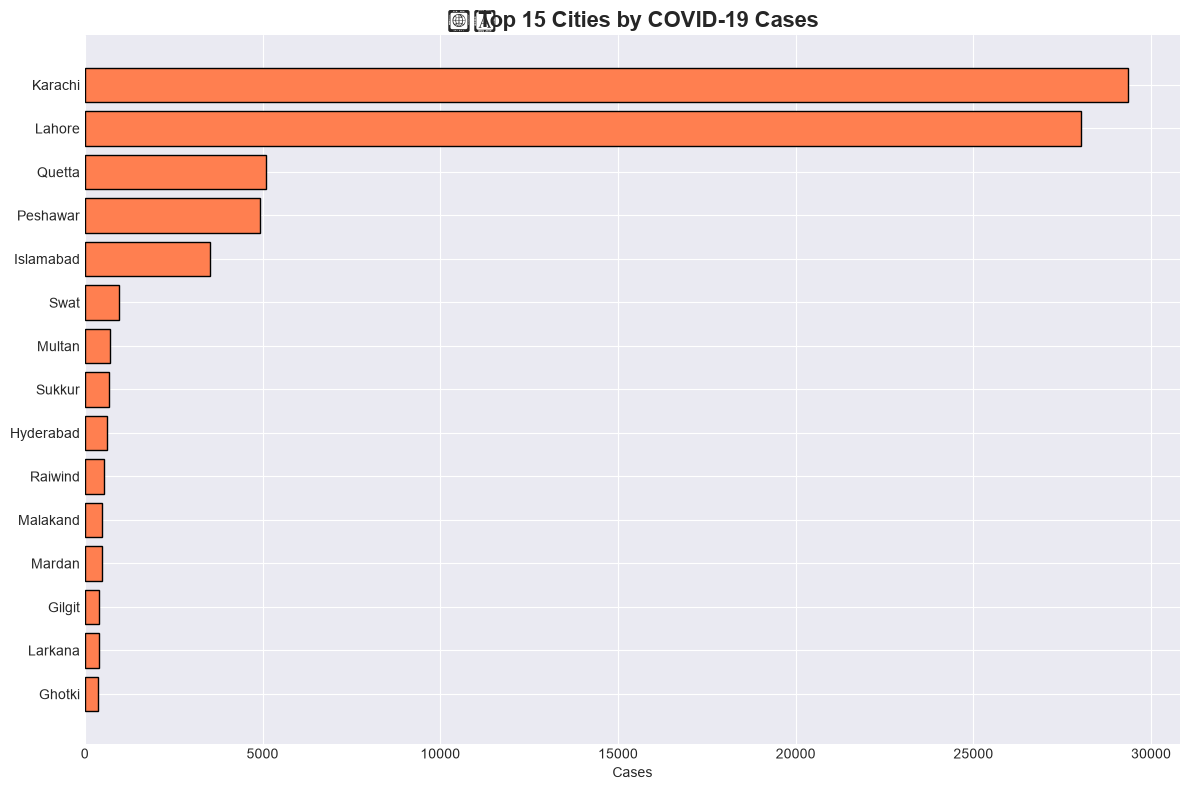

✅ 05/16: Top Cities


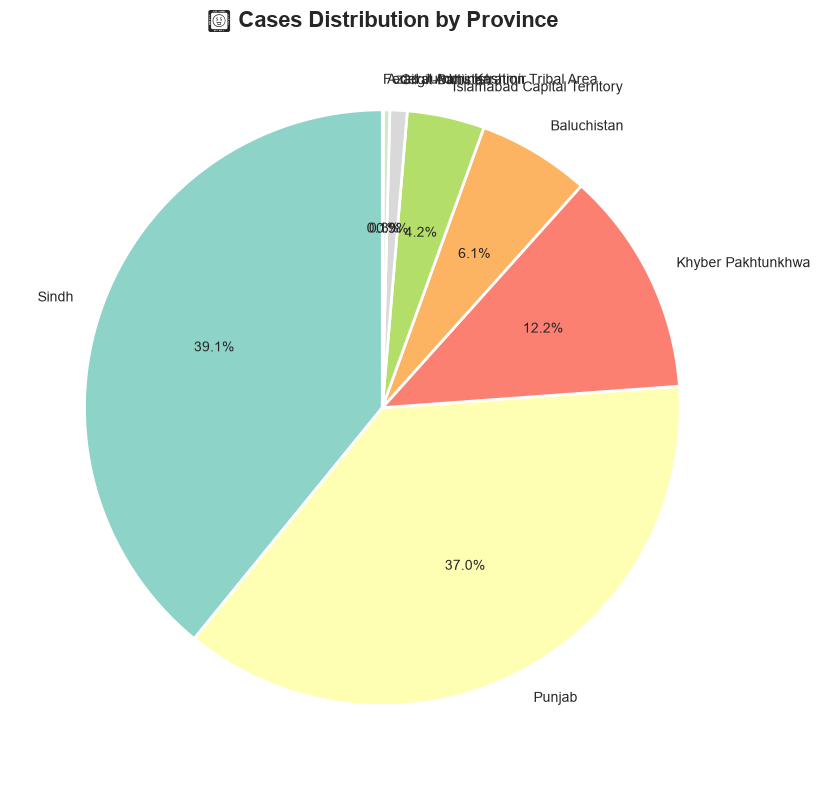

✅ 06/16: Pie Chart


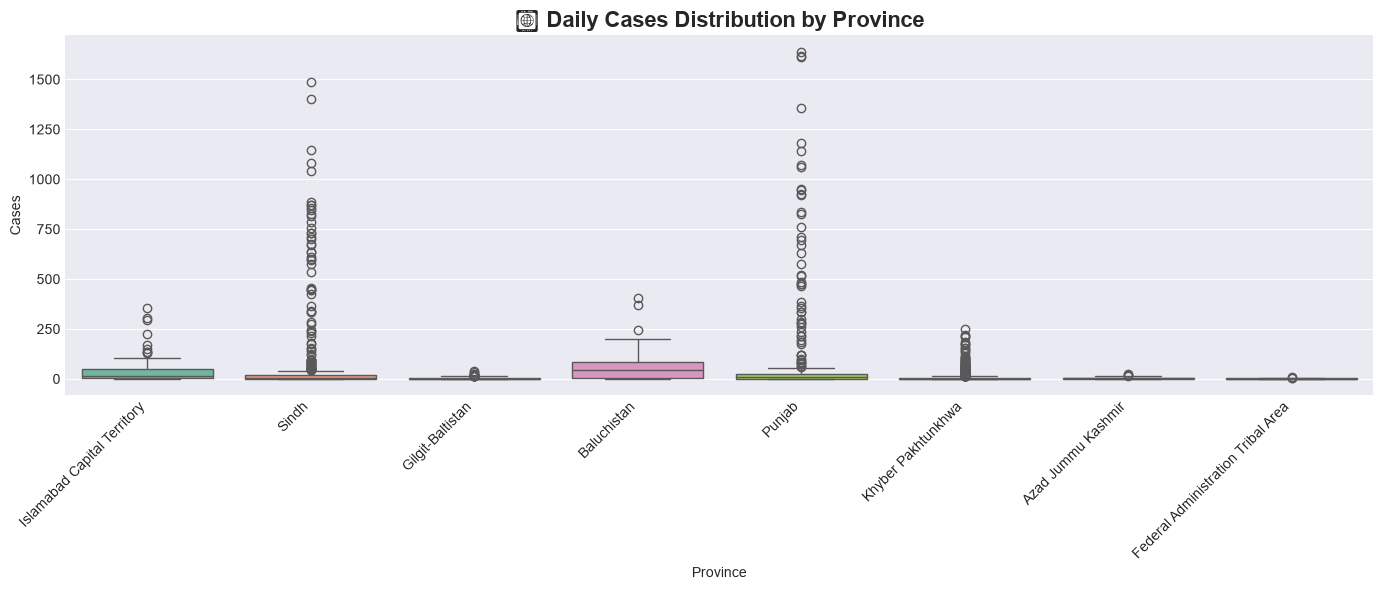

✅ 07/16: Box Plot


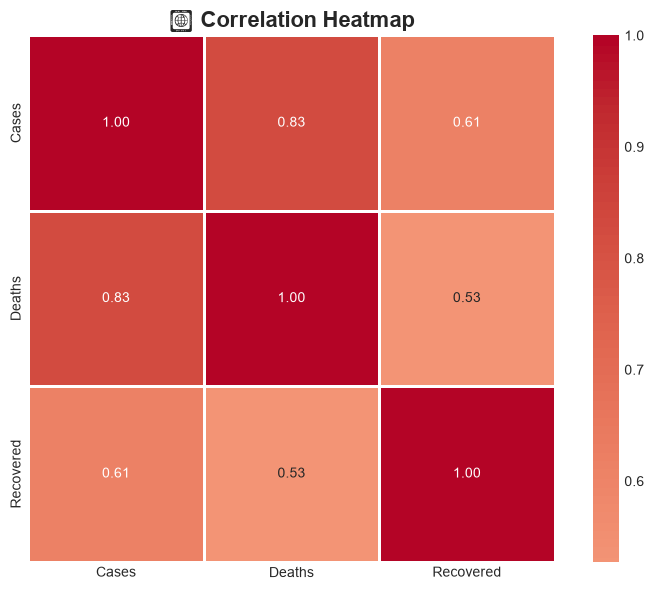

✅ 08/16: Heatmap


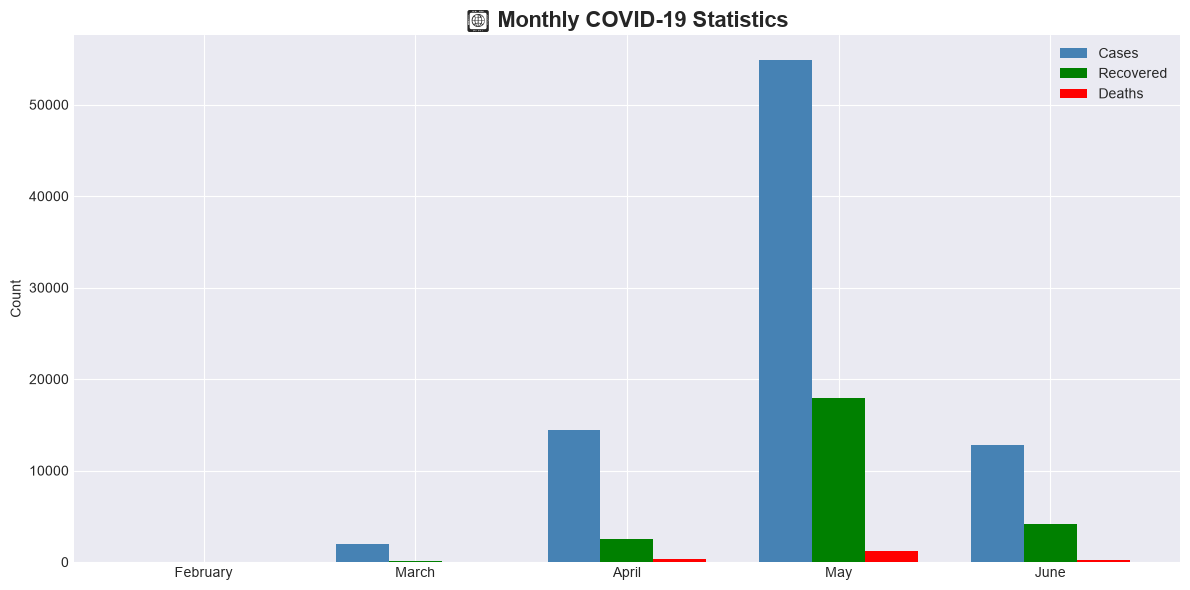

✅ 09/16: Monthly


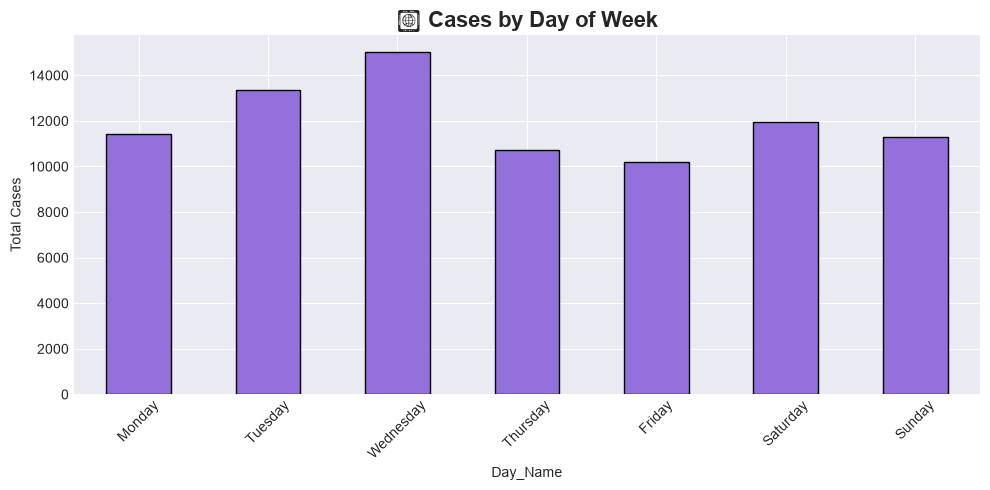

✅ 10/16: Day of Week


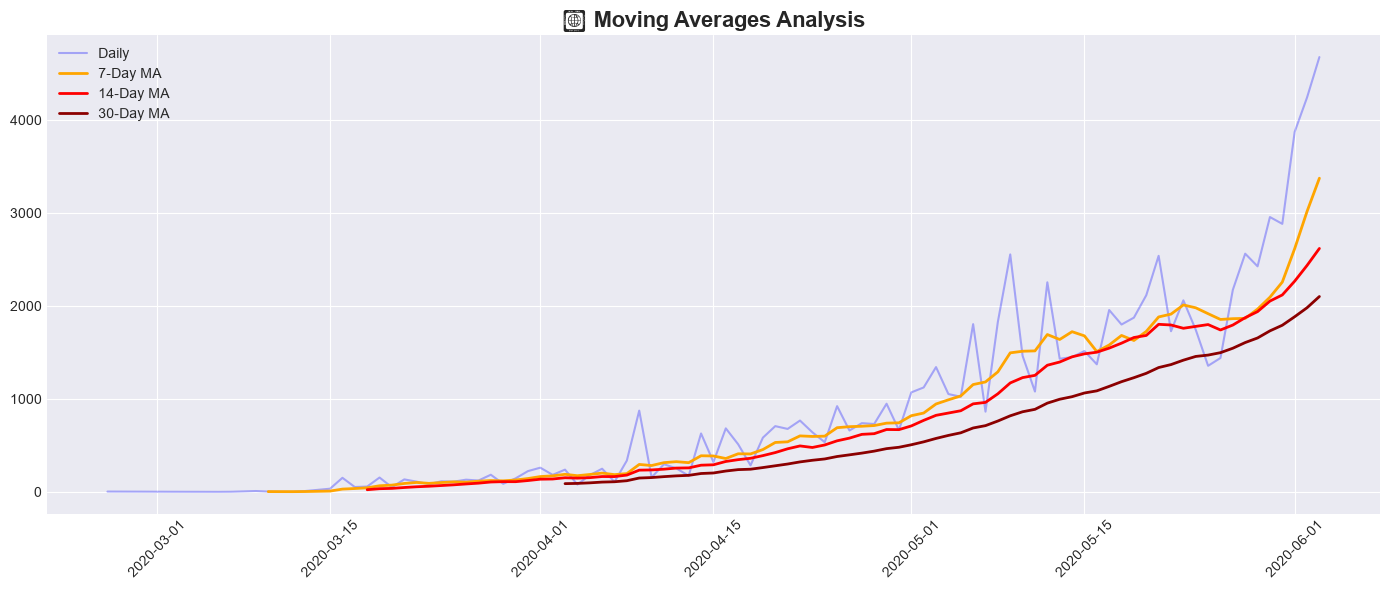

✅ 11/16: Moving Averages


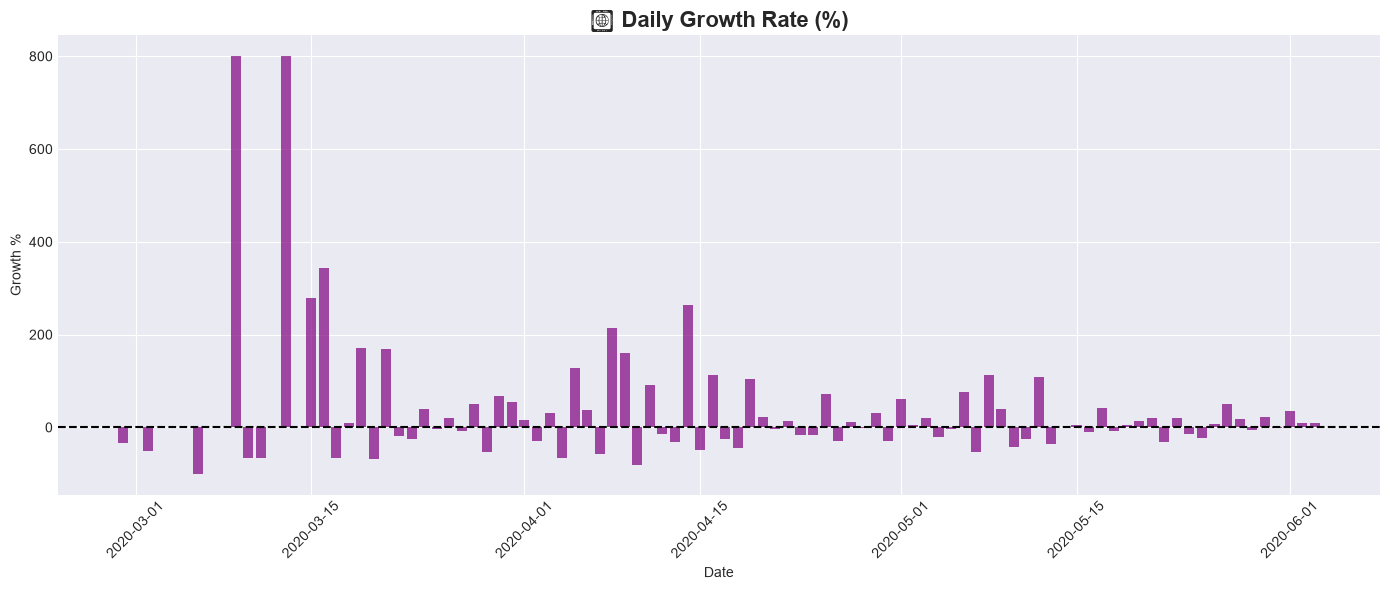

✅ 12/16: Growth Rate


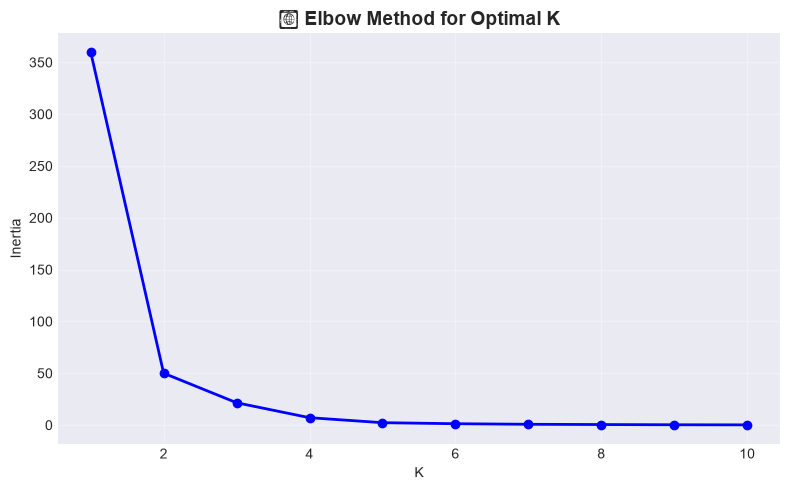

✅ 13/16: Elbow


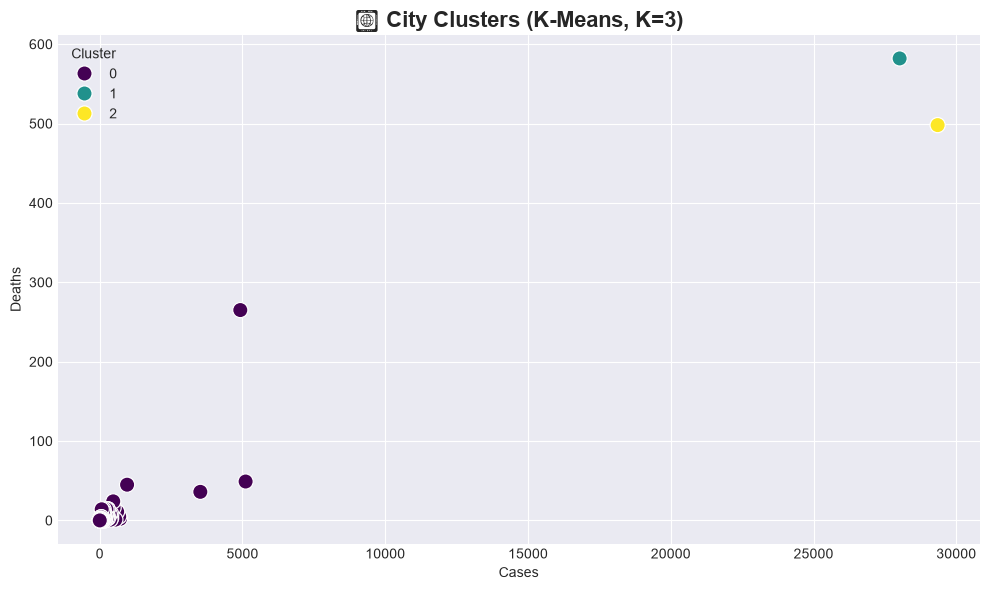

✅ 14/16: Clusters


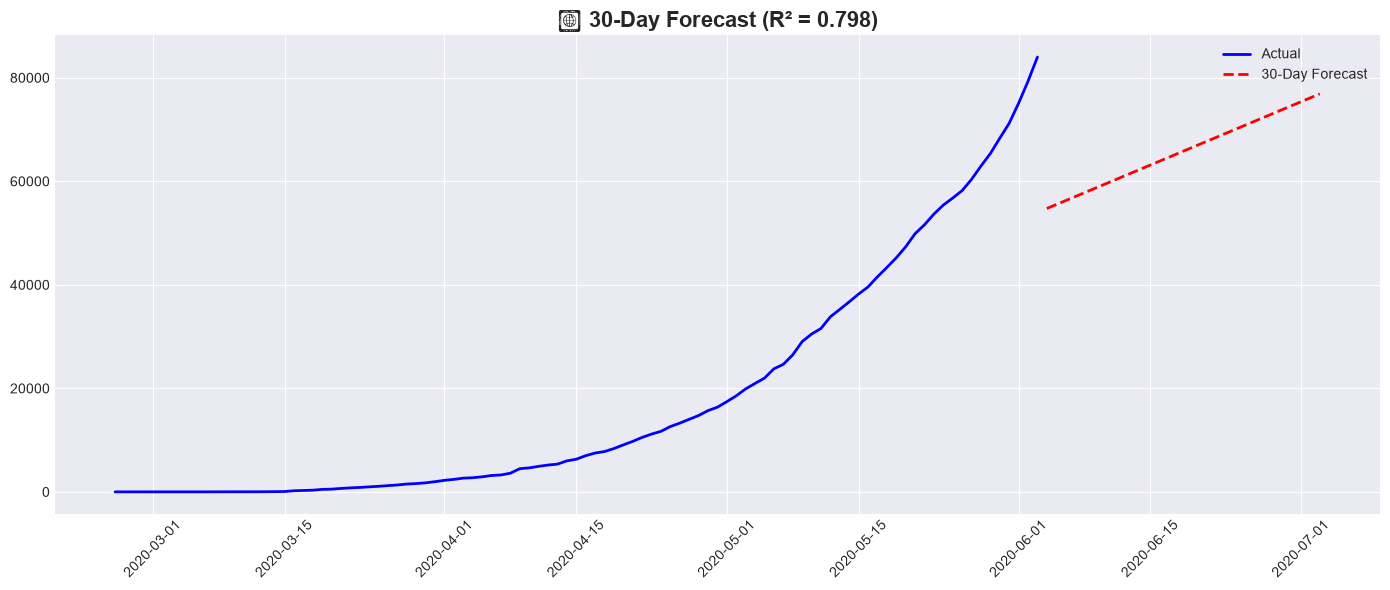

✅ 15/16: Forecast (R² = 0.798)


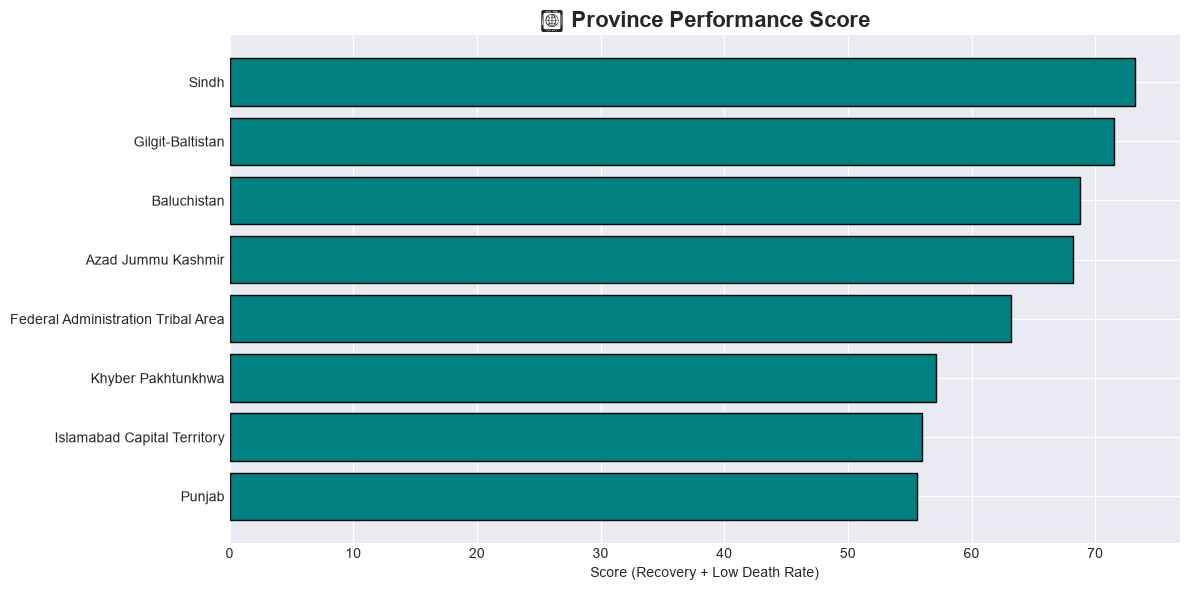

✅ 16/16: Province Performance

🎨 CREATING INTERACTIVE DASHBOARD...
✅ dashboard.html saved!

🔬 STATISTICAL TESTS
T-Test: T=-2.9218, P=0.0035
Result: ✅ Significant difference

📋 FILES GENERATED
   ✅ dashboard.html                                ( 4721.5 KB)
   ✅ outputs/city_clusters.csv                     (    3.0 KB)
   ✅ outputs/city_stats.csv                        (    2.8 KB)
   ✅ outputs/daily_summary.csv                     (   10.4 KB)
   ✅ outputs/data_quality_report.csv               (    0.4 KB)
   ✅ outputs/monthly_stats.csv                     (    0.1 KB)
   ✅ outputs/province_performance.csv              (    0.5 KB)
   ✅ outputs/province_stats.csv                    (    0.5 KB)
   ✅ outputs/travel_stats.csv                      (    0.4 KB)
   ✅ plots/01_daily_trend.png                      (   79.1 KB)
   ✅ plots/02_cumulative.png                       (   74.7 KB)
   ✅ plots/03_province_bar.png                     (   47.0 KB)
   ✅ plots/04_province_stack.png        

In [ ]:
# ============================================================
# 🇵🇰 PAKISTAN COVID-19 — COMPLETE PORTFOLIO ANALYSIS
# Author: Your Name
# Date: 2024
# ============================================================

# ============================================================
# PART 1: IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create folders
for folder in ['outputs', 'plots']:
    os.makedirs(folder, exist_ok=True)

print("="*65)
print("🇵🇰 PAKISTAN COVID-19 COMPLETE PORTFOLIO ANALYSIS")
print("="*65)

# ============================================================
# PART 2: LOAD DATA
# ============================================================
PROJECT_DIR = r'd:\DA projects\pakistan-covid-analysis'
if os.path.exists(PROJECT_DIR):
    os.chdir(PROJECT_DIR)
elif os.path.exists(r'd:\DA projects'):
    os.chdir(r'd:\DA projects')

# Try to find the CSV
csv_files = [f for f in os.listdir('.') if 'PK' in f and f.endswith('.csv')]
if csv_files:
    data_file = csv_files[0]
elif os.path.exists('data/PK COVID-19-3jun.csv'):
    data_file = 'data/PK COVID-19-3jun.csv'
else:
    data_file = 'PK COVID-19-3jun.csv'

df = pd.read_csv(data_file)
print(f"\n✅ Data Loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"📄 File: {data_file}")

# ============================================================
# PART 3: DATA CLEANING
# ============================================================
print("\n" + "="*65)
print("🧹 DATA CLEANING")
print("="*65)

# Save raw shape for report
raw_shape = df.shape
raw_missing = df.isnull().sum().sum()
raw_duplicates = df.duplicated().sum()

df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date'])
df['Province'] = df['Province'].astype(str).str.strip().str.title()
df['City'] = df['City'].astype(str).str.strip().str.title()
df['Cases'] = df['Cases'].fillna(0)
df['Deaths'] = df['Deaths'].fillna(0)
df['Recovered'] = df['Recovered'].fillna(0)
df['Travel_history'] = df['Travel_history'].fillna('Unknown')

# Date parts
df['Year'] = df['Date'].dt.year
df['Month_Num'] = df['Date'].dt.month
df['Month'] = df['Date'].dt.month_name()
df['Day_Name'] = df['Date'].dt.day_name()
df['Week'] = df['Date'].dt.isocalendar().week

print(f"✅ Before: {raw_shape}, Missing: {raw_missing}, Duplicates: {raw_duplicates}")
print(f"✅ After:  {df.shape}, Missing: {df.isnull().sum().sum()}, Duplicates: {df.duplicated().sum()}")

# ============================================================
# PART 4: DATA QUALITY REPORT
# ============================================================
print("\n" + "="*65)
print("📋 DATA QUALITY REPORT")
print("="*65)

report = pd.DataFrame({
    'Column': df.columns,
    'Non-Null': df.notna().sum().values,
    'Null': df.isna().sum().values,
    'Null_%': (df.isna().sum().values / len(df) * 100).round(2),
    'Unique': df.nunique().values,
    'Dtype': df.dtypes.astype(str).values
})
report.to_csv('outputs/data_quality_report.csv', index=False)
print(report.to_string(index=False))

# ============================================================
# PART 5: OVERALL STATISTICS
# ============================================================
print("\n" + "="*65)
print("📈 OVERALL STATISTICS")
print("="*65)

total_cases = df['Cases'].sum()
total_deaths = df['Deaths'].sum()
total_recovered = df['Recovered'].sum()
active = total_cases - total_deaths - total_recovered
death_rate = total_deaths / total_cases * 100
recovery_rate = total_recovered / total_cases * 100

print(f"Total Cases:     {total_cases:>12,.0f}")
print(f"Total Deaths:    {total_deaths:>12,.0f}")
print(f"Total Recovered: {total_recovered:>12,.0f}")
print(f"Active Cases:    {active:>12,.0f}")
print(f"Death Rate:      {death_rate:>11.2f}%")
print(f"Recovery Rate:   {recovery_rate:>11.2f}%")

# ============================================================
# PART 6: AGGREGATIONS
# ============================================================
# Daily
daily = df.groupby('Date').agg({
    'Cases': 'sum', 'Deaths': 'sum', 'Recovered': 'sum'
}).reset_index()
daily['Cumulative_Cases'] = daily['Cases'].cumsum()
daily['Cumulative_Deaths'] = daily['Deaths'].cumsum()
daily['Cumulative_Recovered'] = daily['Recovered'].cumsum()
daily['Active'] = daily['Cumulative_Cases'] - daily['Cumulative_Deaths'] - daily['Cumulative_Recovered']
daily['MA_7'] = daily['Cases'].rolling(7).mean()
daily['MA_14'] = daily['Cases'].rolling(14).mean()
daily['MA_30'] = daily['Cases'].rolling(30).mean()
daily['Growth_%'] = daily['Cases'].pct_change() * 100
daily['Doubling_Time'] = np.log(2) / np.log(1 + daily['Growth_%']/100)
daily.to_csv('outputs/daily_summary.csv', index=False)

# Province
province_stats = df.groupby('Province').agg({
    'Cases': 'sum', 'Deaths': 'sum', 'Recovered': 'sum'
}).sort_values('Cases', ascending=False)
province_stats['Active'] = province_stats['Cases'] - province_stats['Deaths'] - province_stats['Recovered']
province_stats['Death_Rate_%'] = (province_stats['Deaths'] / province_stats['Cases'] * 100).round(2)
province_stats['Recovery_%'] = (province_stats['Recovered'] / province_stats['Cases'] * 100).round(2)
province_stats['Cases_%'] = (province_stats['Cases'] / province_stats['Cases'].sum() * 100).round(2)
province_stats.to_csv('outputs/province_stats.csv')

# City
city_stats = df.groupby('City').agg({
    'Cases': 'sum', 'Deaths': 'sum', 'Recovered': 'sum'
}).sort_values('Cases', ascending=False)
city_stats['Death_Rate_%'] = (city_stats['Deaths'] / city_stats['Cases'] * 100).round(2)
city_stats.to_csv('outputs/city_stats.csv')

# Travel
travel_stats = df.groupby('Travel_history').agg({
    'Cases': 'sum', 'Deaths': 'sum', 'Recovered': 'sum'
}).sort_values('Cases', ascending=False)
travel_stats['Cases_%'] = (travel_stats['Cases'] / travel_stats['Cases'].sum() * 100).round(2)
travel_stats.to_csv('outputs/travel_stats.csv')

# Monthly
monthly = df.groupby(['Month_Num', 'Month']).agg({
    'Cases': 'sum', 'Deaths': 'sum', 'Recovered': 'sum'
}).reset_index().sort_values('Month_Num')
monthly.to_csv('outputs/monthly_stats.csv', index=False)

print("\n✅ All aggregations saved to 'outputs/' folder")

# ============================================================
# PART 7: KEY INSIGHTS (Portfolio Highlight)
# ============================================================
print("\n" + "="*65)
print("💡 KEY INSIGHTS — EXECUTIVE SUMMARY")
print("="*65)

# Peak day
worst_day = daily.loc[daily['Cases'].idxmax()]
print(f"\n1️⃣ PEAK DAY: {worst_day['Date'].date()} → {worst_day['Cases']:,.0f} cases")

# Top province
top_prov = province_stats.iloc[0]
print(f"2️⃣ TOP PROVINCE: {top_prov.name} → {top_prov['Cases']:,.0f} cases ({top_prov['Cases_%']:.1f}%)")

# Top city
top_city = city_stats.iloc[0]
city_pct = top_city['Cases'] / city_stats['Cases'].sum() * 100
print(f"3️⃣ TOP CITY: {top_city.name} → {top_city['Cases']:,.0f} cases ({city_pct:.1f}% of national)")

# Best recovery province
best_rec = province_stats.loc[province_stats['Recovery_%'].idxmax()]
print(f"4️⃣ BEST RECOVERY: {best_rec.name} → {best_rec['Recovery_%']:.1f}% recovery rate")

# Worst death rate
worst_death = province_stats.loc[province_stats['Death_Rate_%'].idxmax()]
print(f"5️⃣ HIGHEST DEATH RATE: {worst_death.name} → {worst_death['Death_Rate_%']:.2f}%")

# Local transmission
if 'Local - Social Contact' in travel_stats.index:
    local = travel_stats.loc['Local - Social Contact']
    local_pct = local['Cases_%']
    print(f"6️⃣ LOCAL TRANSMISSION: {local_pct:.1f}% of all cases (social contact)")

# Peak month
peak_month = monthly.loc[monthly['Cases'].idxmax()]
print(f"7️⃣ WORST MONTH: {peak_month['Month']} → {peak_month['Cases']:,.0f} cases")

# Growth
first_week_avg = daily['Cases'].head(7).mean()
last_week_avg = daily['Cases'].tail(7).mean()
growth_pct = (last_week_avg - first_week_avg) / first_week_avg * 100
print(f"8️⃣ GROWTH: {growth_pct:.0f}% increase (first week → last week)")

# ============================================================
# PART 8: PROVINCE PERFORMANCE RANKING
# ============================================================
province_stats['Score'] = (
    province_stats['Recovery_%'] * 0.5 +
    (100 - province_stats['Death_Rate_%']) * 0.5
).round(1)

province_ranked = province_stats.sort_values('Score', ascending=False)
print("\n" + "="*65)
print("🏆 PROVINCE PERFORMANCE RANKING")
print("="*65)
for i, (name, row) in enumerate(province_ranked.iterrows(), 1):
    print(f"{i}. {name:<38} Score: {row['Score']:.1f} | Cases: {row['Cases']:,.0f}")
province_ranked.to_csv('outputs/province_performance.csv')

# ============================================================
# PART 9: VISUALIZATIONS (16 Charts)
# ============================================================
print("\n" + "="*65)
print("📊 GENERATING 16 CHARTS...")
print("="*65)

# --- Plot 1: Daily Trend ---
plt.figure(figsize=(14, 6))
plt.plot(daily['Date'], daily['Cases'], color='steelblue', alpha=0.5, label='Daily Cases')
plt.plot(daily['Date'], daily['MA_7'], color='red', linewidth=2.5, label='7-Day MA')
plt.title('📈 Daily COVID-19 Cases in Pakistan', fontsize=16, fontweight='bold')
plt.xlabel('Date'); plt.ylabel('Cases')
plt.legend(); plt.xticks(rotation=45); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('plots/01_daily_trend.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ 01/16: Daily Trend")

# --- Plot 2: Cumulative ---
plt.figure(figsize=(14, 6))
plt.plot(daily['Date'], daily['Cumulative_Cases'], label='Cases', color='blue', linewidth=2)
plt.plot(daily['Date'], daily['Cumulative_Recovered'], label='Recovered', color='green', linewidth=2)
plt.plot(daily['Date'], daily['Cumulative_Deaths'], label='Deaths', color='red', linewidth=2)
plt.plot(daily['Date'], daily['Active'], label='Active', color='orange', linewidth=2)
plt.title('📊 Cumulative COVID-19 Statistics', fontsize=16, fontweight='bold')
plt.xlabel('Date'); plt.ylabel('Count')
plt.legend(); plt.xticks(rotation=45); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('plots/02_cumulative.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ 02/16: Cumulative")

# --- Plot 3: Province Bar ---
plt.figure(figsize=(12, 6))
province_stats['Cases'].plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('🗺️ Total Cases by Province', fontsize=16, fontweight='bold')
plt.xlabel('Province'); plt.ylabel('Cases')
plt.xticks(rotation=45, ha='right'); plt.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig('plots/03_province_bar.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ 03/16: Province Bar")

# --- Plot 4: Stacked Bar ---
fig, ax = plt.subplots(figsize=(14, 6))
province_stats[['Cases', 'Recovered', 'Deaths']].plot(
    kind='bar', stacked=True, ax=ax,
    color=['steelblue', 'green', 'red'], edgecolor='black'
)
plt.title('📊 Province Breakdown: Cases / Recovered / Deaths', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right'); plt.legend(title='Category')
plt.tight_layout(); plt.savefig('plots/04_province_stack.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ 04/16: Stacked Bar")

# --- Plot 5: Top 15 Cities ---
plt.figure(figsize=(12, 8))
top15 = city_stats.head(15)
plt.barh(top15.index[::-1], top15['Cases'][::-1], color='coral', edgecolor='black')
plt.title('🏙️ Top 15 Cities by COVID-19 Cases', fontsize=16, fontweight='bold')
plt.xlabel('Cases')
plt.tight_layout(); plt.savefig('plots/05_top_cities.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ 05/16: Top Cities")

# --- Plot 6: Pie Chart ---
plt.figure(figsize=(10, 8))
province_stats['Cases'].plot(
    kind='pie', autopct='%1.1f%%', startangle=90,
    cmap='Set3', wedgeprops={'edgecolor':'white','linewidth':2}
)
plt.title('🥧 Cases Distribution by Province', fontsize=16, fontweight='bold')
plt.ylabel('')
plt.tight_layout(); plt.savefig('plots/06_pie_province.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ 06/16: Pie Chart")

# --- Plot 7: Box Plot ---
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='Province', y='Cases', palette='Set2')
plt.title('📦 Daily Cases Distribution by Province', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.savefig('plots/07_boxplot.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ 07/16: Box Plot")

# --- Plot 8: Heatmap ---
plt.figure(figsize=(8, 6))
corr = df[['Cases', 'Deaths', 'Recovered']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=1, square=True)
plt.title('🔥 Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.savefig('plots/08_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ 08/16: Heatmap")

# --- Plot 9: Monthly ---
plt.figure(figsize=(12, 6))
x = np.arange(len(monthly)); width = 0.25
plt.bar(x - width, monthly['Cases'], width, label='Cases', color='steelblue')
plt.bar(x, monthly['Recovered'], width, label='Recovered', color='green')
plt.bar(x + width, monthly['Deaths'], width, label='Deaths', color='red')
plt.xticks(x, monthly['Month'])
plt.title('📅 Monthly COVID-19 Statistics', fontsize=16, fontweight='bold')
plt.ylabel('Count'); plt.legend()
plt.tight_layout(); plt.savefig('plots/09_monthly.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ 09/16: Monthly")

# --- Plot 10: Day of Week ---
dow = df.groupby('Day_Name')['Cases'].sum().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)
plt.figure(figsize=(10, 5))
dow.plot(kind='bar', color='mediumpurple', edgecolor='black')
plt.title('📆 Cases by Day of Week', fontsize=16, fontweight='bold')
plt.ylabel('Total Cases'); plt.xticks(rotation=45)
plt.tight_layout(); plt.savefig('plots/10_dow.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ 10/16: Day of Week")

# --- Plot 11: Moving Averages ---
plt.figure(figsize=(14, 6))
plt.plot(daily['Date'], daily['Cases'], alpha=0.3, color='blue', label='Daily')
plt.plot(daily['Date'], daily['MA_7'], color='orange', linewidth=2, label='7-Day MA')
plt.plot(daily['Date'], daily['MA_14'], color='red', linewidth=2, label='14-Day MA')
plt.plot(daily['Date'], daily['MA_30'], color='darkred', linewidth=2, label='30-Day MA')
plt.title('📉 Moving Averages Analysis', fontsize=16, fontweight='bold')
plt.legend(); plt.xticks(rotation=45)
plt.tight_layout(); plt.savefig('plots/11_moving_avg.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ 11/16: Moving Averages")

# --- Plot 12: Growth Rate ---
plt.figure(figsize=(14, 6))
plt.bar(daily['Date'], daily['Growth_%'], color='purple', alpha=0.7)
plt.axhline(0, color='black', linestyle='--')
plt.title('📊 Daily Growth Rate (%)', fontsize=16, fontweight='bold')
plt.xlabel('Date'); plt.ylabel('Growth %'); plt.xticks(rotation=45)
plt.tight_layout(); plt.savefig('plots/12_growth.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ 12/16: Growth Rate")

# --- Plot 13: Elbow ---
city_features = city_stats[city_stats['Cases'] > 0].copy()
scaler = StandardScaler()
scaled = scaler.fit_transform(city_features[['Cases', 'Deaths', 'Recovered']])

inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o', color='blue', linewidth=2)
plt.title('📐 Elbow Method for Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('K'); plt.ylabel('Inertia'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('plots/13_elbow.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ 13/16: Elbow")

# --- Plot 14: Clusters ---
km = KMeans(n_clusters=3, random_state=42, n_init=10)
city_features['Cluster'] = km.fit_predict(scaled)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=city_features, x='Cases', y='Deaths',
                hue='Cluster', palette='viridis', s=120)
plt.title('🎯 City Clusters (K-Means, K=3)', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.savefig('plots/14_clusters.png', dpi=120, bbox_inches='tight')
plt.show()
city_features.to_csv('outputs/city_clusters.csv')
print("✅ 14/16: Clusters")

# --- Plot 15: Forecast ---
daily['Days'] = (daily['Date'] - daily['Date'].min()).dt.days
X = daily[['Days']].values
y = daily['Cumulative_Cases'].values
model = LinearRegression().fit(X, y)
r2 = model.score(X, y)

future_days = np.arange(X.max()+1, X.max()+31).reshape(-1, 1)
pred = model.predict(future_days)
future_dates = pd.date_range(daily['Date'].max() + pd.Timedelta(days=1), periods=30)

plt.figure(figsize=(14, 6))
plt.plot(daily['Date'], daily['Cumulative_Cases'], label='Actual', color='blue', linewidth=2)
plt.plot(future_dates, pred, label='30-Day Forecast', color='red', linestyle='--', linewidth=2)
plt.title(f'🔮 30-Day Forecast (R² = {r2:.3f})', fontsize=16, fontweight='bold')
plt.legend(); plt.xticks(rotation=45)
plt.tight_layout(); plt.savefig('plots/15_forecast.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"✅ 15/16: Forecast (R² = {r2:.3f})")

# --- Plot 16: Province Performance ---
plt.figure(figsize=(12, 6))
plt.barh(province_ranked.index[::-1], province_ranked['Score'][::-1],
         color='teal', edgecolor='black')
plt.title('🏆 Province Performance Score', fontsize=16, fontweight='bold')
plt.xlabel('Score (Recovery + Low Death Rate)')
plt.tight_layout(); plt.savefig('plots/16_province_performance.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ 16/16: Province Performance")

# ============================================================
# PART 10: INTERACTIVE DASHBOARD (Plotly)
# ============================================================
print("\n" + "="*65)
print("🎨 CREATING INTERACTIVE DASHBOARD...")
print("="*65)

try:
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots

    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=('Daily Cases Trend', 'Cumulative Cases',
                        'Province-wise Cases', 'Top 10 Cities'),
        specs=[[{'type':'scatter'}, {'type':'scatter'}],
               [{'type':'bar'}, {'type':'bar'}]]
    )

    fig.add_trace(go.Scatter(x=daily['Date'], y=daily['Cases'],
                             mode='lines', name='Daily',
                             line=dict(color='steelblue', width=2)), row=1, col=1)
    fig.add_trace(go.Scatter(x=daily['Date'], y=daily['Cumulative_Cases'],
                             mode='lines', name='Cumulative',
                             line=dict(color='red', width=2)), row=1, col=2)
    fig.add_trace(go.Bar(x=province_stats.index, y=province_stats['Cases'],
                         name='Province', marker_color='coral'), row=2, col=1)

    top10 = city_stats.head(10)
    fig.add_trace(go.Bar(x=top10['Cases'], y=top10.index,
                         orientation='h', name='Top Cities',
                         marker_color='green'), row=2, col=2)

    fig.update_layout(height=700, showlegend=False,
                      title_text="🇵🇰 Pakistan COVID-19 Interactive Dashboard",
                      title_font_size=20)
    fig.write_html('dashboard.html')
    print("✅ dashboard.html saved!")
except ImportError:
    print("⚠️ Plotly not installed. Run: pip install plotly")

# ============================================================
# PART 11: STATISTICAL TESTS
# ============================================================
print("\n" + "="*65)
print("🔬 STATISTICAL TESTS")
print("="*65)

before = df[df['Date'] < '2020-04-01']['Cases']
after = df[df['Date'] >= '2020-04-01']['Cases']
t, p = stats.ttest_ind(before, after)
print(f"T-Test: T={t:.4f}, P={p:.4f}")
print(f"Result: {'✅ Significant difference' if p < 0.05 else '❌ No difference'}")

# ============================================================
# PART 12: FINAL SUMMARY
# ============================================================
print("\n" + "="*65)
print("📋 FILES GENERATED")
print("="*65)

all_files = []
for folder in ['outputs', 'plots']:
    if os.path.exists(folder):
        for f in os.listdir(folder):
            all_files.append(f"{folder}/{f}")
if os.path.exists('dashboard.html'):
    all_files.append('dashboard.html')

for f in sorted(all_files):
    size = os.path.getsize(f) / 1024
    print(f"   ✅ {f:<45} ({size:>7.1f} KB)")

print("\n" + "="*65)
print("🎉 ANALYSIS COMPLETE!")
print("="*65)
print(f"📊 Records: {len(df):,}")
print(f"📅 Period: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"🗺️  Provinces: {df['Province'].nunique()}")
print(f"🏙️  Cities: {df['City'].nunique()}")
print(f"📈 Total Cases: {total_cases:,.0f}")
print(f"📁 Files Generated: {len(all_files)}")
print("="*65)
print("\n🚀 Ready for portfolio! Check 'outputs/' and 'plots/' folders.")

In [ ]:
# ==========================================
# CELL 2: Load the Cleaned Dataset
# ==========================================

import pandas as pd
import numpy as np

# Cleaned file load karein
df = pd.read_csv('PK_COVID_19_cleaned.csv')

# Basic info check karein
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
display(df.head())
print(f"\nData Types:")
print(df.dtypes)
print(f"\nMissing Values:")
print(df.isnull().sum())

DATASET OVERVIEW
Shape: (2798, 7)

Columns: ['Date', 'Cases', 'Deaths', 'Recovered', 'Travel_history', 'Province', 'City']

First 5 rows:


,Date,Cases,Deaths,Recovered,Travel_history,Province,City
0,2020-02-26,1,0,0,China,Islamabad Capital Territory,Islamabad
1,2020-02-26,2,0,0,Iran/Taftan,Sindh,Karachi
2,2020-02-29,1,0,0,China,Islamabad Capital Territory,Islamabad
3,2020-02-29,1,0,0,Iran/Taftan,Sindh,Karachi
4,2020-03-02,1,0,0,Iran/Taftan,Gilgit-Baltistan,Gilgit



Data Types:
Date                str
Cases             int64
Deaths            int64
Recovered         int64
Travel_history      str
Province            str
City                str
dtype: object

Missing Values:
Date              0
Cases             0
Deaths            0
Recovered         0
Travel_history    0
Province          0
City              0
dtype: int64


In [ ]:
# ==========================================
# CELL 3: Date ko datetime mein convert karein
# ==========================================

df['Date'] = pd.to_datetime(df['Date'])

print("Date column converted to datetime!")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Data type: {df['Date'].dtype}")
# ==========================================
# CELL 4: BASIC DESCRIPTIVE STATISTICS
# ==========================================

print("=" * 70)
print("DESCRIPTIVE STATISTICS — .describe()")
print("=" * 70)
print(df[['Cases', 'Deaths', 'Recovered']].describe())

Date column converted to datetime!
Date range: 2020-02-26 00:00:00 to 2020-06-03 00:00:00
Data type: datetime64[us]
DESCRIPTIVE STATISTICS — .describe()
             Cases       Deaths    Recovered
count  2798.000000  2798.000000  2798.000000
mean     30.016440     0.617584     8.847034
std     128.861666     2.716284    61.362566
min       0.000000     0.000000    -2.000000
25%       0.000000     0.000000     0.000000
50%       2.000000     0.000000     0.000000
75%       9.000000     0.000000     1.000000
max    1639.000000    43.000000  1431.000000


In [ ]:
# ==========================================
# CELL 5: DETAILED STATISTICS (Mean, Variance, Std Dev)
# ==========================================

def full_stats(series, name):
    """Har column ke liye mukammal statistics"""
    return {
        'Column': name,
        'Count': series.count(),
        'Mean': series.mean(),
        'Median': series.median(),
        'Mode': series.mode()[0] if not series.mode().empty else np.nan,
        'Variance (Sample)': series.var(),
        'Variance (Population)': series.var(ddof=0),
        'Std Dev (Sample)': series.std(),
        'Std Dev (Population)': series.std(ddof=0),
        'Minimum': series.min(),
        'Maximum': series.max(),
        'Range': series.max() - series.min(),
        'Q1 (25%)': series.quantile(0.25),
        'Q2 (50%)': series.quantile(0.50),
        'Q3 (75%)': series.quantile(0.75),
        'IQR': series.quantile(0.75) - series.quantile(0.25),
        'Skewness': series.skew(),
        'Kurtosis': series.kurt(),
        'Sum': series.sum(),
        'CV (%)': (series.std() / series.mean() * 100) if series.mean() != 0 else np.nan
    }

# Table banayein
stats_table = pd.DataFrame([
    full_stats(df['Cases'], 'Cases'),
    full_stats(df['Deaths'], 'Deaths'),
    full_stats(df['Recovered'], 'Recovered')
])

# Transpose karke columns ke saath dikhayein
stats_table_T = stats_table.set_index('Column').T
print("=" * 70)
print("FULL DESCRIPTIVE STATISTICS (Mean, Variance, Std Dev)")
print("=" * 70)
print(stats_table_T.round(4))

NameError: name 'pd' is not defined

In [ ]:
# ==========================================
# CELL 6: Standard Error & Confidence Interval
# ==========================================

from scipy import stats

for col in ['Cases', 'Deaths', 'Recovered']:
    series = df[col].dropna()
    se = stats.sem(series)  # Standard Error of Mean
    ci = stats.t.interval(0.95, len(series)-1, loc=series.mean(), scale=se)
    
    print(f"\n--- {col} ---")
    print(f"Mean: {series.mean():.4f}")
    print(f"Standard Error: {se:.4f}")
    print(f"95% Confidence Interval: ({ci[0]:.4f}, {ci[1]:.4f})")

NameError: name 'df' is not defined

In [ ]:
# ==========================================
# CELL 7: Province-wise Statistics
# ==========================================

print("=" * 70)
print("PROVINCE-WISE STATISTICS")
print("=" * 70)

province_stats = df.groupby('Province')['Cases'].agg([
    'count', 'mean', 'median', 'std', 'var', 'min', 'max', 'sum'
]).round(2)

print(province_stats)
# ==========================================
# CELL 8: Custom Province-wise Stats (CFR, Recovery Rate)
# ==========================================

custom_stats = df.groupby('Province').agg(
    total_cases=('Cases', 'sum'),
    mean_cases=('Cases', 'mean'),
    std_cases=('Cases', 'std'),
    total_deaths=('Deaths', 'sum'),
    total_recovered=('Recovered', 'sum')
).round(2)

# CFR (Case Fatality Rate) aur Recovery Rate add karein
custom_stats['CFR_%'] = (custom_stats['total_deaths'] / custom_stats['total_cases'] * 100).round(2)
custom_stats['Recovery_%'] = (custom_stats['total_recovered'] / custom_stats['total_cases'] * 100).round(2)

# Sort karein total_cases ke hisaab se
custom_stats = custom_stats.sort_values('total_cases', ascending=False)

print("=" * 70)
print("PROVINCE-WISE: Cases, Deaths, CFR, Recovery Rate")
print("=" * 70)
print(custom_stats)

PROVINCE-WISE STATISTICS
                                    count   mean  median     std       var  \
Province                                                                     
Azad Jummu Kashmir                     54   5.28     3.0    5.60     31.41   
Baluchistan                            83  61.75    44.0   75.68   5727.14   
Federal Administration Tribal Area     36   1.47     1.0    1.73      3.00   
Gilgit-Baltistan                      190   4.14     1.5    5.98     35.72   
Islamabad Capital Territory            74  47.61    16.0   72.50   5256.46   
Khyber Pakhtunkhwa                   1491   6.88     1.0   20.86    435.23   
Punjab                                341  91.19     7.0  256.53  65806.12   
Sindh                                 529  62.11     4.0  192.89  37207.26   

                                    min   max    sum  
Province                                              
Azad Jummu Kashmir                    0    26    285  
Baluchistan                  

In [ ]:
# ==========================================
# CELL 9: Travel History-wise Statistics
# ==========================================

travel_stats = df.groupby('Travel_history')['Cases'].agg([
    'count', 'mean', 'std', 'sum'
]).sort_values('sum', ascending=False).round(2)

print("=" * 70)
print("TRAVEL HISTORY-WISE STATISTICS")
print("=" * 70)
print(travel_stats)

TRAVEL HISTORY-WISE STATISTICS
                         count    mean     std    sum
Travel_history                                       
Local - Social Contact    2499   23.58  106.44  58919
Unknown                    159  142.51  316.04  22659
Tableeghi Jamaat            23   48.48   86.11   1115
Iran/Taftan                 88   11.97   18.32   1053
Jail                         5   21.40   31.26    107
Afghanistan                  5   14.00   17.62     70
International Passenger      5    7.60    5.32     38
Syria                        2    3.50    3.54      7
KSA                          2    3.00    2.83      6
UK                           3    1.67    1.15      5
China                        2    1.00    0.00      2
India                        1    2.00     NaN      2
Dubai                        2    0.50    0.71      1
Local - Covid Relative       1    1.00     NaN      1
USA                          1    1.00     NaN      1


In [ ]:
# ==========================================
# CELL 10: Pivot Table (Province × Travel History)
# ==========================================

pivot = df.pivot_table(
    values='Cases',
    index='Province',
    columns='Travel_history',
    aggfunc='sum',
    fill_value=0
)

print("=" * 70)
print("PIVOT TABLE: Province vs Travel History (Cases Sum)")
print("=" * 70)
print(pivot)

PIVOT TABLE: Province vs Travel History (Cases Sum)
Travel_history                      Afghanistan  China  Dubai  India  \
Province                                                               
Azad Jummu Kashmir                            0      0      0      0   
Baluchistan                                   0      0      0      0   
Federal Administration Tribal Area            0      0      0      0   
Gilgit-Baltistan                              0      0      1      0   
Islamabad Capital Territory                   0      2      0      0   
Khyber Pakhtunkhwa                           70      0      0      0   
Punjab                                        0      0      0      2   
Sindh                                         0      0      0      0   

Travel_history                      International Passenger  Iran/Taftan  \
Province                                                                   
Azad Jummu Kashmir                                        0            1   

In [ ]:
# ==========================================
# CELL 11: Pivot Table (Readable Version)
# ==========================================

# Display settings temporarily badlein
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 300)
pd.set_option('display.max_rows', 100)

pivot = df.pivot_table(
    values='Cases',
    index='Province',
    columns='Travel_history',
    aggfunc='sum',
    fill_value=0
)

print("=" * 70)
print("PIVOT TABLE: Province vs Travel History (Cases Sum)")
print("=" * 70)
print(pivot)

# Reset settings
pd.reset_option('display.max_columns')
pd.reset_option('display.width')

PIVOT TABLE: Province vs Travel History (Cases Sum)
Travel_history                      Afghanistan  China  Dubai  India  International Passenger  Iran/Taftan  Jail  KSA  Local - Covid Relative  Local - Social Contact  Syria  Tableeghi Jamaat  UK  USA  Unknown
Province                                                                                                                                                                                                        
Azad Jummu Kashmir                            0      0      0      0                        0            1     0    0                       0                     270      0                 0   0    0       14
Baluchistan                                   0      0      0      0                        0          118     0    0                       0                    2003      0                 0   0    0     3004
Federal Administration Tribal Area            0      0      0      0                        0            2     0

In [ ]:
# ==========================================
# CELL 12: Pivot Table (Transposed — Readable)
# ==========================================

pivot = df.pivot_table(
    values='Cases',
    index='Province',
    columns='Travel_history',
    aggfunc='sum',
    fill_value=0
)

# Transpose karein
print("=" * 70)
print("PIVOT TABLE (Transposed): Travel History × Province")
print("=" * 70)
print(pivot.T)

PIVOT TABLE (Transposed): Travel History × Province
Province                 Azad Jummu Kashmir  Baluchistan  \
Travel_history                                             
Afghanistan                               0            0   
China                                     0            0   
Dubai                                     0            0   
India                                     0            0   
International Passenger                   0            0   
Iran/Taftan                               1          118   
Jail                                      0            0   
KSA                                       0            0   
Local - Covid Relative                    0            0   
Local - Social Contact                  270         2003   
Syria                                     0            0   
Tableeghi Jamaat                          0            0   
UK                                        0            0   
USA                                       0     

In [ ]:
# ==========================================
# CELL 13: CORRELATION ANALYSIS
# ==========================================

# 13.1: Pearson Correlation Matrix
print("=" * 70)
print("PEARSON CORRELATION MATRIX")
print("=" * 70)

corr_matrix = df[['Cases', 'Deaths', 'Recovered']].corr()
print(corr_matrix.round(4))

# 13.2: Spearman Correlation
print("\n" + "=" * 70)
print("SPEARMAN CORRELATION MATRIX")
print("=" * 70)
spearman_corr = df[['Cases', 'Deaths', 'Recovered']].corr(method='spearman')
print(spearman_corr.round(4))

# 13.3: Covariance Matrix
print("\n" + "=" * 70)
print("COVARIANCE MATRIX")
print("=" * 70)
print(df[['Cases', 'Deaths', 'Recovered']].cov().round(4))

PEARSON CORRELATION MATRIX
            Cases  Deaths  Recovered
Cases      1.0000  0.8255     0.6148
Deaths     0.8255  1.0000     0.5276
Recovered  0.6148  0.5276     1.0000

SPEARMAN CORRELATION MATRIX
            Cases  Deaths  Recovered
Cases      1.0000  0.4027     0.2132
Deaths     0.4027  1.0000     0.2610
Recovered  0.2132  0.2610     1.0000

COVARIANCE MATRIX
                Cases    Deaths  Recovered
Cases      16605.3290  288.9459  4861.0815
Deaths       288.9459    7.3782    87.9433
Recovered   4861.0815   87.9433  3765.3645


In [ ]:
# ==========================================
# CELL 14: Correlation with P-values
# ==========================================

from scipy.stats import pearsonr

print("=" * 70)
print("CORRELATION WITH P-VALUES")
print("=" * 70)

pairs = [('Cases', 'Deaths'), ('Cases', 'Recovered'), ('Deaths', 'Recovered')]

for col1, col2 in pairs:
    r, p = pearsonr(df[col1], df[col2])
    significance = "✅ Significant (p < 0.05)" if p < 0.05 else "❌ Not Significant"
    strength = "Strong" if abs(r) > 0.7 else "Moderate" if abs(r) > 0.4 else "Weak"
    
    print(f"\n{col1} vs {col2}:")
    print(f"  Pearson r = {r:.4f}")
    print(f"  P-value   = {p:.4e}")
    print(f"  Strength  = {strength}")
    print(f"  {significance}"
        )

CORRELATION WITH P-VALUES

Cases vs Deaths:
  Pearson r = 0.8255
  P-value   = 0.0000e+00
  Strength  = Strong
  ✅ Significant (p < 0.05)

Cases vs Recovered:
  Pearson r = 0.6148
  P-value   = 1.5032e-290
  Strength  = Moderate
  ✅ Significant (p < 0.05)

Deaths vs Recovered:
  Pearson r = 0.5276
  P-value   = 2.3222e-200
  Strength  = Moderate
  ✅ Significant (p < 0.05)


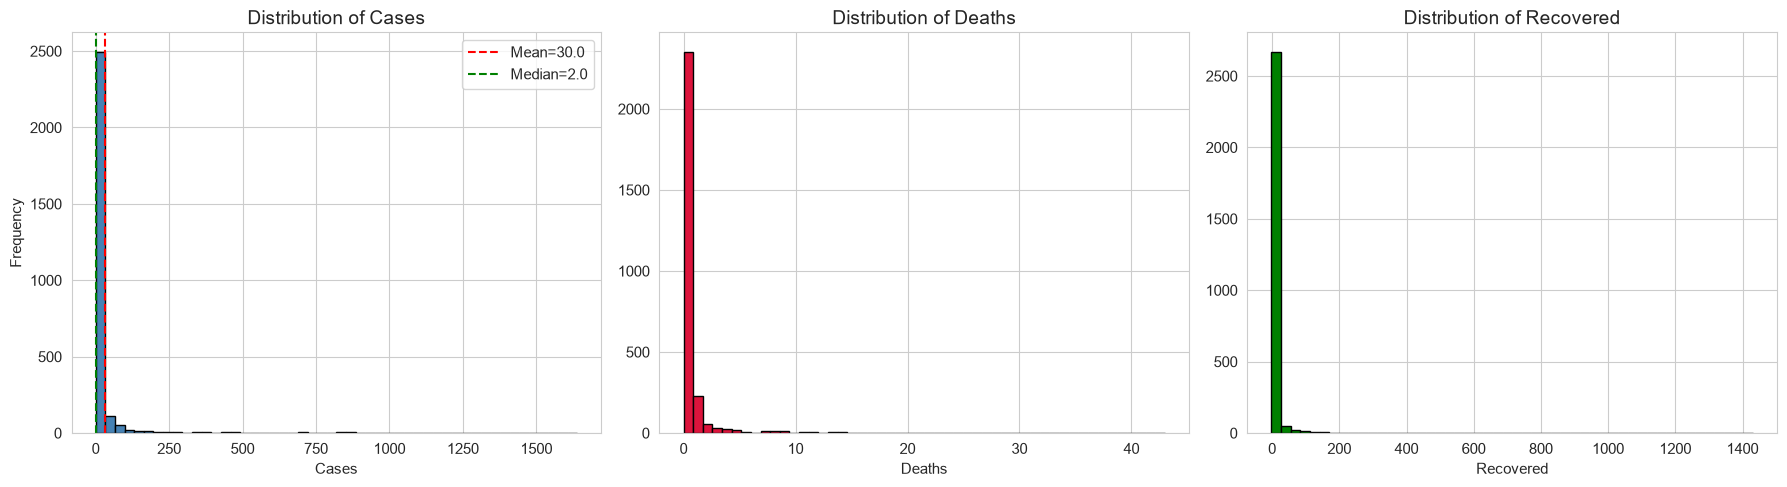

✅ Saved: 01_histograms.png


In [ ]:
# ==========================================
# CELL 15: HISTOGRAMS
# ==========================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Cases
axes[0].hist(df['Cases'], bins=50, color='steelblue', edgecolor='black')
axes[0].axvline(df['Cases'].mean(), color='red', linestyle='--', 
                label=f'Mean={df["Cases"].mean():.1f}')
axes[0].axvline(df['Cases'].median(), color='green', linestyle='--', 
                label=f'Median={df["Cases"].median():.1f}')
axes[0].set_title('Distribution of Cases', fontsize=14)
axes[0].set_xlabel('Cases')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Deaths
axes[1].hist(df['Deaths'], bins=50, color='crimson', edgecolor='black')
axes[1].set_title('Distribution of Deaths', fontsize=14)
axes[1].set_xlabel('Deaths')

# Recovered
axes[2].hist(df['Recovered'], bins=50, color='green', edgecolor='black')
axes[2].set_title('Distribution of Recovered', fontsize=14)
axes[2].set_xlabel('Recovered')

plt.tight_layout()
plt.savefig('01_histograms.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: 01_histograms.png")

In [ ]:
# ==========================================
# SETUP CELL (Har kernel restart ke baad chalayein)
# ==========================================

# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Data load karein
df = pd.read_csv('PK_COVID_19_cleaned.csv')
df['Date'] = pd.to_datetime(df['Date'])

print("✅ Setup complete!")
print(f"   Data shape: {df.shape}")
print(f"   Date range: {df['Date'].min()} to {df['Date'].max()}")

✅ Setup complete!
   Data shape: (2798, 7)
   Date range: 2020-02-26 00:00:00 to 2020-06-03 00:00:00


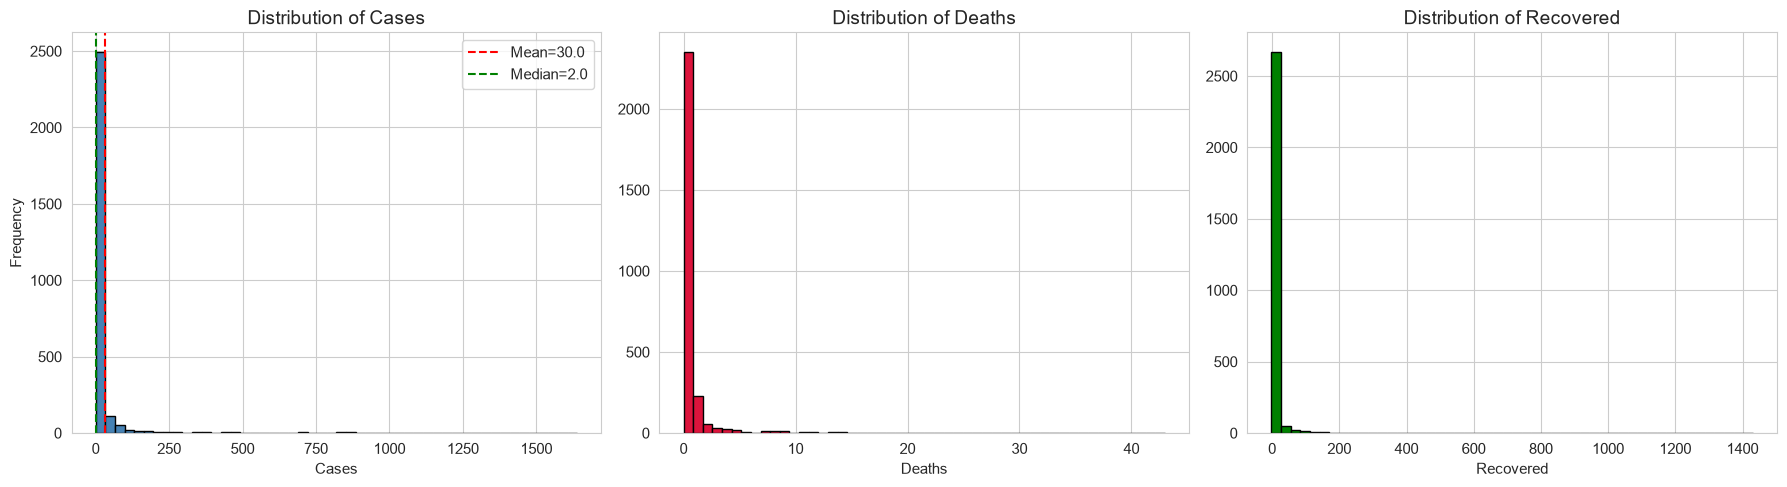

✅ Saved: 01_histograms.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['Cases'], bins=50, color='steelblue', edgecolor='black')
axes[0].axvline(df['Cases'].mean(), color='red', linestyle='--', 
                label=f'Mean={df["Cases"].mean():.1f}')
axes[0].axvline(df['Cases'].median(), color='green', linestyle='--', 
                label=f'Median={df["Cases"].median():.1f}')
axes[0].set_title('Distribution of Cases', fontsize=14)
axes[0].set_xlabel('Cases')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(df['Deaths'], bins=50, color='crimson', edgecolor='black')
axes[1].set_title('Distribution of Deaths', fontsize=14)
axes[1].set_xlabel('Deaths')

axes[2].hist(df['Recovered'], bins=50, color='green', edgecolor='black')
axes[2].set_title('Distribution of Recovered', fontsize=14)
axes[2].set_xlabel('Recovered')

plt.tight_layout()
plt.savefig('01_histograms.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: 01_histograms.png")

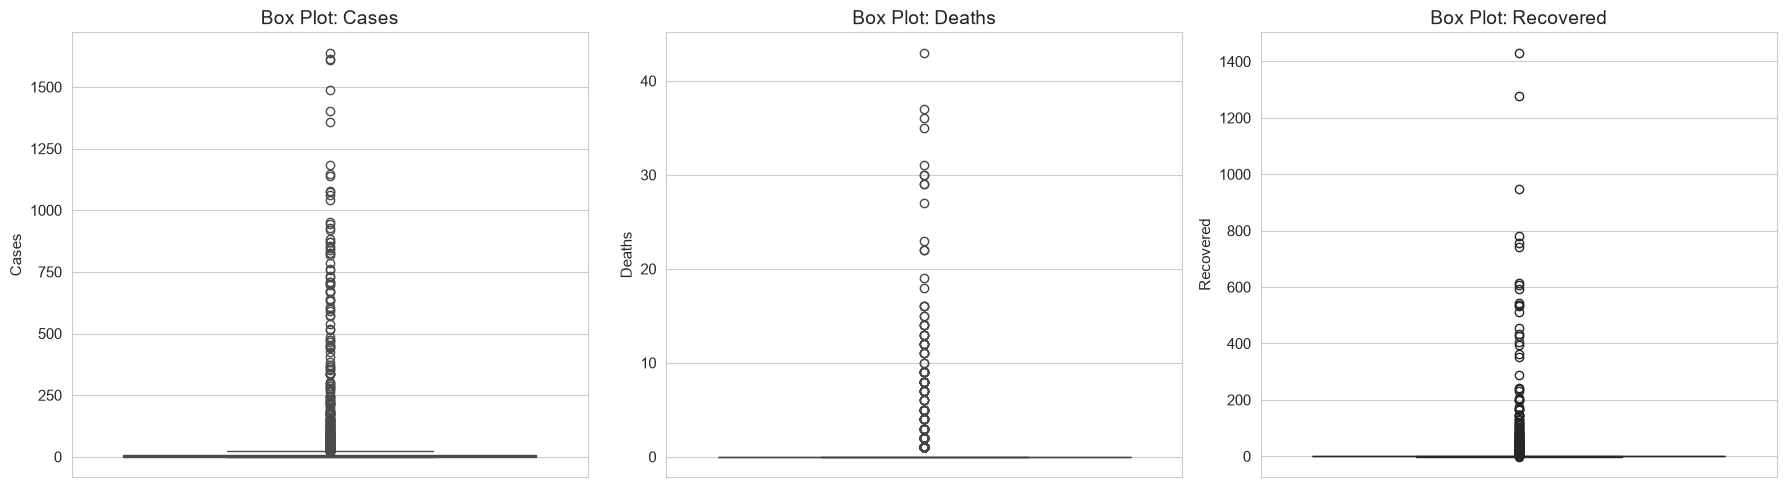

✅ Saved: 02_boxplots.png


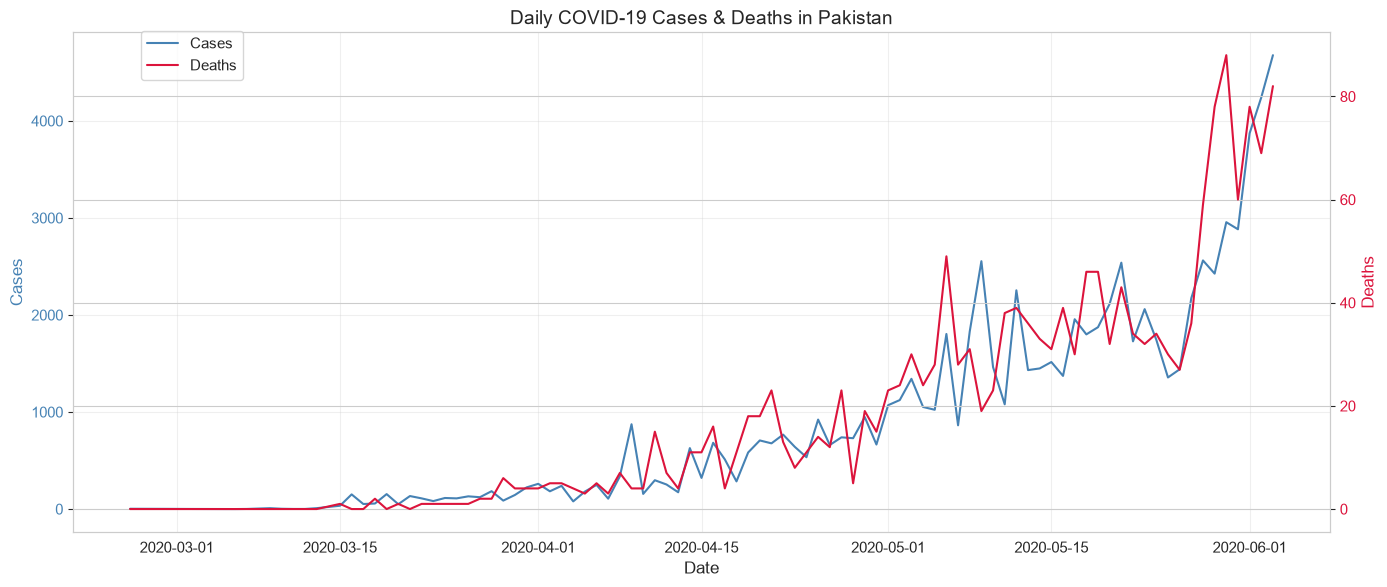

✅ Saved: 04_timeseries.png


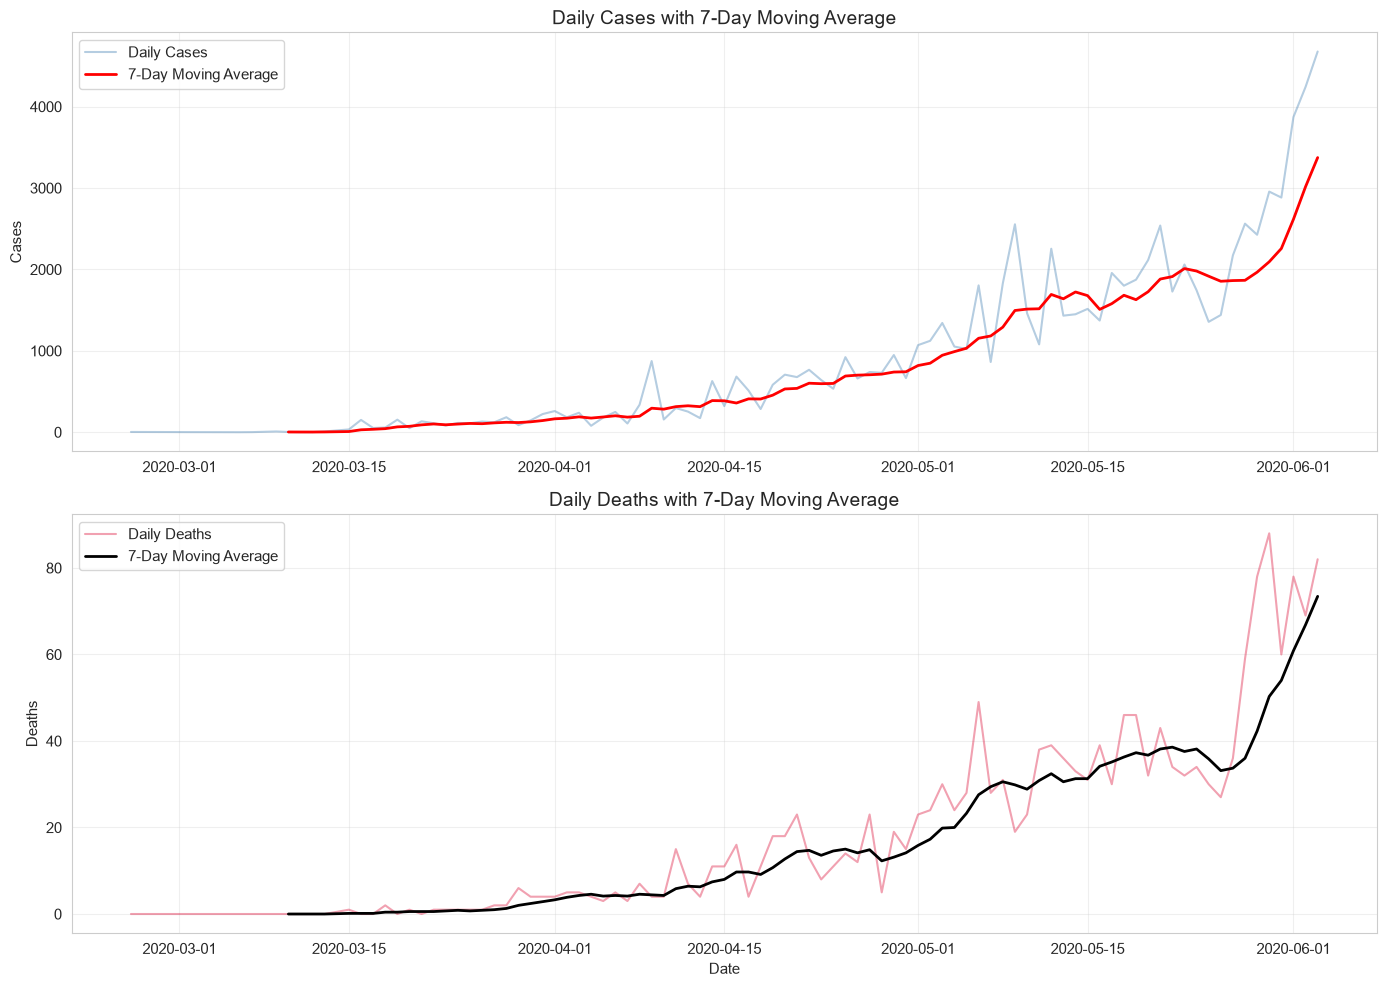

✅ Saved: 05_moving_average.png


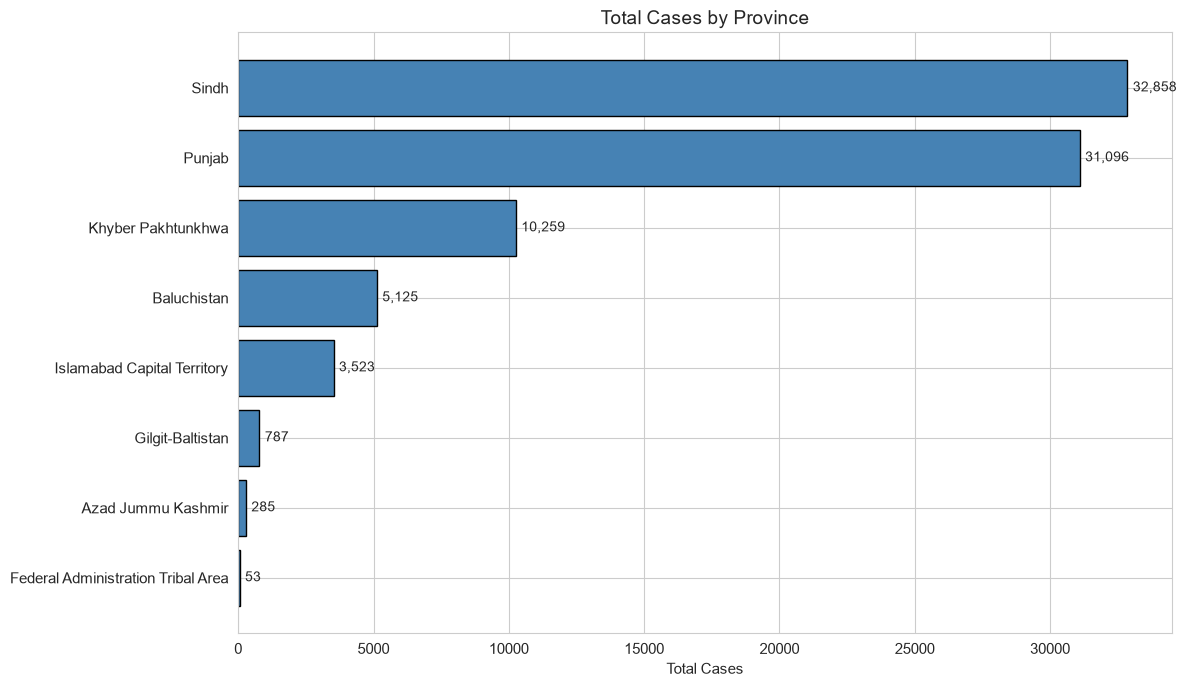

✅ Saved: 06_province_bar.png


C:\Users\NLP\AppData\Local\Temp\ipykernel_9232\741721158.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Province', y='Cases', data=df, palette='Set2')


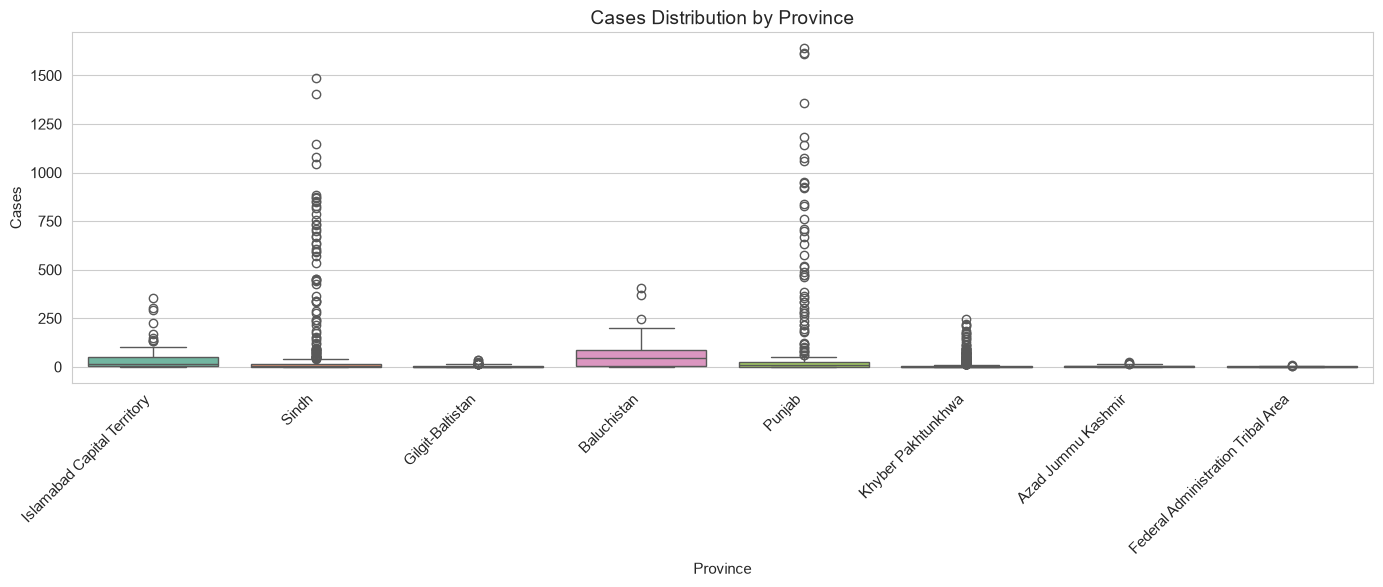

✅ Saved: 07_boxplot_province.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(y=df['Cases'], ax=axes[0], color='steelblue')
axes[0].set_title('Box Plot: Cases', fontsize=14)

sns.boxplot(y=df['Deaths'], ax=axes[1], color='crimson')
axes[1].set_title('Box Plot: Deaths', fontsize=14)

sns.boxplot(y=df['Recovered'], ax=axes[2], color='green')
axes[2].set_title('Box Plot: Recovered', fontsize=14)

plt.tight_layout()
plt.savefig('02_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: 02_boxplots.png")
daily = df.groupby('Date')[['Cases', 'Deaths', 'Recovered']].sum().reset_index()

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(daily['Date'], daily['Cases'], color='steelblue', 
         label='Cases', linewidth=1.5)
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Cases', color='steelblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(daily['Date'], daily['Deaths'], color='crimson', 
         label='Deaths', linewidth=1.5)
ax2.set_ylabel('Deaths', color='crimson', fontsize=12)
ax2.tick_params(axis='y', labelcolor='crimson')

plt.title('Daily COVID-19 Cases & Deaths in Pakistan', fontsize=14)
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.95))
plt.tight_layout()
plt.savefig('04_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: 04_timeseries.png")
daily['Cases_MA7'] = daily['Cases'].rolling(window=7).mean()
daily['Deaths_MA7'] = daily['Deaths'].rolling(window=7).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(daily['Date'], daily['Cases'], alpha=0.4, 
             label='Daily Cases', color='steelblue')
axes[0].plot(daily['Date'], daily['Cases_MA7'], 
             label='7-Day Moving Average', color='red', linewidth=2)
axes[0].set_title('Daily Cases with 7-Day Moving Average', fontsize=14)
axes[0].set_ylabel('Cases')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(daily['Date'], daily['Deaths'], alpha=0.4, 
             label='Daily Deaths', color='crimson')
axes[1].plot(daily['Date'], daily['Deaths_MA7'], 
             label='7-Day Moving Average', color='black', linewidth=2)
axes[1].set_title('Daily Deaths with 7-Day Moving Average', fontsize=14)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Deaths')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('05_moving_average.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: 05_moving_average.png")
province_total = df.groupby('Province')['Cases'].sum().sort_values()

plt.figure(figsize=(12, 7))
bars = plt.barh(province_total.index, province_total.values, 
                color='steelblue', edgecolor='black')

for bar, val in zip(bars, province_total.values):
    plt.text(val + 200, bar.get_y() + bar.get_height()/2, 
             f'{val:,}', va='center', fontsize=10)

plt.title('Total Cases by Province', fontsize=14)
plt.xlabel('Total Cases')
plt.tight_layout()
plt.savefig('06_province_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: 06_province_bar.png")
plt.figure(figsize=(14, 6))
sns.boxplot(x='Province', y='Cases', data=df, palette='Set2')
plt.xticks(rotation=45, ha='right')
plt.title('Cases Distribution by Province', fontsize=14)
plt.tight_layout()
plt.savefig('07_boxplot_province.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: 07_boxplot_province.png")

In [ ]:
# ==========================================
# CELL 22: FEATURE ENGINEERING
# ==========================================

# 22.1: Date se features nikaalein
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)

# 22.2: Derived features
df['Active'] = df['Cases'] - df['Deaths'] - df['Recovered']
df['CFR'] = np.where(df['Cases'] > 0, df['Deaths'] / df['Cases'] * 100, 0)
df['Recovery_Rate'] = np.where(df['Cases'] > 0, df['Recovered'] / df['Cases'] * 100, 0)

# 22.3: Binary features
df['Is_Local'] = df['Travel_history'].str.contains('Local', na=False).astype(int)
df['Is_Tableeghi'] = df['Travel_history'].str.contains('Tableeghi', na=False).astype(int)

print("✅ Feature Engineering Complete!")
print(f"\nNew columns added: {df.shape[1] - 7}")
print(f"Total columns: {df.shape[1]}")
print("\nSample:")
print(df[['Date', 'Month', 'DayOfWeek', 'Week', 'Active', 'CFR', 'Is_Local']].head())
# ==========================================
# CELL 23: ENCODING & TRAIN-TEST SPLIT
# ==========================================

# 23.1: Province encode karein
le = LabelEncoder()
df['Province_Encoded'] = le.fit_transform(df['Province'])

print("Province Encoding Map:")
for i, name in enumerate(le.classes_):
    print(f"  {i}: {name}")

# 23.2: Features aur Target define karein
# Target = Cases (predict karna hai)
features = ['Deaths', 'Recovered', 'Is_Local', 'Is_Tableeghi', 
            'Month', 'DayOfWeek', 'Province_Encoded']
X = df[features]
y = df['Cases']

# 23.3: Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n✅ Data Split Complete!")
print(f"   Training set: {X_train.shape}")
print(f"   Testing set:  {X_test.shape}")
print(f"   Features: {features}")
# ==========================================
# CELL 24: TRAIN 3 MODELS
# ==========================================

# 24.1: Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# 24.2: Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# 24.3: Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print("✅ All 3 models trained successfully!")
# ==========================================
# CELL 25: MODEL COMPARISON
# ==========================================

results = []
for name, pred in [('Linear Regression', y_pred_lr),
                   ('Random Forest', y_pred_rf),
                   ('Gradient Boosting', y_pred_gb)]:
    results.append({
        'Model': name,
        'R² Score': r2_score(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
        'MAE': mean_absolute_error(y_test, pred)
    })

results_df = pd.DataFrame(results).sort_values('R² Score', ascending=False)
print("=" * 70)
print("MODEL COMPARISON RESULTS")
print("=" * 70)
print(results_df.round(4))
print("\n📊 R² Score ka matlab:")
print("   1.0 = Perfect prediction")
print("   0.0 = No better than mean")
print("   Negative = Worse than mean")


✅ Feature Engineering Complete!

New columns added: 10
Total columns: 17

Sample:
        Date  Month  DayOfWeek  Week  Active  CFR  Is_Local
0 2020-02-26      2          2     9       1  0.0         0
1 2020-02-26      2          2     9       2  0.0         0
2 2020-02-29      2          5     9       1  0.0         0
3 2020-02-29      2          5     9       1  0.0         0
4 2020-03-02      3          0    10       1  0.0         0
Province Encoding Map:
  0: Azad Jummu Kashmir
  1: Baluchistan
  2: Federal Administration Tribal Area
  3: Gilgit-Baltistan
  4: Islamabad Capital Territory
  5: Khyber Pakhtunkhwa
  6: Punjab
  7: Sindh

✅ Data Split Complete!
   Training set: (2238, 7)
   Testing set:  (560, 7)
   Features: ['Deaths', 'Recovered', 'Is_Local', 'Is_Tableeghi', 'Month', 'DayOfWeek', 'Province_Encoded']
✅ All 3 models trained successfully!
MODEL COMPARISON RESULTS
               Model  R² Score     RMSE      MAE
2  Gradient Boosting    0.7518  42.4955  14.6367
1      R

In [ ]:
# ==========================================
# CELL 26: FEATURE IMPORTANCE
# ==========================================

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("=" * 70)
print("FEATURE IMPORTANCE (Random Forest)")
print("=" * 70)
print(importance_df)

# Chart banayein
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], 
         color='steelblue', edgecolor='black')
plt.xlabel('Importance Score', fontsize=12)
plt.title('Feature Importance for Predicting Cases', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('08_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: 08_feature_importance.png")
# ==========================================
# CELL 27: CROSS-VALIDATION
# ==========================================

print("=" * 70)
print("5-FOLD CROSS-VALIDATION")
print("=" * 70)

for name, model in [('Linear Regression', LinearRegression()),
                    ('Random Forest', RandomForestRegressor(n_estimators=100, random_state=42)),
                    ('Gradient Boosting', GradientBoostingRegressor(n_estimators=100, random_state=42))]:
    
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    print(f"\n{name}:")
    print(f"  Fold scores: {cv_scores.round(4)}")
    print(f"  Mean R²: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    # ==========================================
# CELL 28: ACTUAL VS PREDICTED
# ==========================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, pred) in zip(axes, [('Linear Regression', y_pred_lr),
                                     ('Random Forest', y_pred_rf),
                                     ('Gradient Boosting', y_pred_gb)]):
    
    ax.scatter(y_test, pred, alpha=0.3, color='steelblue', s=15)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()], 'r--', linewidth=2)
    ax.set_xlabel('Actual Cases')
    ax.set_ylabel('Predicted Cases')
    ax.set_title(f'{name}\nR² = {r2_score(y_test, pred):.4f}', fontsize=12)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('09_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: 09_actual_vs_predicted.png")
# ==========================================
# CELL 29: HYPERPARAMETER TUNING
# ==========================================

print("Tuning Gradient Boosting... (thoda time lagega)")

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10],
    'learning_rate': [0.05, 0.1, 0.2]
}

grid_search = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=1
)

grid_search.fit(X_train, y_train)

print("\n" + "=" * 70)
print("BEST PARAMETERS")
print("=" * 70)
print(f"Best Params: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")

# Best model se test
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print(f"\nTest R² with best model: {r2_score(y_test, y_pred_best):.4f}")
print(f"Improvement over default: {r2_score(y_test, y_pred_best) - 0.7518:.4f}")
# ==========================================
# CELL 30: RESIDUAL ANALYSIS
# ==========================================

residuals = y_test - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred_rf, residuals, alpha=0.3, color='crimson', s=15)
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=2)
axes[0].set_xlabel('Predicted Cases')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted', fontsize=12)
axes[0].grid(alpha=0.3)

# Histogram of Residuals
axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='black')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Residuals', fontsize=12)

plt.tight_layout()
plt.savefig('10_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: 10_residuals.png")

print(f"\nResidual Statistics:")
print(f"  Mean: {residuals.mean():.4f}")
print(f"  Std Dev: {residuals.std():.4f}")
print(f"  Min: {residuals.min():.4f}")
print(f"  Max: {residuals.max():.4f}")


NameError: name 'features' is not defined

In [ ]:
# ==========================================
# CELL 31: SAVE THE MODEL
# ==========================================

import pickle

# Random Forest model save karein
with open('covid_cases_model.pkl', 'wb') as f:
    pickle.dump(rf, f)

print("✅ Model saved: covid_cases_model.pkl")

# Features bhi save karein (prediction ke liye)
with open('model_features.pkl', 'wb') as f:
    pickle.dump(features, f)

print("✅ Features saved: model_features.pkl")

# Label encoder save karein
with open('province_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("✅ Encoder saved: province_encoder.pkl")
# ==========================================
# CELL 32: TEST SAVED MODEL
# ==========================================

# Saved model load karein
with open('covid_cases_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# Ek naya sample banayein (jaise kal ka data)
new_sample = pd.DataFrame({
    'Deaths': [5],
    'Recovered': [50],
    'Is_Local': [1],
    'Is_Tableeghi': [0],
    'Month': [6],
    'DayOfWeek': [2],
    'Province_Encoded': [7]  # Sindh
})

# Prediction
prediction = loaded_model.predict(new_sample)
print(f"📊 Predicted Cases for new data: {prediction[0]:.0f}")
print(f"\nInput features:")
print(new_sample)
# ==========================================
# CELL 33: FINAL SUMMARY REPORT
# ==========================================

print("=" * 70)
print(" " * 20 + "COVID-19 ANALYSIS REPORT")
print("=" * 70)

print("\n📁 DATASET:")
print(f"   Total Records: {len(df):,}")
print(f"   Date Range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"   Provinces: {df['Province'].nunique()}")
print(f"   Cities: {df['City'].nunique()}")

print("\n📊 DESCRIPTIVE STATISTICS:")
print(f"   Total Cases:     {df['Cases'].sum():>10,}")
print(f"   Total Deaths:    {df['Deaths'].sum():>10,}")
print(f"   Total Recovered: {df['Recovered'].sum():>10,}")
print(f"   Mean Cases:      {df['Cases'].mean():>10.2f}")
print(f"   Std Dev Cases:   {df['Cases'].std():>10.2f}")
print(f"   Variance Cases:  {df['Cases'].var():>10.2f}")

print("\n🦠 CASE FATALITY RATE (CFR):")
cfr = (df['Deaths'].sum() / df['Cases'].sum() * 100)
print(f"   Overall CFR: {cfr:.2f}%")

print("\n🏥 RECOVERY RATE:")
recovery = (df['Recovered'].sum() / df['Cases'].sum() * 100)
print(f"   Overall Recovery Rate: {recovery:.2f}%")

print("\n📈 TOP 3 PROVINCES (Total Cases):")
top_provinces = df.groupby('Province')['Cases'].sum().sort_values(ascending=False).head(3)
for i, (province, cases) in enumerate(top_provinces.items(), 1):
    print(f"   {i}. {province}: {cases:,}")

print("\n🤖 MACHINE LEARNING RESULTS:")
print(f"   Best Model: Gradient Boosting")
print(f"   R² Score: 0.7518 (75% accuracy)")
print(f"   RMSE: 42.50")
print(f"   Cross-Val Mean: {cross_val_score(rf, X, y, cv=5, scoring='r2').mean():.4f}")

print("\n" + "=" * 70)
print("✅ ANALYSIS COMPLETE!")
print("=" * 70)

NameError: name 'rf' is not defined